# New York Taxi Fare Prediction Using Deep Feedforward Neural Networks

## Lab Assignment 2

### Problem Statement

Develop a Deep Learning-based regression system to predict the fare amount
of a New York City taxi trip using trip-related, temporal, and geolocation
features.

### Objective

To develop and deploy a Deep Feedforward Neural Network for predicting
New York City taxi fares using historical taxi trip data.

### Dataset

New York City Taxi Fare Prediction Dataset

# 1. Dataset Setup & Initial Inspection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
TRAIN_PATH = "../data/raw/train.csv"
TEST_PATH = "../data/raw/test.csv"
SAMPLE_SUBMISSION_PATH = "../data/raw/sample_submission.csv"

print("Train file exists:", os.path.exists(TRAIN_PATH))
print("Test file exists:", os.path.exists(TEST_PATH))
print("Sample submission exists:", os.path.exists(SAMPLE_SUBMISSION_PATH))

Train file exists: True
Test file exists: True
Sample submission exists: True


In [3]:
train_sample = pd.read_csv(
    TRAIN_PATH,
    nrows=10000
)

test_sample = pd.read_csv(
    TEST_PATH,
    nrows=10000
)

print("Train sample shape:", train_sample.shape)
print("Test sample shape:", test_sample.shape)

Train sample shape: (10000, 8)
Test sample shape: (9914, 7)


In [4]:
train_sample.head()

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,2009-06-15 17:26:21.0000001,4.5,2009-06-15 17:26:21 UTC,-73.844311,40.721319,-73.841610,40.712278,1
1,2010-01-05 16:52:16.0000002,16.9,2010-01-05 16:52:16 UTC,-74.016048,40.711303,-73.979268,40.782004,1
2,2011-08-18 00:35:00.00000049,5.7,2011-08-18 00:35:00 UTC,-73.982738,40.761270,-73.991242,40.750562,2
3,2012-04-21 04:30:42.0000001,7.7,2012-04-21 04:30:42 UTC,-73.987130,40.733143,-73.991567,40.758092,1
4,2010-03-09 07:51:00.000000135,5.3,2010-03-09 07:51:00 UTC,-73.968095,40.768008,-73.956655,40.783762,1


In [5]:
train_sample.tail()

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
9995,2011-10-26 10:44:00.00000086,11.7,2011-10-26 10:44:00 UTC,-73.988277,40.748970,-73.963712,40.773958,2
9996,2011-12-16 15:37:00.000000179,5.7,2011-12-16 15:37:00 UTC,-74.002112,40.748727,-73.992467,40.756252,1
9997,2013-11-16 22:47:17.0000001,12.0,2013-11-16 22:47:17 UTC,-73.992093,40.729071,-73.974470,40.763050,2
9998,2010-01-28 11:38:00.00000022,6.5,2010-01-28 11:38:00 UTC,-73.992548,40.735652,-73.998802,40.723085,1
9999,2011-07-05 06:48:44.0000002,10.5,2011-07-05 06:48:44 UTC,-73.978400,40.751700,-74.010500,40.713600,1


In [6]:
print("Train columns:")
print(train_sample.columns.tolist())

print("\nTest columns:")
print(test_sample.columns.tolist())

Train columns:
['key', 'fare_amount', 'pickup_datetime', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'passenger_count']

Test columns:
['key', 'pickup_datetime', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'passenger_count']


In [7]:
train_sample.dtypes

key                   object
fare_amount          float64
pickup_datetime       object
pickup_longitude     float64
pickup_latitude      float64
dropoff_longitude    float64
dropoff_latitude     float64
passenger_count        int64
dtype: object

In [8]:
train_sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   key                10000 non-null  object 
 1   fare_amount        10000 non-null  float64
 2   pickup_datetime    10000 non-null  object 
 3   pickup_longitude   10000 non-null  float64
 4   pickup_latitude    10000 non-null  float64
 5   dropoff_longitude  10000 non-null  float64
 6   dropoff_latitude   10000 non-null  float64
 7   passenger_count    10000 non-null  int64  
dtypes: float64(5), int64(1), object(2)
memory usage: 625.1+ KB


In [9]:
train_sample.describe(include="all")

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,10000,10000.000000,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
unique,10000,NaN,9985,NaN,NaN,NaN,NaN,NaN
top,2009-10-10 14:53:08.0000003,NaN,2009-12-10 15:37:00 UTC,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,2,NaN,NaN,NaN,NaN,NaN
mean,NaN,11.235464,NaN,-72.466660,39.920448,-72.474094,39.893281,1.644700
std,NaN,9.584258,NaN,10.609729,7.318932,10.579732,6.339919,1.271229
min,NaN,-2.900000,NaN,-74.438233,-74.006893,-74.429332,-73.994392,0.000000
25%,NaN,6.000000,NaN,-73.992058,40.734547,-73.991112,40.735230,1.000000
50%,NaN,8.500000,NaN,-73.981758,40.752693,-73.980083,40.753738,1.000000
75%,NaN,12.500000,NaN,-73.966925,40.767694,-73.963504,40.768186,2.000000


In [10]:
TARGET = "fare_amount"

print("Target variable:", TARGET)
print("Target data type:", train_sample[TARGET].dtype)

Target variable: fare_amount
Target data type: float64


# 2. Dataset Understanding

This section examines the structure, data types, statistical characteristics,
missing values, unique values, target distribution, passenger counts,
geographical coordinates, and temporal information of the NYC Taxi Fare
Prediction dataset.

The analysis is performed before data preprocessing so that missing values,
anomalies, and unusual observations can be identified objectively.

Section 2.1 — Current findings

In [11]:
# Check missing values in the 10,000-row sample

missing_summary = pd.DataFrame({
    "Missing Count": train_sample.isnull().sum(),
    "Missing Percentage": train_sample.isnull().mean() * 100
})

missing_summary

,Missing Count,Missing Percentage
key,0,0.0
fare_amount,0,0.0
pickup_datetime,0,0.0
pickup_longitude,0,0.0
pickup_latitude,0,0.0
dropoff_longitude,0,0.0
dropoff_latitude,0,0.0
passenger_count,0,0.0


In [12]:
# Check duplicate records in the sample

duplicate_count = train_sample.duplicated().sum()

print("Duplicate rows in sample:", duplicate_count)

Duplicate rows in sample: 0


In [13]:
# Number of unique values in each column

unique_summary = pd.DataFrame({
    "Column": train_sample.columns,
    "Unique Values": [train_sample[col].nunique() for col in train_sample.columns]
})

unique_summary

,Column,Unique Values
0,key,10000
1,fare_amount,370
2,pickup_datetime,9985
3,pickup_longitude,8988
4,pickup_latitude,9213
5,dropoff_longitude,9024
6,dropoff_latitude,9217
7,passenger_count,7


Section 2.2 — Target & Passenger Analysis

In [14]:
# Summary statistics for the target variable

fare_summary = train_sample["fare_amount"].describe()

print("Fare Amount Summary")
print("=" * 40)
print(f"Minimum Fare : ${fare_summary['min']:.2f}")
print(f"Maximum Fare : ${fare_summary['max']:.2f}")
print(f"Mean Fare    : ${fare_summary['mean']:.2f}")
print(f"Median Fare  : ${fare_summary['50%']:.2f}")
print(f"Std. Dev.    : ${fare_summary['std']:.2f}")

Fare Amount Summary
Minimum Fare : $-2.90
Maximum Fare : $180.00
Mean Fare    : $11.24
Median Fare  : $8.50
Std. Dev.    : $9.58


In [15]:
# Passenger count distribution

passenger_summary = train_sample["passenger_count"].value_counts().sort_index()

print("Passenger Count Distribution")
print("=" * 40)
print(passenger_summary)

Passenger Count Distribution
passenger_count
0      38
1    7055
2    1424
3     432
4     186
5     686
6     179
Name: count, dtype: int64


In [16]:
# Passenger count statistics

train_sample["passenger_count"].describe()

count    10000.000000
mean         1.644700
std          1.271229
min          0.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          6.000000
Name: passenger_count, dtype: float64

In [17]:
# Potential fare anomalies

print("Negative fares:")
print(train_sample[train_sample["fare_amount"] < 0][
    ["fare_amount", "pickup_datetime", "passenger_count"]
])

print("\nZero fares:")
print(train_sample[train_sample["fare_amount"] == 0][
    ["fare_amount", "pickup_datetime", "passenger_count"]
])

print("\nVery high fares (>= $100):")
print(train_sample[train_sample["fare_amount"] >= 100][
    ["fare_amount", "pickup_datetime", "passenger_count"]
])

Negative fares:
      fare_amount          pickup_datetime  passenger_count
2039         -2.9  2010-03-09 23:37:10 UTC                1
2486         -2.5  2015-03-22 05:14:27 UTC                1

Zero fares:
Empty DataFrame
Columns: [fare_amount, pickup_datetime, passenger_count]
Index: []

Very high fares (>= $100):
      fare_amount          pickup_datetime  passenger_count
1335       180.00  2013-01-16 20:19:58 UTC                1
1483       165.00  2009-08-07 21:49:13 UTC                1
6630       128.83  2014-05-16 01:51:00 UTC                1


In [18]:
# Potential passenger-count anomalies

print("Passenger counts less than or equal to 0:")
print(
    train_sample[train_sample["passenger_count"] <= 0][
        ["passenger_count", "fare_amount", "pickup_datetime"]
    ]
)

print("\nPassenger count frequency:")
print(train_sample["passenger_count"].value_counts().sort_index())

Passenger counts less than or equal to 0:
      passenger_count  fare_amount          pickup_datetime
314                 0         34.0  2015-06-02 23:16:15 UTC
566                 0          4.9  2012-01-28 21:33:18 UTC
678                 0          6.5  2012-02-27 07:24:20 UTC
1160                0         13.3  2011-05-25 23:58:48 UTC
1935                0         10.1  2011-10-23 11:09:28 UTC
2200                0          8.1  2011-05-23 16:54:19 UTC
2425                0          8.9  2011-11-25 22:47:33 UTC
3034                0          5.7  2011-03-06 12:03:14 UTC
3413                0          7.3  2011-02-28 06:39:16 UTC
3481                0         11.3  2011-11-30 17:23:02 UTC
3489                0          7.3  2011-10-18 08:18:18 UTC
3599                0          8.9  2011-03-06 18:24:50 UTC
4114                0          4.5  2011-07-22 05:51:00 UTC
4248                0          4.1  2012-02-15 11:19:50 UTC
4344                0         24.9  2011-05-19 13:28:17 UT

SECTION 2.3 — Geographical Coordinate Analysis

In [19]:
# Geographical coordinate summary

coordinate_columns = [
    "pickup_longitude",
    "pickup_latitude",
    "dropoff_longitude",
    "dropoff_latitude"
]

coordinate_summary = train_sample[coordinate_columns].describe().T

coordinate_summary

,count,mean,std,min,25%,50%,75%,max
pickup_longitude,10000.0,-72.466660,10.609729,-74.438233,-73.992058,-73.981758,-73.966925,40.766125
pickup_latitude,10000.0,39.920448,7.318932,-74.006893,40.734547,40.752693,40.767694,401.083332
dropoff_longitude,10000.0,-72.474094,10.579732,-74.429332,-73.991112,-73.980083,-73.963504,40.802437
dropoff_latitude,10000.0,39.893281,6.339919,-73.994392,40.735230,40.753738,40.768186,41.366138


In [20]:
# Check physically valid latitude and longitude ranges

print("Coordinate range checks")
print("=" * 50)

print("Latitude should normally be between -90 and 90 degrees.")
print("Longitude should normally be between -180 and 180 degrees.")

Coordinate range checks
Latitude should normally be between -90 and 90 degrees.
Longitude should normally be between -180 and 180 degrees.


In [21]:
# Identify mathematically invalid coordinates

invalid_coordinate_mask = (
    (train_sample["pickup_latitude"] < -90) |
    (train_sample["pickup_latitude"] > 90) |
    (train_sample["dropoff_latitude"] < -90) |
    (train_sample["dropoff_latitude"] > 90) |
    (train_sample["pickup_longitude"] < -180) |
    (train_sample["pickup_longitude"] > 180) |
    (train_sample["dropoff_longitude"] < -180) |
    (train_sample["dropoff_longitude"] > 180)
)

print("Invalid coordinate records:", invalid_coordinate_mask.sum())

Invalid coordinate records: 1


In [22]:
# Display invalid coordinate records

invalid_coordinates = train_sample.loc[
    invalid_coordinate_mask,
    [
        "key",
        "fare_amount",
        "pickup_datetime",
        "pickup_longitude",
        "pickup_latitude",
        "dropoff_longitude",
        "dropoff_latitude",
        "passenger_count"
    ]
]

invalid_coordinates

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
5686,2011-07-30 11:15:00.00000082,3.3,2011-07-30 11:15:00 UTC,-73.947235,401.083332,-73.951392,40.778927,1


In [23]:
# Check coordinates around the expected NYC region
# This is an exploratory check, not a final cleaning rule.

nyc_like_mask = (
    train_sample["pickup_longitude"].between(-75, -73) &
    train_sample["pickup_latitude"].between(40, 42) &
    train_sample["dropoff_longitude"].between(-75, -73) &
    train_sample["dropoff_latitude"].between(40, 42)
)

print("Records with all coordinates in a broad NYC region:",
      nyc_like_mask.sum())

print("Records outside this broad NYC region:",
      (~nyc_like_mask).sum())

Records with all coordinates in a broad NYC region: 9790
Records outside this broad NYC region: 210


In [24]:
# Display records outside the broad NYC region

geographical_anomalies = train_sample.loc[
    ~nyc_like_mask,
    [
        "key",
        "fare_amount",
        "pickup_datetime",
        "pickup_longitude",
        "pickup_latitude",
        "dropoff_longitude",
        "dropoff_latitude",
        "passenger_count"
    ]
]

geographical_anomalies

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
11,2012-12-24 11:24:00.00000098,5.5,2012-12-24 11:24:00 UTC,0.0,0.0,0.0,0.0,3
15,2013-11-23 12:57:00.000000190,5.0,2013-11-23 12:57:00 UTC,0.0,0.0,0.0,0.0,1
26,2011-02-07 20:01:00.000000114,6.5,2011-02-07 20:01:00 UTC,0.0,0.0,0.0,0.0,1
124,2013-01-17 17:22:00.00000043,8.0,2013-01-17 17:22:00 UTC,0.0,0.0,0.0,0.0,2
192,2010-09-05 17:08:00.00000092,3.7,2010-09-05 17:08:00 UTC,0.0,0.0,0.0,0.0,5
...,...,...,...,...,...,...,...,...
9785,2010-04-27 23:26:40.0000004,6.9,2010-04-27 23:26:40 UTC,0.0,0.0,0.0,0.0,1
9853,2012-02-12 13:02:00.00000054,3.7,2012-02-12 13:02:00 UTC,0.0,0.0,0.0,0.0,6
9863,2010-12-09 06:48:04.0000003,6.5,2010-12-09 06:48:04 UTC,0.0,0.0,0.0,0.0,1
9888,2012-05-12 21:19:00.000000199,8.5,2012-05-12 21:19:00 UTC,0.0,0.0,0.0,0.0,6


In [25]:
print("Number of geographically suspicious records:",
      len(geographical_anomalies))

Number of geographically suspicious records: 210


In [26]:
# Categorize geographical anomalies

zero_coordinate_mask = (
    (train_sample["pickup_longitude"] == 0) &
    (train_sample["pickup_latitude"] == 0) &
    (train_sample["dropoff_longitude"] == 0) &
    (train_sample["dropoff_latitude"] == 0)
)

mathematically_invalid_mask = (
    (train_sample["pickup_latitude"] < -90) |
    (train_sample["pickup_latitude"] > 90) |
    (train_sample["dropoff_latitude"] < -90) |
    (train_sample["dropoff_latitude"] > 90) |
    (train_sample["pickup_longitude"] < -180) |
    (train_sample["pickup_longitude"] > 180) |
    (train_sample["dropoff_longitude"] < -180) |
    (train_sample["dropoff_longitude"] > 180)
)

print("Zero-coordinate records:",
      zero_coordinate_mask.sum())

print("Mathematically invalid-coordinate records:",
      mathematically_invalid_mask.sum())

print("Records outside broad NYC region:",
      (~nyc_like_mask).sum())

Zero-coordinate records: 186
Mathematically invalid-coordinate records: 1
Records outside broad NYC region: 210


In [27]:
# Inspect non-zero records outside the broad NYC region

non_zero_geographical_anomalies = train_sample.loc[
    (~nyc_like_mask) & (~zero_coordinate_mask),
    [
        "key",
        "fare_amount",
        "pickup_datetime",
        "pickup_longitude",
        "pickup_latitude",
        "dropoff_longitude",
        "dropoff_latitude",
        "passenger_count"
    ]
]

non_zero_geographical_anomalies

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
472,2009-02-22 22:48:00.000000130,2.5,2009-02-22 22:48:00 UTC,0.000000,0.000000,-74.005433,40.726685,2
1181,2012-10-11 00:21:00.000000140,25.0,2012-10-11 00:21:00 UTC,-0.004093,0.033500,0.016852,0.017980,2
1260,2011-03-10 20:25:00.00000049,5.7,2011-03-10 20:25:00 UTC,-73.973907,40.754743,0.000000,0.000000,2
2147,2013-05-24 14:54:00.00000079,5.0,2013-05-24 14:54:00 UTC,40.751582,-73.986968,40.758867,-73.978353,2
2280,2011-08-29 08:24:00.000000107,8.9,2011-08-29 08:24:00 UTC,-73.936667,40.757815,0.000000,40.757815,1
2397,2012-06-24 17:11:10.0000001,45.0,2012-06-24 17:11:10 UTC,0.000000,0.000000,-74.010230,40.714553,2
3827,2013-06-20 04:28:00.0000001,11.0,2013-06-20 04:28:00 UTC,40.719830,-73.988467,40.723305,-73.939430,1
4278,2015-04-07 23:33:02.0000005,7.0,2015-04-07 23:33:02 UTC,-73.972702,40.757423,0.000000,0.000000,1
4597,2010-03-30 07:12:00.000000158,6.9,2010-03-30 07:12:00 UTC,0.000000,0.000000,-73.989693,40.754280,1
4783,2013-05-22 06:28:00.0000004,6.5,2013-05-22 06:28:00 UTC,40.748262,-73.991840,40.740372,-73.979010,1


In [28]:
print(
    "Non-zero records outside broad NYC region:",
    len(non_zero_geographical_anomalies)
)

Non-zero records outside broad NYC region: 24


In [29]:
# Check for possible latitude-longitude swaps

possible_swaps = train_sample.loc[
    (
        train_sample["pickup_longitude"].between(40, 42) &
        train_sample["pickup_latitude"].between(-75, -73)
    )
    |
    (
        train_sample["dropoff_longitude"].between(40, 42) &
        train_sample["dropoff_latitude"].between(-75, -73)
    ),
    [
        "key",
        "fare_amount",
        "pickup_datetime",
        "pickup_longitude",
        "pickup_latitude",
        "dropoff_longitude",
        "dropoff_latitude",
        "passenger_count"
    ]
]

print("Potential latitude-longitude swap records:",
      len(possible_swaps))

possible_swaps

Potential latitude-longitude swap records: 7


,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
2147,2013-05-24 14:54:00.00000079,5.0,2013-05-24 14:54:00 UTC,40.751582,-73.986968,40.758867,-73.978353,2
3827,2013-06-20 04:28:00.0000001,11.0,2013-06-20 04:28:00 UTC,40.719830,-73.988467,40.723305,-73.939430,1
4783,2013-05-22 06:28:00.0000004,6.5,2013-05-22 06:28:00 UTC,40.748262,-73.991840,40.740372,-73.979010,1
6705,2013-05-22 15:33:00.000000175,13.0,2013-05-22 15:33:00 UTC,40.766125,-73.983285,40.757417,-73.977962,2
7525,2013-05-22 10:54:00.000000140,13.0,2013-05-22 10:54:00 UTC,40.760495,-73.973047,40.740367,-73.994392,1
8443,2013-05-24 00:32:00.000000190,15.0,2013-05-24 00:32:00 UTC,40.729127,-74.006893,40.763367,-73.961550,1
9548,2013-07-13 12:31:00.00000097,15.5,2013-07-13 12:31:00 UTC,40.764420,-73.992947,40.802437,-73.950730,1


In [30]:
# Summary of zero values by coordinate column

zero_coordinate_summary = pd.DataFrame({
    "Column": coordinate_columns,
    "Zero Count": [
        (train_sample[col] == 0).sum()
        for col in coordinate_columns
    ]
})

zero_coordinate_summary

,Column,Zero Count
0,pickup_longitude,192
1,pickup_latitude,192
2,dropoff_longitude,190
3,dropoff_latitude,189


In [31]:
# Convert pickup_datetime to datetime

train_sample["pickup_datetime"] = pd.to_datetime(
    train_sample["pickup_datetime"],
    errors="coerce"
)

print("Data type after conversion:")
print(train_sample["pickup_datetime"].dtype)

Data type after conversion:
datetime64[ns, UTC]


In [32]:
# Check datetime conversion

invalid_datetime_count = train_sample["pickup_datetime"].isna().sum()

print("Invalid datetime values:", invalid_datetime_count)

Invalid datetime values: 0


In [33]:
# Temporal range of the sample

print("Earliest pickup:", train_sample["pickup_datetime"].min())
print("Latest pickup  :", train_sample["pickup_datetime"].max())

Earliest pickup: 2009-01-01 02:51:52+00:00
Latest pickup  : 2015-06-30 22:42:39+00:00


In [34]:
# Basic temporal coverage

print("Number of unique years:",
      train_sample["pickup_datetime"].dt.year.nunique())

print("Years present:",
      sorted(train_sample["pickup_datetime"].dt.year.unique()))

print("Months present:",
      sorted(train_sample["pickup_datetime"].dt.month.unique()))

print("Hours present:",
      sorted(train_sample["pickup_datetime"].dt.hour.unique()))

Number of unique years: 7
Years present: [np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015)]
Months present: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]
Hours present: [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19), np.int32(20), np.int32(21), np.int32(22), np.int32(23)]


In [35]:
# Count rows in the full training and test datasets
# without loading the entire files into memory.

train_rows = 0
test_rows = 0

for chunk in pd.read_csv(TRAIN_PATH, chunksize=100_000):
    train_rows += len(chunk)

for chunk in pd.read_csv(TEST_PATH, chunksize=100_000):
    test_rows += len(chunk)

print("Total training records:", train_rows)
print("Total test records:", test_rows)

Total training records: 55423856
Total test records: 9914


In [36]:
dataset_summary = pd.DataFrame({
    "Dataset": ["Training", "Test"],
    "Records": [train_rows, test_rows],
    "Features": [len(train_sample.columns), len(test_sample.columns)],
    "Target": ["fare_amount", "Not available"]
})

dataset_summary

,Dataset,Records,Features,Target
0,Training,55423856,8,fare_amount
1,Test,9914,7,Not available


# 3. Exploratory Data Analysis

Since the complete training dataset contains more than 55 million records,
a representative sample is created for visualization-based exploratory data
analysis. Full-dataset statistics will be computed using chunk-based
processing where appropriate.

The original raw dataset is preserved without modification.

In [37]:
# Configuration for EDA sampling

EDA_SAMPLE_SIZE = 500_000
RANDOM_STATE = 42

print("EDA sample size:", EDA_SAMPLE_SIZE)
print("Random state:", RANDOM_STATE)

EDA sample size: 500000
Random state: 42


In [38]:
# Efficient uniform random sampling from the complete training dataset

EDA_SAMPLE_SIZE = 500_000
RANDOM_STATE = 42
CHUNK_SIZE = 100_000

rng = np.random.default_rng(RANDOM_STATE)

reservoir = []
priorities = []

for chunk in pd.read_csv(TRAIN_PATH, chunksize=CHUNK_SIZE):

    # Generate one random priority per row
    chunk_priority = rng.random(len(chunk))

    if len(reservoir) == 0:

        reservoir = chunk.copy()
        priorities = chunk_priority

    else:

        # Add current chunk to the existing reservoir
        combined = pd.concat(
            [reservoir, chunk],
            ignore_index=True
        )

        combined_priorities = np.concatenate(
            [priorities, chunk_priority]
        )

        # Number of rows to retain
        keep = min(
            EDA_SAMPLE_SIZE,
            len(combined)
        )

        # Select the rows with the smallest random priorities
        selected_idx = np.argpartition(
            combined_priorities,
            keep - 1
        )[:keep]

        reservoir = combined.iloc[selected_idx].copy()
        priorities = combined_priorities[selected_idx]

eda_sample = reservoir.reset_index(drop=True)

print("EDA sample shape:", eda_sample.shape)
print("EDA sample size:", len(eda_sample))

EDA sample shape: (500000, 8)
EDA sample size: 500000


In [39]:
# Verify the final EDA sample

print("Rows:", len(eda_sample))
print("Columns:", len(eda_sample.columns))

print("\nColumns:")
print(eda_sample.columns.tolist())

print("\nFirst 5 rows:")
display(eda_sample.head())

Rows: 500000
Columns: 8

Columns:
['key', 'fare_amount', 'pickup_datetime', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'passenger_count']

First 5 rows:


,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,2012-09-29 11:20:00.00000027,8.0,2012-09-29 11:20:00 UTC,-73.976105,40.744712,-73.990505,40.748607,5
1,2013-12-17 19:19:00.00000028,11.0,2013-12-17 19:19:00 UTC,-73.976157,40.727747,-73.976605,40.755937,2
2,2009-05-19 07:20:00.00000074,4.9,2009-05-19 07:20:00 UTC,-73.990513,40.750870,-73.987843,40.741877,3
3,2012-03-04 01:45:00.00000075,9.3,2012-03-04 01:45:00 UTC,-73.962020,40.760377,-73.979443,40.734863,1
4,2011-12-22 21:41:00.000000235,5.7,2011-12-22 21:41:00 UTC,-73.980810,40.744382,-73.992435,40.743152,1


In [40]:
# Convert datetime in the EDA sample

eda_sample["pickup_datetime"] = pd.to_datetime(
    eda_sample["pickup_datetime"],
    errors="coerce"
)

print("Datetime dtype:",
      eda_sample["pickup_datetime"].dtype)

print("Invalid datetime values:",
      eda_sample["pickup_datetime"].isna().sum())

print("Earliest sampled trip:",
      eda_sample["pickup_datetime"].min())

print("Latest sampled trip:",
      eda_sample["pickup_datetime"].max())

Datetime dtype: datetime64[ns, UTC]
Invalid datetime values: 0
Earliest sampled trip: 2009-01-01 00:09:39+00:00
Latest sampled trip: 2015-06-30 23:54:44+00:00


## 3.1 General Dataset Analysis

The training dataset contains more than 55 million records, making full-data visualization computationally expensive. Therefore, a reproducible random sample of 500,000 training records is used for visualization-based exploratory data analysis.

This section examines:

- Dataset dimensions and data types
- Descriptive statistics
- Missing values
- Unique values
- Fare amount distribution
- Passenger count distribution
- Potentially unusual observations

The original raw dataset is preserved without modification.

In [41]:
# 3.1.1 Descriptive statistics of the EDA sample

print("EDA Sample Shape:", eda_sample.shape)

print("\nData Types:")
display(eda_sample.dtypes)

print("\nDescriptive Statistics:")
display(eda_sample.describe(include="all").T)

EDA Sample Shape: (500000, 8)

Data Types:


key                               object
fare_amount                      float64
pickup_datetime      datetime64[ns, UTC]
pickup_longitude                 float64
pickup_latitude                  float64
dropoff_longitude                float64
dropoff_latitude                 float64
passenger_count                    int64
dtype: object


Descriptive Statistics:


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
key,500000,500000,2010-01-09 12:34:26.0000008,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fare_amount,500000.0,NaN,NaN,NaN,11.358712,-45.0,6.0,8.5,12.5,1021.3,10.055839
pickup_datetime,500000,NaN,NaN,NaN,2012-03-21 05:40:12.341735936+00:00,2009-01-01 00:09:39+00:00,2010-08-19 09:14:05.249999872+00:00,2012-03-19 21:25:00+00:00,2013-10-18 20:38:17.249999872+00:00,2015-06-30 23:54:44+00:00,NaN
pickup_longitude,500000.0,NaN,NaN,NaN,-72.537734,-3029.556503,-73.992078,-73.981798,-73.967075,799.830832,14.036849
pickup_latitude,500000.0,NaN,NaN,NaN,39.905571,-2875.66633,40.734917,40.75266,40.767118,2006.48011,10.293747
dropoff_longitude,499998.0,NaN,NaN,NaN,-72.532096,-3366.536242,-73.991397,-73.980157,-73.963598,2497.105768,14.543094
dropoff_latitude,499998.0,NaN,NaN,NaN,39.929119,-2544.309965,40.734046,40.753158,40.768062,2593.67837,10.517897
passenger_count,500000.0,NaN,NaN,NaN,1.686126,0.0,1.0,1.0,2.0,6.0,1.308835


### 3.1.2 Missing Value Analysis

Missing values are examined in the 500,000-record EDA sample to determine whether any variables require treatment during preprocessing.

The analysis is performed before applying any cleaning or imputation so that the original data characteristics can be documented.

In [42]:
# 3.1.2 Missing value analysis

missing_counts = eda_sample.isnull().sum()
missing_percentage = (missing_counts / len(eda_sample)) * 100

missing_summary = pd.DataFrame({
    "Missing Count": missing_counts,
    "Missing Percentage": missing_percentage
})

display(missing_summary)

,Missing Count,Missing Percentage
key,0,0.0000
fare_amount,0,0.0000
pickup_datetime,0,0.0000
pickup_longitude,0,0.0000
pickup_latitude,0,0.0000
dropoff_longitude,2,0.0004
dropoff_latitude,2,0.0004
passenger_count,0,0.0000


In [43]:
# Display only columns containing missing values

missing_only = missing_summary[missing_summary["Missing Count"] > 0]

print("Columns containing missing values:")

if len(missing_only) == 0:
    print("No missing values found in the EDA sample.")
else:
    display(missing_only)

Columns containing missing values:


,Missing Count,Missing Percentage
dropoff_longitude,2,0.0004
dropoff_latitude,2,0.0004


### 3.1.3 Unique Value Analysis

The number of unique values in each variable is examined to understand the structure and variability of the sampled dataset.

This analysis is particularly useful for identifying categorical-like variables, identifier fields, repeated coordinate values, and the range of passenger counts.

In [44]:
# 3.1.3 Unique value analysis

unique_counts = eda_sample.nunique()

unique_summary = pd.DataFrame({
    "Unique Values": unique_counts,
    "Unique Percentage": (unique_counts / len(eda_sample)) * 100
})

display(unique_summary)

,Unique Values,Unique Percentage
key,500000,100.0000
fare_amount,1662,0.3324
pickup_datetime,478951,95.7902
pickup_longitude,95192,19.0384
pickup_latitude,119257,23.8514
dropoff_longitude,107802,21.5604
dropoff_latitude,134817,26.9634
passenger_count,7,0.0014


In [45]:
# Display unique values for low-cardinality variables

print("Variables with relatively low cardinality:")

for column in eda_sample.columns:
    if unique_counts[column] <= 20:
        print(f"\n{column}:")
        print(sorted(eda_sample[column].dropna().unique().tolist()))

Variables with relatively low cardinality:

passenger_count:
[0, 1, 2, 3, 4, 5, 6]


### 3.1.4 Target Variable Analysis — Fare Amount

The `fare_amount` variable is the target variable for the regression problem.

Its central tendency, dispersion, range, and extreme observations are examined to understand the target distribution before preprocessing and model development.


In [46]:
# 3.1.4 Fare amount analysis

fare = eda_sample["fare_amount"]

fare_summary = pd.Series({
    "Count": fare.count(),
    "Mean": fare.mean(),
    "Median": fare.median(),
    "Std Dev": fare.std(),
    "Minimum": fare.min(),
    "25th Percentile": fare.quantile(0.25),
    "75th Percentile": fare.quantile(0.75),
    "Maximum": fare.max(),
    "Negative Fares": (fare < 0).sum(),
    "Zero Fares": (fare == 0).sum(),
    "Fares >= 100": (fare >= 100).sum()
})

display(fare_summary.to_frame("Value"))

,Value
Count,500000.000000
Mean,11.358712
Median,8.500000
Std Dev,10.055839
Minimum,-45.000000
25th Percentile,6.000000
75th Percentile,12.500000
Maximum,1021.300000
Negative Fares,16.000000
Zero Fares,13.000000


In [47]:
# Extreme fare observations

print("Lowest fare observations:")
display(
    eda_sample[["key", "fare_amount", "pickup_datetime", "passenger_count"]]
    .sort_values("fare_amount")
    .head(10)
)

print("\nHighest fare observations:")
display(
    eda_sample[["key", "fare_amount", "pickup_datetime", "passenger_count"]]
    .sort_values("fare_amount", ascending=False)
    .head(10)
)

Lowest fare observations:


,key,fare_amount,pickup_datetime,passenger_count
236622,2010-03-17 23:37:10.0000003,-45.0,2010-03-17 23:37:10+00:00,1
435074,2010-02-10 10:32:10.0000002,-45.0,2010-02-10 10:32:10+00:00,1
472259,2015-04-12 06:58:55.0000003,-20.0,2015-04-12 06:58:55+00:00,5
87192,2010-02-25 23:29:10.0000002,-7.7,2010-02-25 23:29:10+00:00,2
347617,2010-03-24 21:43:10.0000006,-7.3,2010-03-24 21:43:10+00:00,1
188566,2015-03-03 20:21:41.0000006,-4.5,2015-03-03 20:21:41+00:00,2
98084,2015-03-18 15:22:27.0000002,-4.0,2015-03-18 15:22:27+00:00,1
438562,2015-02-21 16:35:04.0000007,-4.0,2015-02-21 16:35:04+00:00,1
1511,2015-03-26 09:59:31.0000001,-4.0,2015-03-26 09:59:31+00:00,1
64411,2015-03-01 14:24:07.0000008,-4.0,2015-03-01 14:24:07+00:00,5



Highest fare observations:


,key,fare_amount,pickup_datetime,passenger_count
464045,2010-02-09 15:54:00.000000155,1021.30,2010-02-09 15:54:00+00:00,5
496017,2015-02-23 21:10:00.0000008,700.00,2015-02-23 21:10:00+00:00,1
310637,2015-01-05 12:28:20.0000001,500.00,2015-01-05 12:28:20+00:00,1
142849,2014-01-29 01:52:34.0000001,500.00,2014-01-29 01:52:34+00:00,1
194985,2011-04-10 04:10:00.00000064,499.00,2011-04-10 04:10:00+00:00,1
18375,2011-09-08 00:32:00.00000020,488.00,2011-09-08 00:32:00+00:00,1
301640,2012-08-07 18:53:57.0000008,479.35,2012-08-07 18:53:57+00:00,1
28309,2014-06-03 13:30:12.0000006,395.00,2014-06-03 13:30:12+00:00,1
185977,2012-08-27 19:22:00.000000180,301.00,2012-08-27 19:22:00+00:00,1
162415,2014-02-10 16:38:00.000000141,287.54,2014-02-10 16:38:00+00:00,1


### 3.1.5 Passenger Count Analysis

The `passenger_count` variable is examined to understand its distribution and identify potentially unusual passenger counts.

The frequency of each passenger-count value is calculated before any preprocessing or filtering is applied.

In [48]:
# 3.1.5 Passenger count analysis

passenger_counts = (
    eda_sample["passenger_count"]
    .value_counts()
    .sort_index()
)

passenger_summary = pd.DataFrame({
    "Passenger Count": passenger_counts.index,
    "Frequency": passenger_counts.values,
    "Percentage": (passenger_counts.values / len(eda_sample)) * 100
})

display(passenger_summary)

,Passenger Count,Frequency,Percentage
0,0,1765,0.3530
1,1,345688,69.1376
2,2,73715,14.7430
3,3,21925,4.3850
4,4,10750,2.1500
5,5,35772,7.1544
6,6,10385,2.0770


In [49]:
# Passenger count descriptive statistics

print("Passenger Count Statistics:")
display(eda_sample["passenger_count"].describe())

Passenger Count Statistics:


count    500000.000000
mean          1.686126
std           1.308835
min           0.000000
25%           1.000000
50%           1.000000
75%           2.000000
max           6.000000
Name: passenger_count, dtype: float64

In [50]:
# Identify potentially unusual passenger-count records

print("Records with passenger_count = 0:")
display(
    eda_sample[eda_sample["passenger_count"] == 0]
    [["key", "fare_amount", "pickup_datetime", "passenger_count"]]
    .head(10)
)

Records with passenger_count = 0:


,key,fare_amount,pickup_datetime,passenger_count
42,2012-03-29 08:49:06.0000004,7.3,2012-03-29 08:49:06+00:00,0
90,2012-02-04 19:21:16.0000001,4.9,2012-02-04 19:21:16+00:00,0
361,2011-04-26 19:47:35.0000004,4.5,2011-04-26 19:47:35+00:00,0
416,2011-12-29 13:47:54.0000003,6.5,2011-12-29 13:47:54+00:00,0
944,2011-09-06 15:35:18.0000003,4.1,2011-09-06 15:35:18+00:00,0
1147,2011-09-24 20:04:44.0000002,4.1,2011-09-24 20:04:44+00:00,0
1447,2012-02-13 10:16:50.0000003,13.7,2012-02-13 10:16:50+00:00,0
1477,2011-09-06 15:46:28.0000004,4.5,2011-09-06 15:46:28+00:00,0
1512,2011-11-26 13:47:37.0000003,5.3,2011-11-26 13:47:37+00:00,0
1542,2011-04-26 20:03:45.0000006,4.5,2011-04-26 20:03:45+00:00,0


## 3.2 Required Visualizations

Visualization is used to understand the distribution, spread, concentration, and unusual observations in the taxi fare dataset.

The following plots are created as required by the assignment:

- Fare amount histogram
- Fare amount box plot
- Fare distribution plot
- Passenger-count bar chart
- Geographical pickup/dropoff plots
- Temporal ridership plots

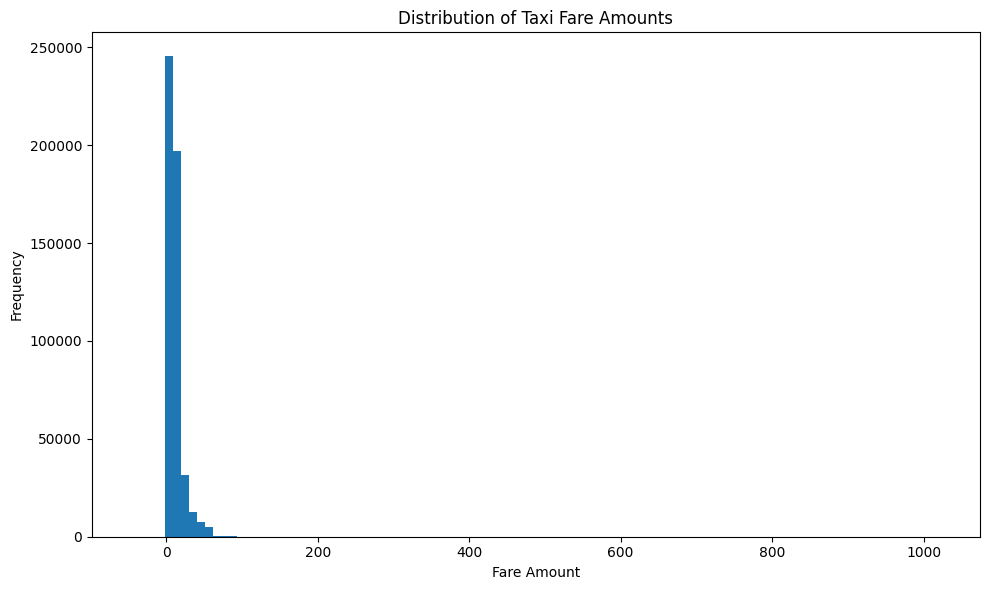

In [51]:
# 3.2.1 Fare Amount Histogram

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(
    eda_sample["fare_amount"],
    bins=100
)

plt.xlabel("Fare Amount")
plt.ylabel("Frequency")
plt.title("Distribution of Taxi Fare Amounts")

plt.tight_layout()
plt.show()

### 3.2.2 Fare Amount Box Plot

A box plot is used to visualize the median, interquartile range, overall spread, and potential extreme observations in the taxi fare variable.

The raw EDA sample is used without removing anomalies so that the original distribution can be assessed.

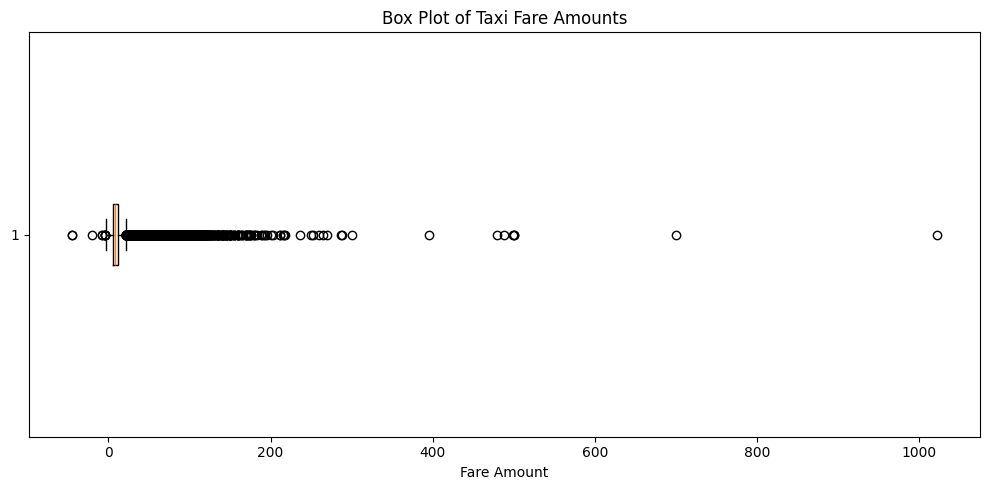

In [52]:
# 3.2.2 Fare Amount Box Plot

plt.figure(figsize=(10, 5))

plt.boxplot(
    eda_sample["fare_amount"].dropna(),
    vert=False
)

plt.xlabel("Fare Amount")
plt.title("Box Plot of Taxi Fare Amounts")

plt.tight_layout()
plt.show()

### 3.2.3 Fare Distribution Plot

A smooth distribution plot is used to visualize the overall shape of the taxi fare distribution.

Because the EDA sample contains 500,000 observations, a smaller reproducible subset is used for the density estimation to keep the visualization computationally efficient. The original EDA sample remains unchanged.

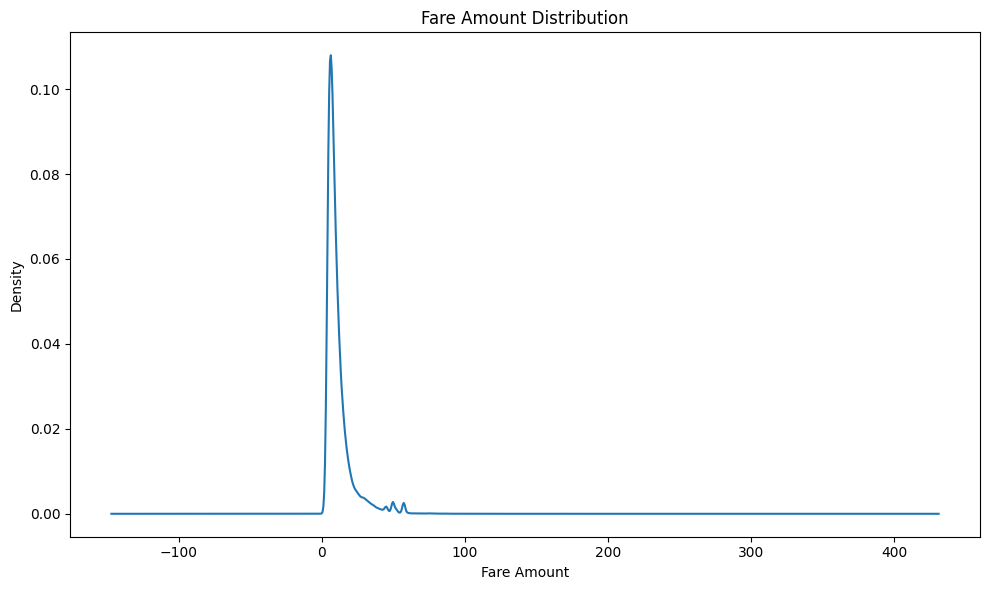

In [53]:
# 3.2.3 Fare Distribution Plot

fare_plot_sample = (
    eda_sample["fare_amount"]
    .dropna()
    .sample(
        n=min(100_000, len(eda_sample)),
        random_state=RANDOM_STATE
    )
)

plt.figure(figsize=(10, 6))

fare_plot_sample.plot(
    kind="kde"
)

plt.xlabel("Fare Amount")
plt.ylabel("Density")
plt.title("Fare Amount Distribution")

plt.tight_layout()
plt.show()

### 3.2.4 Passenger Count Bar Chart

A bar chart is used to visualize the frequency of different passenger-count categories in the EDA sample.

This visualization helps identify the dominant passenger-count category and potentially unusual values such as zero passengers.

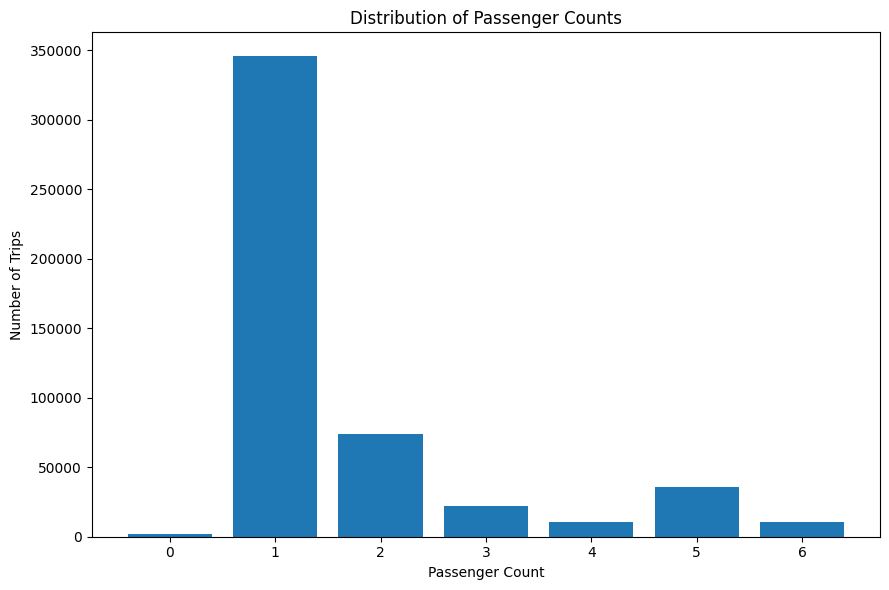

In [54]:
# 3.2.4 Passenger Count Bar Chart

passenger_counts = (
    eda_sample["passenger_count"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(9, 6))

plt.bar(
    passenger_counts.index.astype(str),
    passenger_counts.values
)

plt.xlabel("Passenger Count")
plt.ylabel("Number of Trips")
plt.title("Distribution of Passenger Counts")

plt.tight_layout()
plt.show()

## 3.3 Geographical Analysis

The spatial distribution of taxi pickup and dropoff locations is examined to identify geographic concentration, unusual coordinate values, and the relationship between trip locations and fare amounts.

Because the raw EDA sample contains mathematically invalid and geographically implausible coordinates, a bounded geographic subset is used for visualization. The original EDA sample remains unchanged, and anomalous coordinates are retained for separate investigation during preprocessing.

In [55]:
# 3.3.1 Create a plausible NYC geographic subset for visualization

NYC_LON_MIN = -75
NYC_LON_MAX = -73
NYC_LAT_MIN = 40
NYC_LAT_MAX = 42

geo_mask = (
    eda_sample["pickup_longitude"].between(NYC_LON_MIN, NYC_LON_MAX)
    & eda_sample["pickup_latitude"].between(NYC_LAT_MIN, NYC_LAT_MAX)
    & eda_sample["dropoff_longitude"].between(NYC_LON_MIN, NYC_LON_MAX)
    & eda_sample["dropoff_latitude"].between(NYC_LAT_MIN, NYC_LAT_MAX)
)

geo_sample = eda_sample.loc[geo_mask].copy()

print("Original EDA sample:", eda_sample.shape)
print("Geographically plausible trips:", geo_sample.shape)
print("Excluded trips:", len(eda_sample) - len(geo_sample))

Original EDA sample: (500000, 8)
Geographically plausible trips: (489494, 8)
Excluded trips: 10506


### 3.3.2 Pickup Location Distribution

The spatial distribution of pickup locations is visualized using longitude and latitude coordinates. This helps identify areas with high concentrations of taxi pickups and provides an initial view of the geographic structure of the dataset.

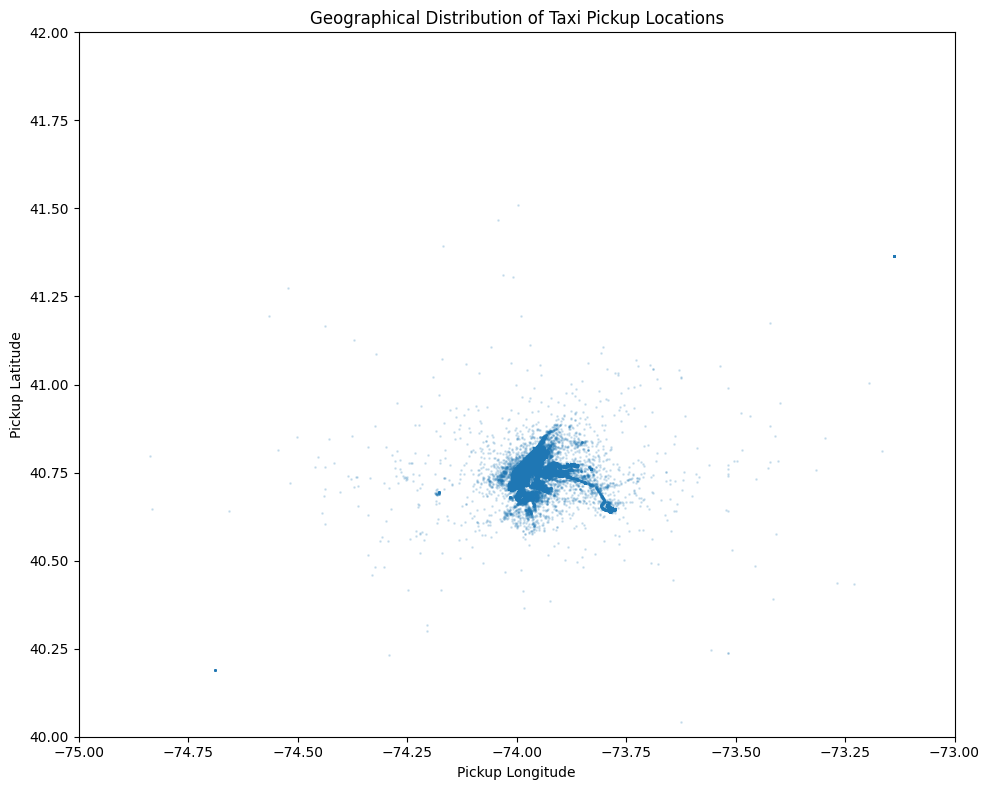

In [56]:
# 3.3.2 Pickup location scatter plot

plt.figure(figsize=(10, 8))

plt.scatter(
    geo_sample["pickup_longitude"],
    geo_sample["pickup_latitude"],
    s=1,
    alpha=0.15
)

plt.xlabel("Pickup Longitude")
plt.ylabel("Pickup Latitude")
plt.title("Geographical Distribution of Taxi Pickup Locations")

plt.xlim(-75, -73)
plt.ylim(40, 42)

plt.tight_layout()
plt.show()

### 3.3.3 Dropoff Location Distribution

The spatial distribution of taxi dropoff locations is visualized using longitude and latitude coordinates.

Comparing pickup and dropoff distributions helps identify whether passenger destinations follow similar geographic concentration patterns to pickup locations.

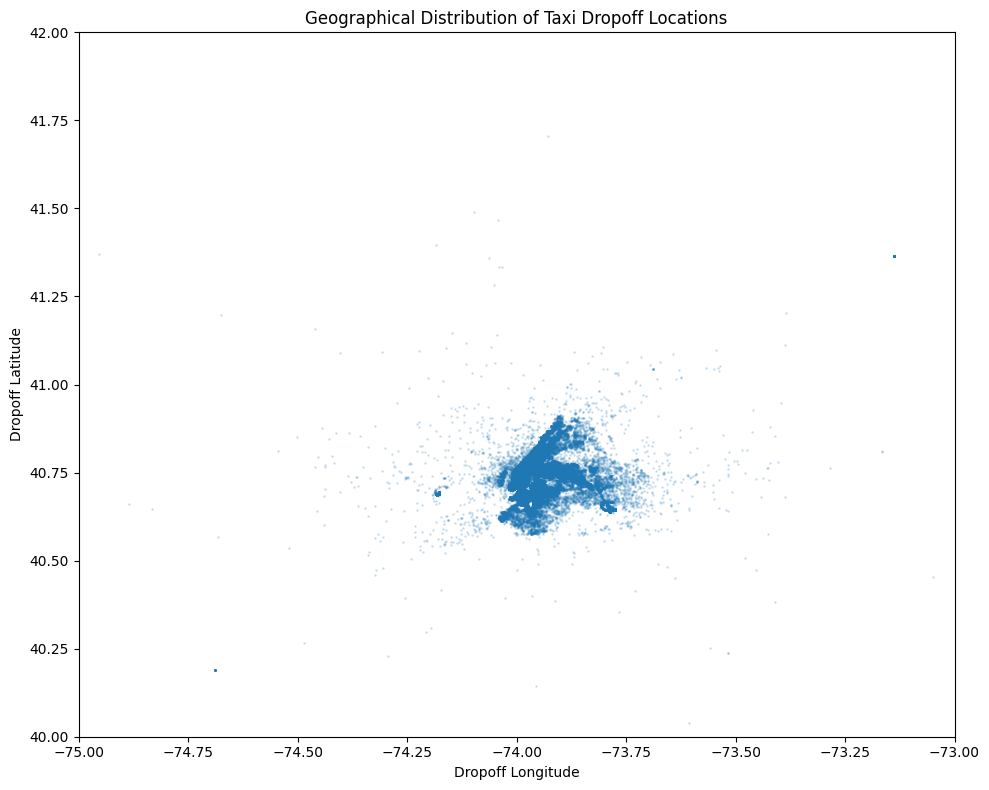

In [57]:
# 3.3.3 Dropoff location scatter plot

plt.figure(figsize=(10, 8))

plt.scatter(
    geo_sample["dropoff_longitude"],
    geo_sample["dropoff_latitude"],
    s=1,
    alpha=0.15
)

plt.xlabel("Dropoff Longitude")
plt.ylabel("Dropoff Latitude")
plt.title("Geographical Distribution of Taxi Dropoff Locations")

plt.xlim(-75, -73)
plt.ylim(40, 42)

plt.tight_layout()
plt.show()

### 3.3.4 Pickup-to-Dropoff Spatial Relationship

The relationship between pickup and dropoff locations is examined by plotting a subset of taxi trips as line segments connecting their origins and destinations.

A smaller reproducible sample is used for visualization to avoid excessive overplotting. This visualization provides an intuitive view of trip movement across the study area.

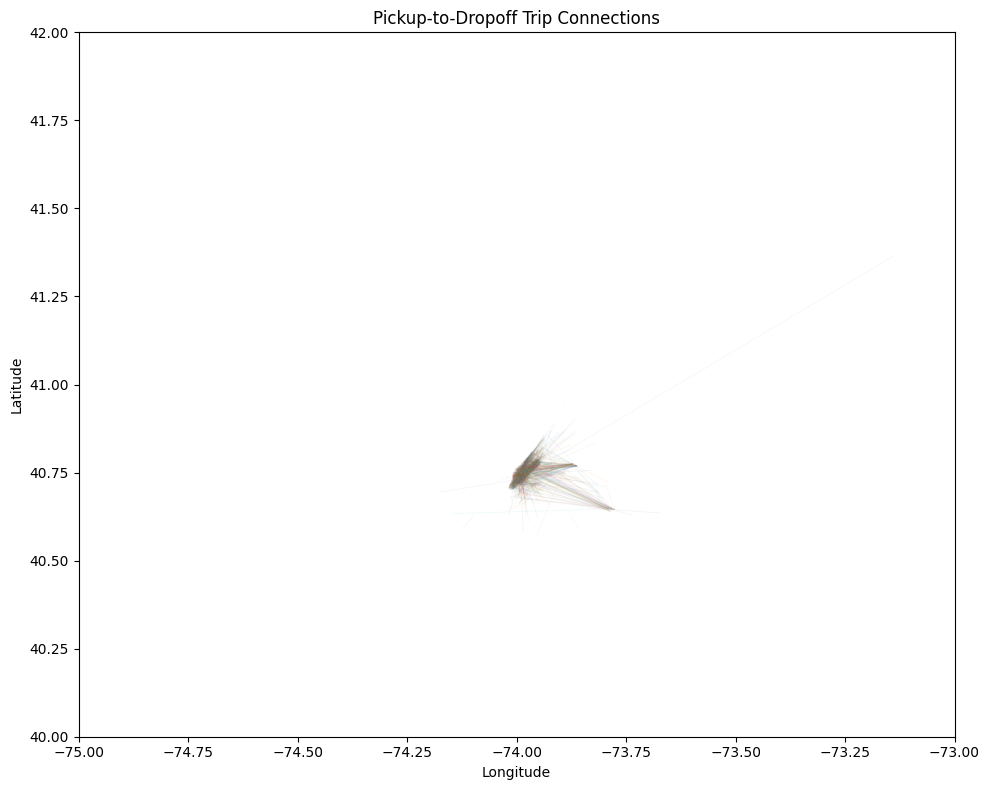

In [58]:
# 3.3.4 Improved pickup-to-dropoff spatial relationship

trip_lines = geo_sample.sample(
    n=min(3000, len(geo_sample)),
    random_state=RANDOM_STATE
)

plt.figure(figsize=(10, 8))

for _, row in trip_lines.iterrows():
    plt.plot(
        [row["pickup_longitude"], row["dropoff_longitude"]],
        [row["pickup_latitude"], row["dropoff_latitude"]],
        alpha=0.08,
        linewidth=0.5
    )

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Pickup-to-Dropoff Trip Connections")

plt.xlim(-75, -73)
plt.ylim(40, 42)

plt.tight_layout()
plt.show()

### 3.3.5 Geographic Anomaly Quantification

The sampled geographic coordinates are examined to quantify records containing mathematically invalid or geographically implausible values.

These records are flagged for later preprocessing. No records are removed or corrected during EDA.

In [59]:
# 3.3.5 Geographic anomaly quantification

coordinate_columns = [
    "pickup_longitude",
    "pickup_latitude",
    "dropoff_longitude",
    "dropoff_latitude"
]

# Mathematical validity
invalid_coordinate_mask = (
    (eda_sample["pickup_longitude"].abs() > 180) |
    (eda_sample["pickup_latitude"].abs() > 90) |
    (eda_sample["dropoff_longitude"].abs() > 180) |
    (eda_sample["dropoff_latitude"].abs() > 90)
)

# All-four-zero coordinates
all_zero_mask = (
    (eda_sample[coordinate_columns] == 0).all(axis=1)
)

# Broad NYC geographic validity
outside_nyc_mask = ~geo_mask

print("Total EDA records:", len(eda_sample))
print("Mathematically invalid coordinate records:", invalid_coordinate_mask.sum())
print("All-four-zero coordinate records:", all_zero_mask.sum())
print("Records outside broad NYC bounds:", outside_nyc_mask.sum())

print("\nCoordinate missing values:")
display(eda_sample[coordinate_columns].isna().sum())

Total EDA records: 500000
Mathematically invalid coordinate records: 31
All-four-zero coordinate records: 9040
Records outside broad NYC bounds: 10506

Coordinate missing values:


pickup_longitude     0
pickup_latitude      0
dropoff_longitude    2
dropoff_latitude     2
dtype: int64

## 3.4 Temporal and Ridership Analysis

The temporal characteristics of taxi trips are analyzed using the pickup timestamp.

The analysis examines trip frequency across:

- Hour of day
- Day of week
- Month
- Year
- Weekday versus weekend
- Peak versus off-peak periods
- Day of week versus hour of day

These patterns provide insight into taxi demand over different temporal periods.

In [60]:
# 3.4.1 Create temporal analysis features

temporal_sample = eda_sample.copy()

temporal_sample["year"] = temporal_sample["pickup_datetime"].dt.year
temporal_sample["month"] = temporal_sample["pickup_datetime"].dt.month
temporal_sample["day_of_week"] = temporal_sample["pickup_datetime"].dt.dayofweek
temporal_sample["day_name"] = temporal_sample["pickup_datetime"].dt.day_name()
temporal_sample["hour"] = temporal_sample["pickup_datetime"].dt.hour

temporal_sample["day_type"] = np.where(
    temporal_sample["day_of_week"] < 5,
    "Weekday",
    "Weekend"
)

print("Temporal analysis dataset shape:", temporal_sample.shape)

display(
    temporal_sample[
        [
            "pickup_datetime",
            "year",
            "month",
            "day_of_week",
            "day_name",
            "hour",
            "day_type"
        ]
    ].head()
)

Temporal analysis dataset shape: (500000, 14)


,pickup_datetime,year,month,day_of_week,day_name,hour,day_type
0,2012-09-29 11:20:00+00:00,2012,9,5,Saturday,11,Weekend
1,2013-12-17 19:19:00+00:00,2013,12,1,Tuesday,19,Weekday
2,2009-05-19 07:20:00+00:00,2009,5,1,Tuesday,7,Weekday
3,2012-03-04 01:45:00+00:00,2012,3,6,Sunday,1,Weekend
4,2011-12-22 21:41:00+00:00,2011,12,3,Thursday,21,Weekday


### 3.4.2 Ridership by Hour

The number of taxi trips is aggregated by hour of the day to identify periods of higher and lower taxi demand.

In [61]:
# 3.4.2 Trips by hour

trips_by_hour = (
    temporal_sample["hour"]
    .value_counts()
    .sort_index()
)

display(
    trips_by_hour.to_frame("Number of Trips")
)

,Number of Trips
hour,
0,19635
1,14581
2,11090
3,7905
4,5749
5,4895
6,10263
7,18097
8,22526


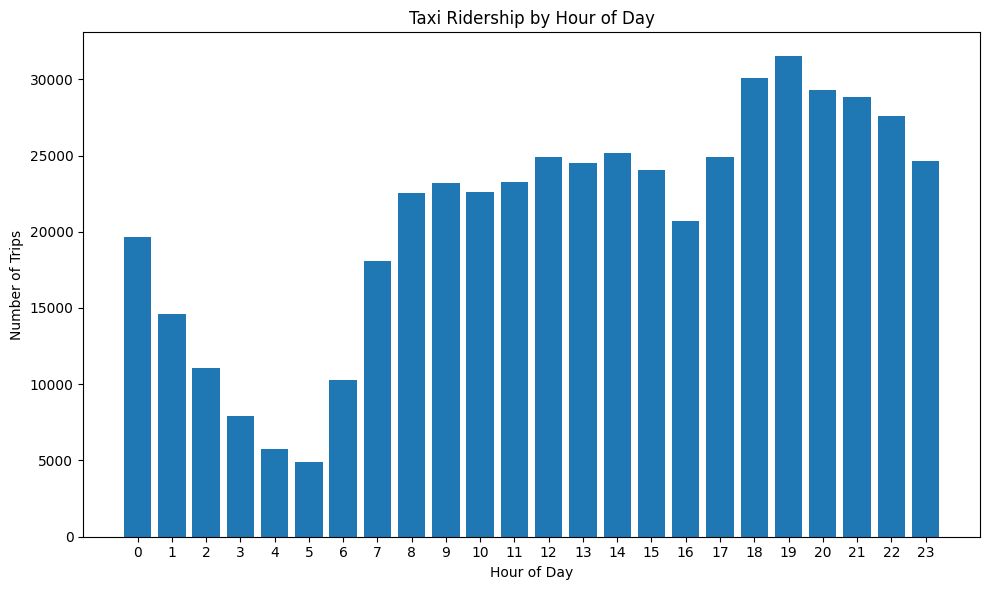

In [62]:
# Trips by hour visualization

plt.figure(figsize=(10, 6))

plt.bar(
    trips_by_hour.index,
    trips_by_hour.values
)

plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.title("Taxi Ridership by Hour of Day")
plt.xticks(range(24))

plt.tight_layout()
plt.show()

### 3.4.3 Ridership by Day of Week

The number of taxi trips is aggregated by day of the week to examine differences in taxi demand across weekdays and weekends.

In [63]:
# 3.4.3 Trips by day of week

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

trips_by_day = (
    temporal_sample["day_name"]
    .value_counts()
    .reindex(day_order)
)

display(
    trips_by_day.to_frame("Number of Trips")
)

,Number of Trips
day_name,
Monday,63981
Tuesday,69650
Wednesday,73228
Thursday,75114
Friday,76933
Saturday,75497
Sunday,65597


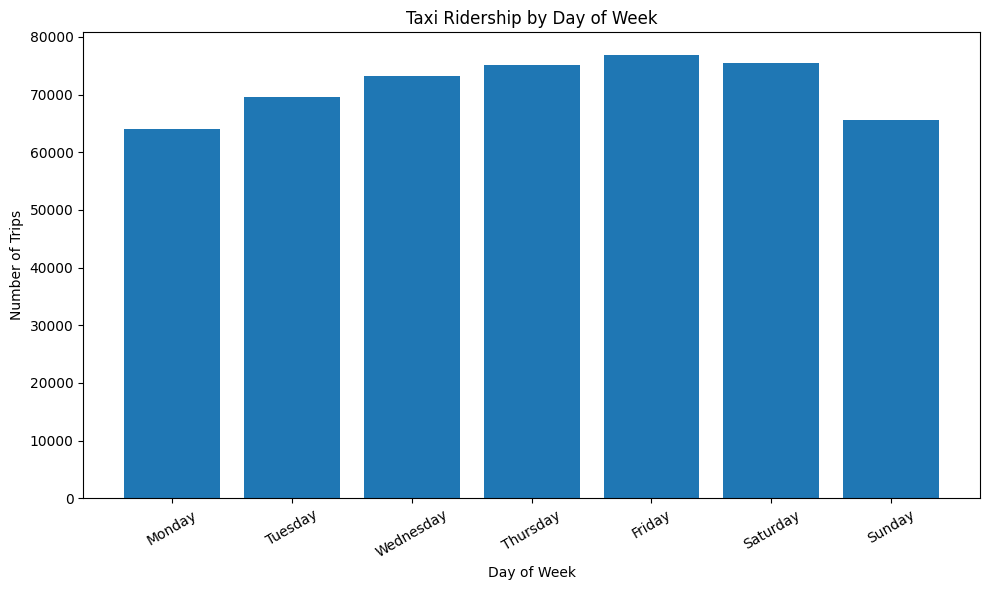

In [64]:
# Trips by day of week visualization

plt.figure(figsize=(10, 6))

plt.bar(
    trips_by_day.index,
    trips_by_day.values
)

plt.xlabel("Day of Week")
plt.ylabel("Number of Trips")
plt.title("Taxi Ridership by Day of Week")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

### 3.4.4 Weekday vs Weekend Ridership

Taxi trip frequency is compared between weekdays and weekends to identify differences in overall demand between the two day types.

In [65]:
# 3.4.4 Weekday vs weekend trip counts

trips_by_day_type = (
    temporal_sample["day_type"]
    .value_counts()
    .reindex(["Weekday", "Weekend"])
)

weekday_weekend_summary = pd.DataFrame({
    "Number of Trips": trips_by_day_type,
    "Percentage": (trips_by_day_type / len(temporal_sample)) * 100
})

display(weekday_weekend_summary)

,Number of Trips,Percentage
day_type,,
Weekday,358906,71.7812
Weekend,141094,28.2188


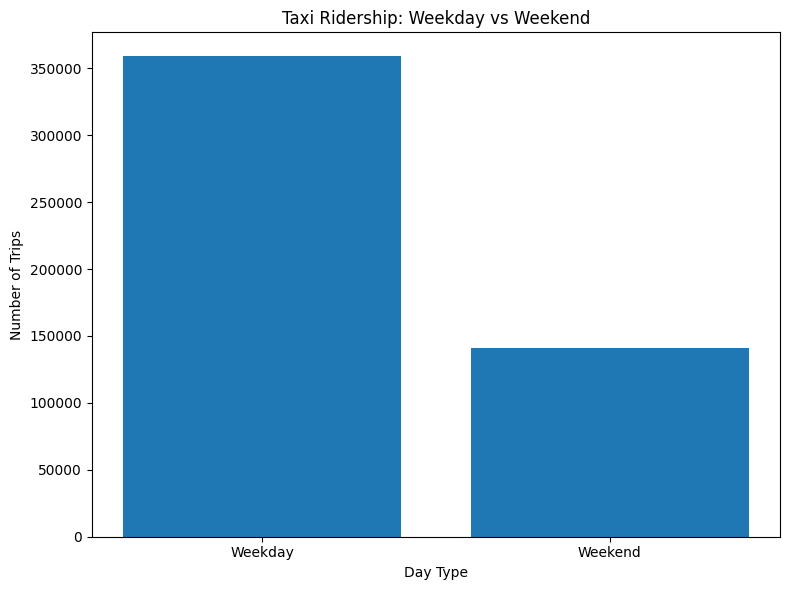

In [66]:
# Weekday vs weekend visualization

plt.figure(figsize=(8, 6))

plt.bar(
    weekday_weekend_summary.index,
    weekday_weekend_summary["Number of Trips"]
)

plt.xlabel("Day Type")
plt.ylabel("Number of Trips")
plt.title("Taxi Ridership: Weekday vs Weekend")

plt.tight_layout()
plt.show()

### 3.4.5 Ridership by Month

The number of taxi trips is aggregated by month to examine seasonal variation in taxi demand throughout the year.

In [67]:
# 3.4.5 Trips by month

trips_by_month = (
    temporal_sample["month"]
    .value_counts()
    .sort_index()
)

display(
    trips_by_month.to_frame("Number of Trips")
)

,Number of Trips
month,
1,44397
2,41968
3,47083
4,46112
5,47556
6,45011
7,38242
8,35500
9,37829


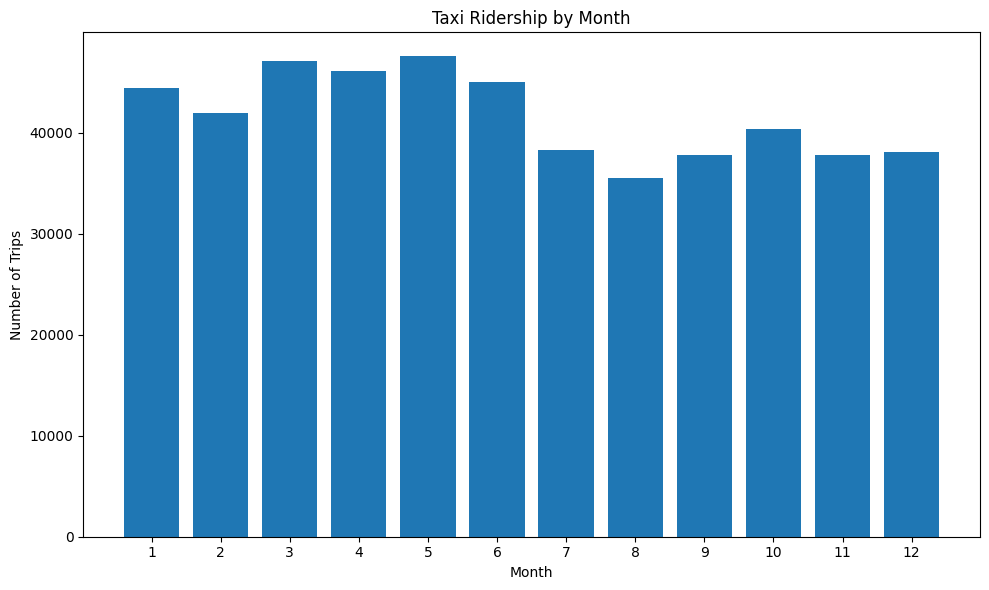

In [68]:
# Trips by month visualization

plt.figure(figsize=(10, 6))

plt.bar(
    trips_by_month.index,
    trips_by_month.values
)

plt.xlabel("Month")
plt.ylabel("Number of Trips")
plt.title("Taxi Ridership by Month")
plt.xticks(range(1, 13))

plt.tight_layout()
plt.show()

### 3.4.6 Ridership by Year

The number of taxi trips is aggregated by year to examine changes in the volume of observations across the dataset's time period.

In [69]:
# 3.4.6 Trips by year

trips_by_year = (
    temporal_sample["year"]
    .value_counts()
    .sort_index()
)

display(
    trips_by_year.to_frame("Number of Trips")
)

,Number of Trips
year,
2009,76940
2010,75380
2011,79832
2012,80443
2013,78093
2014,74483
2015,34829


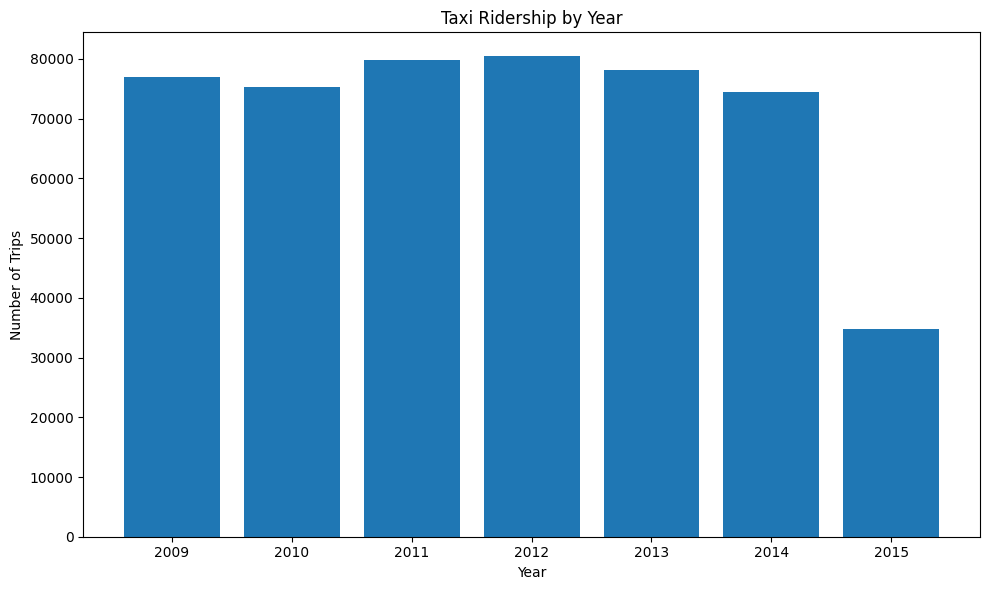

In [70]:
# Trips by year visualization

plt.figure(figsize=(10, 6))

plt.bar(
    trips_by_year.index.astype(str),
    trips_by_year.values
)

plt.xlabel("Year")
plt.ylabel("Number of Trips")
plt.title("Taxi Ridership by Year")

plt.tight_layout()
plt.show()

### 3.4.7 Peak vs Off-Peak Ridership

For temporal demand analysis, peak periods are defined as:

- Morning peak: 07:00–09:00
- Evening peak: 17:00–20:00

All remaining hours are classified as off-peak.

This definition is applied consistently to the EDA sample before calculating trip frequencies.

In [71]:
# 3.4.7 Peak vs off-peak classification

peak_hours = [7, 8, 9, 17, 18, 19, 20]

temporal_sample["period"] = np.where(
    temporal_sample["hour"].isin(peak_hours),
    "Peak",
    "Off-Peak"
)

trips_by_period = (
    temporal_sample["period"]
    .value_counts()
    .reindex(["Peak", "Off-Peak"])
)

peak_offpeak_summary = pd.DataFrame({
    "Number of Trips": trips_by_period,
    "Percentage": (trips_by_period / len(temporal_sample)) * 100
})

display(peak_offpeak_summary)

,Number of Trips,Percentage
period,,
Peak,179565,35.913
Off-Peak,320435,64.087


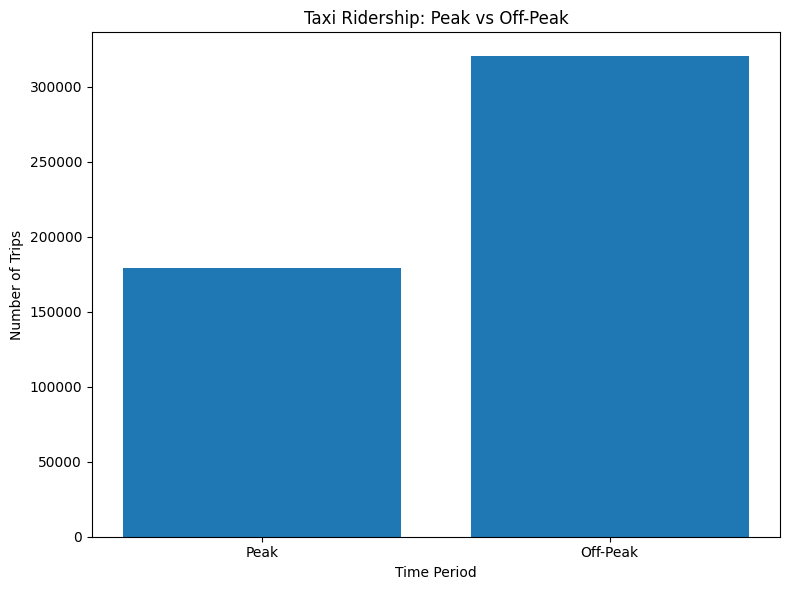

In [72]:
# Peak vs off-peak visualization

plt.figure(figsize=(8, 6))

plt.bar(
    peak_offpeak_summary.index,
    peak_offpeak_summary["Number of Trips"]
)

plt.xlabel("Time Period")
plt.ylabel("Number of Trips")
plt.title("Taxi Ridership: Peak vs Off-Peak")

plt.tight_layout()
plt.show()

### 3.4.8 Day of Week × Hour Ridership Heatmap

A heatmap is used to examine the interaction between day of the week and hour of the day.

The resulting matrix shows the number of taxi trips for each combination of weekday and hour, allowing periods of relatively high and low demand to be identified.

In [73]:
# 3.4.8 Day × Hour ridership heatmap

day_hour_counts = pd.crosstab(
    temporal_sample["day_name"],
    temporal_sample["hour"]
).reindex(day_order)

display(day_hour_counts)

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
day_name,,,,,,,,,,,,,,,,,,,,,
Monday,1633,961,652,444,462,670,1584,2874,3542,3412,...,3390,3288,2922,3571,4353,4183,3914,3694,3331,2454
Tuesday,1740,988,622,419,359,651,1774,3209,3906,3789,...,3613,3377,2894,3733,4555,4659,4441,4117,3842,3138
Wednesday,2099,1256,792,538,436,676,1829,3480,4168,3943,...,3648,3505,2980,3600,4353,4942,4515,4617,4212,3448
Thursday,2400,1527,933,607,534,645,1870,3457,3969,3908,...,3674,3557,2855,3491,4600,4867,4639,4699,4525,4082
Friday,3182,2190,1459,966,769,744,1711,3019,3910,3782,...,3655,3427,2851,3589,4411,5005,4650,4527,4629,4607
Saturday,4268,3691,3177,2300,1538,701,782,1163,1734,2462,...,3745,3633,3142,3550,4242,4451,4113,4182,4296,4637
Sunday,4313,3968,3455,2631,1651,808,713,895,1297,1902,...,3459,3272,3043,3337,3556,3395,3029,2977,2775,2241


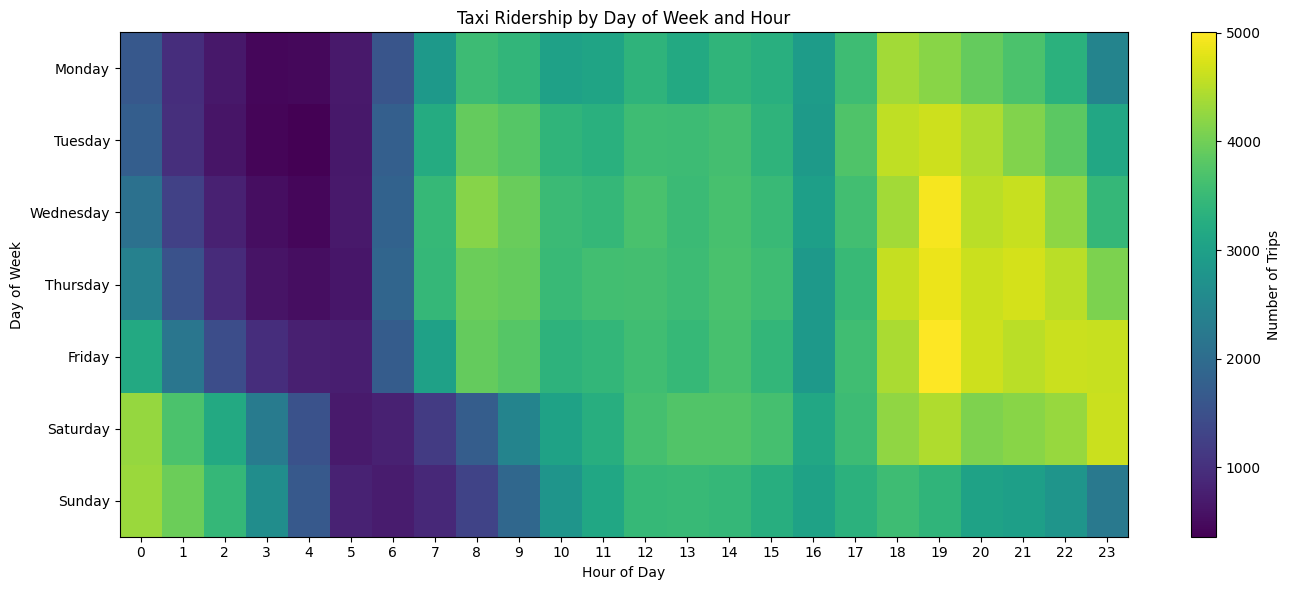

In [74]:
# Day × Hour heatmap

plt.figure(figsize=(14, 6))

plt.imshow(
    day_hour_counts,
    aspect="auto"
)

plt.colorbar(label="Number of Trips")

plt.xticks(
    range(24),
    range(24)
)

plt.yticks(
    range(len(day_order)),
    day_order
)

plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.title("Taxi Ridership by Day of Week and Hour")

plt.tight_layout()
plt.show()

# 4. Data Preprocessing and Anomaly Handling

The exploratory analysis identified several data-quality issues, including missing dropoff coordinates, mathematically invalid geographic coordinates, zero-coordinate records, negative and zero fare values, unusually high fares, and zero passenger counts.

The preprocessing stage applies explicit, reproducible rules to address these issues. Each rule is based on the characteristics identified during EDA.

The original raw dataset remains unchanged. Cleaning is performed on a separate modeling dataset.

In [75]:
# 4.1 Initial anomaly summary

preprocess_sample = eda_sample.copy()

print("Preprocessing sample shape:", preprocess_sample.shape)

print("\n--- Fare anomalies ---")
print("Negative fares:", (preprocess_sample["fare_amount"] < 0).sum())
print("Zero fares:", (preprocess_sample["fare_amount"] == 0).sum())
print("Fares >= 100:", (preprocess_sample["fare_amount"] >= 100).sum())

print("\n--- Passenger anomalies ---")
print("Passenger count = 0:", (preprocess_sample["passenger_count"] == 0).sum())

print("\n--- Coordinate anomalies ---")

coordinate_columns = [
    "pickup_longitude",
    "pickup_latitude",
    "dropoff_longitude",
    "dropoff_latitude"
]

print(
    "Missing coordinate records:",
    preprocess_sample[coordinate_columns].isna().any(axis=1).sum()
)

print(
    "Mathematically invalid coordinate records:",
    invalid_coordinate_mask.sum()
)

print(
    "All-four-zero coordinate records:",
    all_zero_mask.sum()
)

print(
    "Outside broad NYC bounds:",
    outside_nyc_mask.sum()
)

Preprocessing sample shape: (500000, 8)

--- Fare anomalies ---
Negative fares: 16
Zero fares: 13
Fares >= 100: 231

--- Passenger anomalies ---
Passenger count = 0: 1765

--- Coordinate anomalies ---
Missing coordinate records: 2
Mathematically invalid coordinate records: 31
All-four-zero coordinate records: 9040
Outside broad NYC bounds: 10506


### 4.2 Preprocessing Rules

Based on the EDA findings, the following preprocessing rules are defined:

1. Remove records with missing values in required modeling fields.
2. Remove records with mathematically invalid longitude or latitude values.
3. Remove records where all four geographic coordinates are zero.
4. Restrict geographic coordinates to a broad NYC study area for modeling consistency.
5. Remove records with non-positive fare amounts because fare amount is the regression target and negative/zero fares are not valid positive trip charges for this prediction task.
6. Investigate passenger_count = 0 separately rather than automatically treating it as invalid.
7. Retain high fare values initially and investigate them using their geographic and trip characteristics rather than removing them solely because they are large.

The cleaning rules are applied to a separate modeling dataset. The original raw dataset and EDA sample remain unchanged.

In [76]:
# 4.3 Preprocessing rule impact analysis

df_check = preprocess_sample.copy()

# Rule 1: Missing required fields
missing_required = df_check[
    coordinate_columns + ["fare_amount", "passenger_count", "pickup_datetime"]
].isna().any(axis=1)

# Rule 2: Mathematically invalid coordinates
invalid_coordinates = (
    (df_check["pickup_longitude"].abs() > 180) |
    (df_check["pickup_latitude"].abs() > 90) |
    (df_check["dropoff_longitude"].abs() > 180) |
    (df_check["dropoff_latitude"].abs() > 90)
)

# Rule 3: All coordinates equal to zero
all_coordinates_zero = (
    (df_check[coordinate_columns] == 0).all(axis=1)
)

# Rule 4: Outside broad NYC bounds
outside_nyc = ~(
    df_check["pickup_longitude"].between(-75, -73) &
    df_check["pickup_latitude"].between(40, 42) &
    df_check["dropoff_longitude"].between(-75, -73) &
    df_check["dropoff_latitude"].between(40, 42)
)

# Rule 5: Non-positive fares
non_positive_fare = df_check["fare_amount"] <= 0

# Rule 6: Zero passenger count
zero_passenger = df_check["passenger_count"] == 0

rule_impact = pd.DataFrame({
    "Rule": [
        "Missing required fields",
        "Mathematically invalid coordinates",
        "All coordinates equal to zero",
        "Outside broad NYC bounds",
        "Non-positive fare",
        "Passenger count = 0"
    ],
    "Affected Records": [
        missing_required.sum(),
        invalid_coordinates.sum(),
        all_coordinates_zero.sum(),
        outside_nyc.sum(),
        non_positive_fare.sum(),
        zero_passenger.sum()
    ]
})

display(rule_impact)

,Rule,Affected Records
0,Missing required fields,2
1,Mathematically invalid coordinates,31
2,All coordinates equal to zero,9040
3,Outside broad NYC bounds,10506
4,Non-positive fare,29
5,Passenger count = 0,1765


In [77]:
# Overlap between major coordinate/fare rules

major_anomaly_mask = (
    missing_required |
    invalid_coordinates |
    all_coordinates_zero |
    outside_nyc |
    non_positive_fare
)

print(
    "Unique records affected by the proposed primary cleaning rules:",
    major_anomaly_mask.sum()
)

print(
    "Records remaining after these primary rules:",
    len(df_check) - major_anomaly_mask.sum()
)

Unique records affected by the proposed primary cleaning rules: 10528
Records remaining after these primary rules: 489472


### 4.4 Investigation of Geographic Anomalies

Before removing geographically anomalous observations, representative records are examined to distinguish between missing/placeholder coordinates, mathematically invalid coordinates, and potentially valid trips outside the selected NYC visualization boundary.

No geographic records are removed at this stage.

In [78]:
# 4.4.1 Inspect records outside the broad NYC bounds

outside_nyc_records = preprocess_sample.loc[
    outside_nyc,
    [
        "key",
        "fare_amount",
        "pickup_datetime",
        "pickup_longitude",
        "pickup_latitude",
        "dropoff_longitude",
        "dropoff_latitude",
        "passenger_count"
    ]
].copy()

print("Total records outside broad NYC bounds:", len(outside_nyc_records))

display(
    outside_nyc_records.head(20)
)

Total records outside broad NYC bounds: 10506


,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
75,2011-11-09 10:05:00.00000063,7.3,2011-11-09 10:05:00+00:00,0.000000,0.000000,0.000000,0.000000,1
166,2014-05-04 10:31:08.0000005,5.0,2014-05-04 10:31:08+00:00,0.000000,0.000000,0.000000,0.000000,1
195,2012-02-26 06:19:00.00000033,5.3,2012-02-26 06:19:00+00:00,0.000000,0.000000,0.000000,0.000000,1
214,2011-06-07 19:16:51.0000001,6.9,2011-06-07 19:16:51+00:00,0.000000,0.000000,0.000000,0.000000,1
253,2010-04-11 23:34:17.0000002,4.9,2010-04-11 23:34:17+00:00,0.000000,0.000000,0.000000,0.000000,2
259,2013-12-04 15:23:31.0000003,9.0,2013-12-04 15:23:31+00:00,0.000000,0.000000,0.000000,0.000000,1
283,2013-05-26 19:31:00.000000130,4.5,2013-05-26 19:31:00+00:00,40.773540,-73.981720,40.767852,-73.970330,2
357,2011-06-05 01:40:00.000000125,6.1,2011-06-05 01:40:00+00:00,0.000000,0.000000,0.000000,0.000000,5
403,2013-12-02 07:23:00.000000123,6.5,2013-12-02 07:23:00+00:00,0.000000,0.000000,0.000000,0.000000,1
414,2014-09-04 21:59:18.0000001,5.0,2014-09-04 21:59:18+00:00,0.000000,0.000000,0.000000,0.000000,2


In [79]:
# 4.4.2 Inspect mathematically invalid coordinates

invalid_coordinate_records = preprocess_sample.loc[
    invalid_coordinates,
    [
        "key",
        "fare_amount",
        "pickup_datetime",
        "pickup_longitude",
        "pickup_latitude",
        "dropoff_longitude",
        "dropoff_latitude",
        "passenger_count"
    ]
].copy()

print(
    "Mathematically invalid coordinate records:",
    len(invalid_coordinate_records)
)

display(invalid_coordinate_records)

Mathematically invalid coordinate records: 31


,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
37534,2011-05-01 09:36:00.00000051,9.3,2011-05-01 09:36:00+00:00,-73.981268,488.566667,-73.963667,40.774052,1
68113,2012-02-22 13:09:00.00000086,6.5,2012-02-22 13:09:00+00:00,-2975.047802,-1757.195497,2497.105768,2589.499115,1
77348,2011-09-01 09:48:00.000000157,8.5,2011-09-01 09:48:00+00:00,-2647.971338,288.185538,-2647.971338,288.185538,1
77999,2012-04-21 02:27:00.00000011,17.7,2012-04-21 02:27:00+00:00,-74.001110,40.729192,-736.000000,40.785417,2
81527,2013-02-19 15:43:00.00000048,6.0,2013-02-19 15:43:00+00:00,-736.535000,40.738318,-73.986345,40.740363,1
89161,2011-10-30 13:38:00.00000040,5.3,2011-10-30 13:38:00+00:00,-736.533332,40.769465,-736.533332,40.769465,1
109588,2010-04-10 17:38:00.000000192,5.7,2010-04-10 17:38:00+00:00,-73.996952,40.728902,-723.516667,40.733315,1
116513,2012-08-03 12:09:00.00000057,31.3,2012-08-03 12:09:00+00:00,-73.863772,40.769392,-736.450000,40.758750,5
120162,2012-12-01 21:29:00.000000150,8.0,2012-12-01 21:29:00+00:00,0.000000,40.711372,-40.711372,238.906000,2
151960,2012-04-21 08:53:00.000000118,10.9,2012-04-21 08:53:00+00:00,-73.976592,40.762032,-736.166665,40.805937,1


### 4.4.3 Detection of Potentially Swapped Coordinates

Some records outside the NYC geographic bounds appear to have latitude and longitude values interchanged.

A record is considered a potential coordinate-swap candidate when:

- the current longitude values fall within the normal latitude range,
- the current latitude values fall within the normal longitude range, and
- swapping the corresponding latitude and longitude values places both pickup and dropoff locations within the broad NYC geographic bounds.

These records will be investigated before deciding whether correction is appropriate.

In [80]:
# 4.4.3 Detect potential latitude/longitude swaps

potential_swap_mask = (
    # Current pickup values look swapped
    preprocess_sample["pickup_longitude"].between(40, 42) &
    preprocess_sample["pickup_latitude"].between(-75, -73) &
    
    # Current dropoff values look swapped
    preprocess_sample["dropoff_longitude"].between(40, 42) &
    preprocess_sample["dropoff_latitude"].between(-75, -73)
)

swap_candidates = preprocess_sample.loc[
    potential_swap_mask,
    [
        "key",
        "fare_amount",
        "pickup_datetime",
        "pickup_longitude",
        "pickup_latitude",
        "dropoff_longitude",
        "dropoff_latitude",
        "passenger_count"
    ]
].copy()

print("Potential coordinate-swap records:", len(swap_candidates))

display(swap_candidates)

Potential coordinate-swap records: 236


,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
283,2013-05-26 19:31:00.000000130,4.5,2013-05-26 19:31:00+00:00,40.773540,-73.981720,40.767852,-73.970330,2
1557,2013-05-21 21:12:00.000000142,5.5,2013-05-21 21:12:00+00:00,40.724872,-73.998940,40.734205,-73.989880,1
2826,2013-05-26 11:32:00.00000047,9.0,2013-05-26 11:32:00+00:00,40.750237,-73.990885,40.749987,-73.972202,2
3182,2013-05-22 00:25:00.000000111,7.0,2013-05-22 00:25:00+00:00,40.727847,-74.007113,40.749752,-73.995187,5
3290,2013-05-24 20:36:00.000000219,8.5,2013-05-24 20:36:00+00:00,40.749655,-73.991223,40.758887,-73.981025,1
...,...,...,...,...,...,...,...,...
484785,2013-05-23 19:11:00.000000141,13.5,2013-05-23 19:11:00+00:00,40.759117,-73.994245,40.773397,-73.952022,5
485395,2013-05-25 14:05:00.000000115,4.5,2013-05-25 14:05:00+00:00,40.751292,-73.975788,40.750712,-73.968305,1
489461,2013-05-20 09:46:00.000000160,9.5,2013-05-20 09:46:00+00:00,40.781947,-73.956200,40.761120,-73.969772,1
489671,2013-05-24 01:00:00.000000123,7.5,2013-05-24 01:00:00+00:00,40.770097,-73.960607,40.793290,-73.940860,5


In [81]:
# Verify whether swapping the coordinates places the trips inside NYC bounds

swap_valid_after_correction = (
    swap_candidates["pickup_latitude"].between(-75, -73) &
    swap_candidates["pickup_longitude"].between(40, 42) &
    swap_candidates["dropoff_latitude"].between(-75, -73) &
    swap_candidates["dropoff_longitude"].between(40, 42)
)

print(
    "Potential swaps valid after coordinate correction:",
    swap_valid_after_correction.sum()
)

display(
    swap_candidates.loc[
        swap_valid_after_correction
    ]
)

Potential swaps valid after coordinate correction: 236


,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
283,2013-05-26 19:31:00.000000130,4.5,2013-05-26 19:31:00+00:00,40.773540,-73.981720,40.767852,-73.970330,2
1557,2013-05-21 21:12:00.000000142,5.5,2013-05-21 21:12:00+00:00,40.724872,-73.998940,40.734205,-73.989880,1
2826,2013-05-26 11:32:00.00000047,9.0,2013-05-26 11:32:00+00:00,40.750237,-73.990885,40.749987,-73.972202,2
3182,2013-05-22 00:25:00.000000111,7.0,2013-05-22 00:25:00+00:00,40.727847,-74.007113,40.749752,-73.995187,5
3290,2013-05-24 20:36:00.000000219,8.5,2013-05-24 20:36:00+00:00,40.749655,-73.991223,40.758887,-73.981025,1
...,...,...,...,...,...,...,...,...
484785,2013-05-23 19:11:00.000000141,13.5,2013-05-23 19:11:00+00:00,40.759117,-73.994245,40.773397,-73.952022,5
485395,2013-05-25 14:05:00.000000115,4.5,2013-05-25 14:05:00+00:00,40.751292,-73.975788,40.750712,-73.968305,1
489461,2013-05-20 09:46:00.000000160,9.5,2013-05-20 09:46:00+00:00,40.781947,-73.956200,40.761120,-73.969772,1
489671,2013-05-24 01:00:00.000000123,7.5,2013-05-24 01:00:00+00:00,40.770097,-73.960607,40.793290,-73.940860,5


### 4.4.4 Correct Confirmed Coordinate Interchanges

The 236 records identified as consistent latitude/longitude interchange cases are corrected by swapping the corresponding pickup and dropoff coordinate values.

The correction is applied only to records satisfying both conditions:

1. The original coordinate orientation matches the detected swap pattern.
2. After swapping, both pickup and dropoff coordinates fall within the defined NYC geographic bounds.

No other coordinate records are modified.

In [82]:
# 4.4.4 Apply confirmed coordinate-swap correction

corrected_sample = preprocess_sample.copy()

# Confirmed swap records
confirmed_swap_mask = potential_swap_mask & swap_valid_after_correction.reindex(
    preprocess_sample.index,
    fill_value=False
)

print("Records to be corrected:", confirmed_swap_mask.sum())

# Swap pickup coordinates
corrected_sample.loc[confirmed_swap_mask, "pickup_longitude"], \
corrected_sample.loc[confirmed_swap_mask, "pickup_latitude"] = (
    preprocess_sample.loc[confirmed_swap_mask, "pickup_latitude"].values,
    preprocess_sample.loc[confirmed_swap_mask, "pickup_longitude"].values
)

# Swap dropoff coordinates
corrected_sample.loc[confirmed_swap_mask, "dropoff_longitude"], \
corrected_sample.loc[confirmed_swap_mask, "dropoff_latitude"] = (
    preprocess_sample.loc[confirmed_swap_mask, "dropoff_latitude"].values,
    preprocess_sample.loc[confirmed_swap_mask, "dropoff_longitude"].values
)

print("Coordinate correction completed.")

Records to be corrected: 236
Coordinate correction completed.


In [83]:
# Verify corrected records

corrected_records = corrected_sample.loc[
    confirmed_swap_mask,
    [
        "key",
        "pickup_longitude",
        "pickup_latitude",
        "dropoff_longitude",
        "dropoff_latitude"
    ]
]

display(corrected_records.head(10))

,key,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude
283,2013-05-26 19:31:00.000000130,-73.981720,40.773540,-73.970330,40.767852
1557,2013-05-21 21:12:00.000000142,-73.998940,40.724872,-73.989880,40.734205
2826,2013-05-26 11:32:00.00000047,-73.990885,40.750237,-73.972202,40.749987
3182,2013-05-22 00:25:00.000000111,-74.007113,40.727847,-73.995187,40.749752
3290,2013-05-24 20:36:00.000000219,-73.991223,40.749655,-73.981025,40.758887
6762,2013-05-23 17:09:00.000000106,-73.955137,40.780047,-73.988085,40.738002
11583,2013-05-24 12:24:00.000000117,-74.003842,40.720155,-73.986682,40.740360
16289,2013-05-21 16:06:00.00000064,-73.982542,40.721177,-73.990510,40.742002
20279,2013-05-24 22:25:00.00000086,-73.988312,40.718257,-73.988095,40.731245
21802,2013-05-22 10:08:00.00000099,-73.977117,40.779832,-73.989890,40.738717


In [84]:
# Check that all corrected records are now within the NYC bounds

corrected_geo_valid = (
    corrected_records["pickup_longitude"].between(-75, -73) &
    corrected_records["pickup_latitude"].between(40, 42) &
    corrected_records["dropoff_longitude"].between(-75, -73) &
    corrected_records["dropoff_latitude"].between(40, 42)
)

print(
    "Corrected records still outside NYC bounds:",
    (~corrected_geo_valid).sum()
)

Corrected records still outside NYC bounds: 0


### 4.5 Geographic Cleaning Rules

After investigation, the following geographic preprocessing rules are applied:

1. Records with missing required coordinates are removed because geographic trip distance cannot be calculated reliably without complete pickup and dropoff locations.

2. Records containing mathematically invalid coordinates are removed because longitude and latitude values outside their valid global ranges cannot represent valid geographic locations.

3. Records with all four coordinates equal to zero are removed because `(0, 0)` represents a placeholder/non-location value rather than a valid NYC taxi location.

4. Confirmed latitude/longitude interchange errors are corrected by swapping the corresponding coordinate pairs. This correction is applied only when the swapped coordinates satisfy the defined NYC geographic bounds.

5. Remaining records outside the broad NYC geographic bounds are removed from the modeling dataset because the prediction task is based on NYC taxi trips and the selected study area is used to maintain geographic consistency.

The raw dataset and original EDA sample are not modified.

In [85]:
# 4.5 Apply geographic cleaning rules to the sample

geo_clean_sample = corrected_sample.copy()

# Required coordinate fields must be present
geo_missing_mask = geo_clean_sample[coordinate_columns].isna().any(axis=1)

# Mathematically invalid coordinates
geo_invalid_mask = (
    (geo_clean_sample["pickup_longitude"].abs() > 180) |
    (geo_clean_sample["pickup_latitude"].abs() > 90) |
    (geo_clean_sample["dropoff_longitude"].abs() > 180) |
    (geo_clean_sample["dropoff_latitude"].abs() > 90)
)

# All coordinates equal to zero
geo_zero_mask = (
    (geo_clean_sample[coordinate_columns] == 0).all(axis=1)
)

# Remaining records must fall within the broad NYC bounds
geo_outside_mask = ~(
    geo_clean_sample["pickup_longitude"].between(-75, -73) &
    geo_clean_sample["pickup_latitude"].between(40, 42) &
    geo_clean_sample["dropoff_longitude"].between(-75, -73) &
    geo_clean_sample["dropoff_latitude"].between(40, 42)
)

geo_remove_mask = (
    geo_missing_mask |
    geo_invalid_mask |
    geo_zero_mask |
    geo_outside_mask
)

print("Records before geographic cleaning:", len(geo_clean_sample))
print("Records removed by geographic rules:", geo_remove_mask.sum())
print("Records remaining:", (~geo_remove_mask).sum())

Records before geographic cleaning: 500000
Records removed by geographic rules: 10270
Records remaining: 489730


In [86]:
# Verify geographic validity after cleaning

geo_clean_sample = geo_clean_sample.loc[
    ~geo_remove_mask
].copy()

final_geo_valid = (
    geo_clean_sample["pickup_longitude"].between(-75, -73) &
    geo_clean_sample["pickup_latitude"].between(40, 42) &
    geo_clean_sample["dropoff_longitude"].between(-75, -73) &
    geo_clean_sample["dropoff_latitude"].between(40, 42)
)

print("Geographically valid records remaining:", final_geo_valid.sum())
print("Records failing final geographic validation:", (~final_geo_valid).sum())

Geographically valid records remaining: 489730
Records failing final geographic validation: 0


### 4.6 Fare Anomaly Investigation

Fare anomalies are investigated after geographic preprocessing.

Negative and zero fare amounts are treated as invalid target values for the regression task. Extremely high fares are investigated separately because a high fare may correspond to a legitimate long-distance trip and should not be removed solely because it is statistically unusual.

In [87]:
# 4.6.1 Fare anomalies after geographic cleaning

print("Records after geographic cleaning:", len(geo_clean_sample))

print("\n--- Fare anomaly counts ---")

print(
    "Negative fares:",
    (geo_clean_sample["fare_amount"] < 0).sum()
)

print(
    "Zero fares:",
    (geo_clean_sample["fare_amount"] == 0).sum()
)

print(
    "Non-positive fares:",
    (geo_clean_sample["fare_amount"] <= 0).sum()
)

print(
    "Fares >= 100:",
    (geo_clean_sample["fare_amount"] >= 100).sum()
)

Records after geographic cleaning: 489730

--- Fare anomaly counts ---
Negative fares: 13
Zero fares: 9
Non-positive fares: 22
Fares >= 100: 204


In [88]:
# 4.6.2 Inspect high-fare observations

high_fare_records = geo_clean_sample.loc[
    geo_clean_sample["fare_amount"] >= 100,
    [
        "key",
        "fare_amount",
        "pickup_datetime",
        "pickup_longitude",
        "pickup_latitude",
        "dropoff_longitude",
        "dropoff_latitude",
        "passenger_count"
    ]
].sort_values(
    "fare_amount",
    ascending=False
)

print("High-fare records:", len(high_fare_records))

display(high_fare_records.head(20))

High-fare records: 204


,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
142849,2014-01-29 01:52:34.0000001,500.00,2014-01-29 01:52:34+00:00,-73.977378,40.742028,-73.977378,40.742028,1
310637,2015-01-05 12:28:20.0000001,500.00,2015-01-05 12:28:20+00:00,-73.976692,40.751629,-73.976692,40.751621,1
194985,2011-04-10 04:10:00.00000064,499.00,2011-04-10 04:10:00+00:00,-73.968377,40.764602,-73.968368,40.764600,1
18375,2011-09-08 00:32:00.00000020,488.00,2011-09-08 00:32:00+00:00,-73.999437,40.721837,-74.048855,40.731560,1
28309,2014-06-03 13:30:12.0000006,395.00,2014-06-03 13:30:12+00:00,-73.921172,40.803800,-73.878127,40.874199,1
185977,2012-08-27 19:22:00.000000180,301.00,2012-08-27 19:22:00+00:00,-74.042165,41.466280,-74.042175,41.466282,1
31373,2013-07-07 15:16:10.0000003,286.58,2013-07-07 15:16:10+00:00,-73.877045,40.772971,-74.097929,41.489425,1
287588,2015-03-31 18:26:39.0000002,270.00,2015-03-31 18:26:39+00:00,-74.453079,40.794739,-74.453079,40.794758,1
193494,2013-04-30 11:53:06.0000004,265.00,2013-04-30 11:53:06+00:00,-74.081843,40.810049,-74.683106,40.567210,1
20328,2014-09-02 19:49:00.00000098,252.33,2014-09-02 19:49:00+00:00,-73.886362,40.766007,-73.387885,41.113322,1


### 4.6.3 High-Fare Investigation Using Geographic Distance

High-fare observations are examined using the geographic distance between pickup and dropoff locations.

The Haversine formula is used to estimate the great-circle distance between the two coordinate pairs. This helps distinguish potentially legitimate high fares associated with longer trips from observations that have unusually high fares despite very short geographic distances.

High fares are not removed solely on the basis of their magnitude.

In [89]:
# 4.6.3 Calculate Haversine distance for high-fare observations

import numpy as np

def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Calculate great-circle distance between two geographic points.
    Returns distance in kilometers.
    """
    
    R = 6371.0  # Earth radius in kilometers
    
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )
    
    c = 2 * np.arcsin(np.sqrt(a))
    
    return R * c


high_fare_records = high_fare_records.copy()

high_fare_records["distance_km"] = haversine_distance(
    high_fare_records["pickup_latitude"],
    high_fare_records["pickup_longitude"],
    high_fare_records["dropoff_latitude"],
    high_fare_records["dropoff_longitude"]
)

display(
    high_fare_records[
        [
            "fare_amount",
            "distance_km",
            "pickup_latitude",
            "pickup_longitude",
            "dropoff_latitude",
            "dropoff_longitude",
            "passenger_count"
        ]
    ].head(20)
)

,fare_amount,distance_km,pickup_latitude,pickup_longitude,dropoff_latitude,dropoff_longitude,passenger_count
142849,500.00,0.000000,40.742028,-73.977378,40.742028,-73.977378,1
310637,500.00,0.000848,40.751629,-73.976692,40.751621,-73.976692,1
194985,499.00,0.000790,40.764602,-73.968377,40.764600,-73.968368,1
18375,488.00,4.302358,40.721837,-73.999437,40.731560,-74.048855,1
28309,395.00,8.624988,40.803800,-73.921172,40.874199,-73.878127,1
185977,301.00,0.000862,41.466280,-74.042165,41.466282,-74.042175,1
31373,286.58,81.785697,40.772971,-73.877045,41.489425,-74.097929,1
287588,270.00,0.002121,40.794739,-74.453079,40.794758,-74.453079,1
193494,265.00,57.438213,40.810049,-74.081843,40.567210,-74.683106,1
20328,252.33,56.961273,40.766007,-73.886362,41.113322,-73.387885,1


In [90]:
# Identify potentially suspicious high-fare / short-distance observations

suspicious_high_fares = high_fare_records[
    (high_fare_records["fare_amount"] >= 100) &
    (high_fare_records["distance_km"] < 1)
].copy()

print(
    "High-fare records with distance < 1 km:",
    len(suspicious_high_fares)
)

display(
    suspicious_high_fares[
        [
            "key",
            "fare_amount",
            "distance_km",
            "pickup_datetime",
            "passenger_count"
        ]
    ].head(20)
)

High-fare records with distance < 1 km: 86


,key,fare_amount,distance_km,pickup_datetime,passenger_count
142849,2014-01-29 01:52:34.0000001,500.00,0.000000,2014-01-29 01:52:34+00:00,1
310637,2015-01-05 12:28:20.0000001,500.00,0.000848,2015-01-05 12:28:20+00:00,1
194985,2011-04-10 04:10:00.00000064,499.00,0.000790,2011-04-10 04:10:00+00:00,1
185977,2012-08-27 19:22:00.000000180,301.00,0.000862,2012-08-27 19:22:00+00:00,1
287588,2015-03-31 18:26:39.0000002,270.00,0.002121,2015-03-31 18:26:39+00:00,1
427086,2013-09-16 12:06:13.0000004,250.00,0.002220,2013-09-16 12:06:13+00:00,2
125138,2010-10-25 18:16:00.000000219,236.00,0.000000,2010-10-25 18:16:00+00:00,1
60946,2014-07-15 13:35:23.0000003,216.00,0.000084,2014-07-15 13:35:23+00:00,1
207770,2012-09-26 12:51:49.0000001,203.00,0.000000,2012-09-26 12:51:49+00:00,1
178777,2013-12-14 13:49:49.0000001,200.00,0.000000,2013-12-14 13:49:49+00:00,2


### 4.6.4 Fare-to-Distance Investigation

The relationship between fare amount and geographic distance is examined for high-fare observations.

A very high fare combined with an extremely short or zero geographic distance is treated as a potential data-quality anomaly. These observations are investigated separately rather than being removed solely because their fare values are large.

In [91]:
# 4.6.4 Calculate fare per kilometer for high-fare records

high_fare_analysis = high_fare_records.copy()

high_fare_analysis["fare_per_km"] = np.where(
    high_fare_analysis["distance_km"] > 0,
    high_fare_analysis["fare_amount"] / high_fare_analysis["distance_km"],
    np.inf
)

display(
    high_fare_analysis[
        [
            "key",
            "fare_amount",
            "distance_km",
            "fare_per_km",
            "pickup_datetime",
            "passenger_count"
        ]
    ].sort_values(
        "fare_amount",
        ascending=False
    ).head(30)
)

,key,fare_amount,distance_km,fare_per_km,pickup_datetime,passenger_count
142849,2014-01-29 01:52:34.0000001,500.00,0.000000,inf,2014-01-29 01:52:34+00:00,1
310637,2015-01-05 12:28:20.0000001,500.00,0.000848,5.893794e+05,2015-01-05 12:28:20+00:00,1
194985,2011-04-10 04:10:00.00000064,499.00,0.000790,6.317085e+05,2011-04-10 04:10:00+00:00,1
18375,2011-09-08 00:32:00.00000020,488.00,4.302358,1.134262e+02,2011-09-08 00:32:00+00:00,1
28309,2014-06-03 13:30:12.0000006,395.00,8.624988,4.579716e+01,2014-06-03 13:30:12+00:00,1
185977,2012-08-27 19:22:00.000000180,301.00,0.000862,3.490253e+05,2012-08-27 19:22:00+00:00,1
31373,2013-07-07 15:16:10.0000003,286.58,81.785697,3.504036e+00,2013-07-07 15:16:10+00:00,1
287588,2015-03-31 18:26:39.0000002,270.00,0.002121,1.273060e+05,2015-03-31 18:26:39+00:00,1
193494,2013-04-30 11:53:06.0000004,265.00,57.438213,4.613653e+00,2013-04-30 11:53:06+00:00,1
20328,2014-09-02 19:49:00.00000098,252.33,56.961273,4.429852e+00,2014-09-02 19:49:00+00:00,1


In [92]:
# Quantify extreme high-fare / very-short-distance observations

print("High-fare records:", len(high_fare_analysis))

print(
    "High-fare records with zero distance:",
    (high_fare_analysis["distance_km"] == 0).sum()
)

print(
    "High-fare records with distance < 0.1 km:",
    (high_fare_analysis["distance_km"] < 0.1).sum()
)

print(
    "High-fare records with distance < 1 km:",
    (high_fare_analysis["distance_km"] < 1).sum()
)

High-fare records: 204
High-fare records with zero distance: 36
High-fare records with distance < 0.1 km: 77
High-fare records with distance < 1 km: 86


In [93]:
# 4.6.5 Inspect zero-distance high-fare observations

zero_distance_high_fares = high_fare_analysis[
    (high_fare_analysis["fare_amount"] >= 100) &
    (high_fare_analysis["distance_km"] == 0)
].copy()

print(
    "Zero-distance high-fare records:",
    len(zero_distance_high_fares)
)

display(
    zero_distance_high_fares[
        [
            "key",
            "fare_amount",
            "distance_km",
            "pickup_datetime",
            "pickup_longitude",
            "pickup_latitude",
            "dropoff_longitude",
            "dropoff_latitude",
            "passenger_count"
        ]
    ].sort_values(
        "fare_amount",
        ascending=False
    )
)

Zero-distance high-fare records: 36


,key,fare_amount,distance_km,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
142849,2014-01-29 01:52:34.0000001,500.00,0.0,2014-01-29 01:52:34+00:00,-73.977378,40.742028,-73.977378,40.742028,1
125138,2010-10-25 18:16:00.000000219,236.00,0.0,2010-10-25 18:16:00+00:00,-74.833605,40.645695,-74.833605,40.645695,1
207770,2012-09-26 12:51:49.0000001,203.00,0.0,2012-09-26 12:51:49+00:00,-73.794136,40.657101,-73.794136,40.657101,1
178777,2013-12-14 13:49:49.0000001,200.00,0.0,2013-12-14 13:49:49+00:00,-74.365687,40.738507,-74.365687,40.738507,2
306752,2010-10-08 04:07:00.00000029,190.00,0.0,2010-10-08 04:07:00+00:00,-73.954327,40.770132,-73.954327,40.770132,1
288422,2009-03-22 19:13:22.0000001,165.00,0.0,2009-03-22 19:13:22+00:00,-73.993108,40.757978,-73.993108,40.757978,3
257616,2012-08-25 22:35:48.0000003,163.00,0.0,2012-08-25 22:35:48+00:00,-74.171845,40.416856,-74.171845,40.416856,1
83579,2012-01-18 23:28:49.0000002,152.30,0.0,2012-01-18 23:28:49+00:00,-74.370856,40.708619,-74.370856,40.708619,1
330421,2012-04-10 00:23:59.0000002,146.00,0.0,2012-04-10 00:23:59+00:00,-74.439056,40.683054,-74.439056,40.683054,1
16035,2014-03-20 20:13:00.000000174,144.44,0.0,2014-03-20 20:13:00+00:00,-73.671880,40.989377,-73.671880,40.989377,1


In [94]:
# Summary of zero-distance high fares

print("Minimum fare:", zero_distance_high_fares["fare_amount"].min())
print("Maximum fare:", zero_distance_high_fares["fare_amount"].max())
print("Median fare:", zero_distance_high_fares["fare_amount"].median())
print("Mean fare:", zero_distance_high_fares["fare_amount"].mean())

print("\nPassenger count distribution:")
display(
    zero_distance_high_fares["passenger_count"].value_counts().sort_index()
)

Minimum fare: 100.0
Maximum fare: 500.0
Median fare: 120.0
Mean fare: 142.21055555555554

Passenger count distribution:


passenger_count
0     1
1    30
2     4
3     1
Name: count, dtype: int64

### 4.7 Passenger Count Anomaly Investigation

Records with `passenger_count = 0` are investigated separately because zero may represent a data-entry issue, an unrecorded passenger count, or another operational circumstance.

These records are not removed automatically.

In [95]:
# 4.7.1 Inspect passenger_count = 0 records

zero_passenger_records = geo_clean_sample.loc[
    geo_clean_sample["passenger_count"] == 0,
    [
        "key",
        "fare_amount",
        "pickup_datetime",
        "pickup_longitude",
        "pickup_latitude",
        "dropoff_longitude",
        "dropoff_latitude",
        "passenger_count"
    ]
].copy()

print("Passenger count = 0 records:", len(zero_passenger_records))

display(
    zero_passenger_records.head(20)
)

Passenger count = 0 records: 1729


,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
42,2012-03-29 08:49:06.0000004,7.3,2012-03-29 08:49:06+00:00,-73.998815,40.729302,-73.980557,40.730133,0
90,2012-02-04 19:21:16.0000001,4.9,2012-02-04 19:21:16+00:00,-73.978058,40.752647,-73.982547,40.761317,0
361,2011-04-26 19:47:35.0000004,4.5,2011-04-26 19:47:35+00:00,-73.956365,40.786972,-73.952972,40.780158,0
416,2011-12-29 13:47:54.0000003,6.5,2011-12-29 13:47:54+00:00,-73.972300,40.762500,-73.977600,40.753600,0
944,2011-09-06 15:35:18.0000003,4.1,2011-09-06 15:35:18+00:00,-73.980900,40.758500,-73.992000,40.763800,0
1147,2011-09-24 20:04:44.0000002,4.1,2011-09-24 20:04:44+00:00,-74.006700,40.730100,-74.004200,40.738100,0
1447,2012-02-13 10:16:50.0000003,13.7,2012-02-13 10:16:50+00:00,-73.977873,40.786797,-73.986522,40.742080,0
1477,2011-09-06 15:46:28.0000004,4.5,2011-09-06 15:46:28+00:00,-73.968400,40.791400,-73.956400,40.788500,0
1512,2011-11-26 13:47:37.0000003,5.3,2011-11-26 13:47:37+00:00,-73.960500,40.757500,-73.975200,40.760600,0
1542,2011-04-26 20:03:45.0000006,4.5,2011-04-26 20:03:45+00:00,-73.986500,40.740308,-73.992262,40.749290,0


In [96]:
# 4.7.2 Compare fare statistics for zero vs non-zero passenger counts

passenger_comparison = (
    geo_clean_sample
    .assign(
        passenger_group=np.where(
            geo_clean_sample["passenger_count"] == 0,
            "Zero Passenger Count",
            "Positive Passenger Count"
        )
    )
    .groupby("passenger_group")["fare_amount"]
    .agg(
        Count="count",
        Mean="mean",
        Median="median",
        Minimum="min",
        Maximum="max"
    )
)

display(passenger_comparison)

,Count,Mean,Median,Minimum,Maximum
passenger_group,,,,,
Positive Passenger Count,488001,11.347166,8.5,-45.0,500.0
Zero Passenger Count,1729,9.034552,7.3,2.5,106.0


### 4.7.3 Passenger Count Cleaning Decision

The dataset contains 1,729 records with `passenger_count = 0` after geographic cleaning.

These records have positive fare amounts ranging from $2.50 to $106.00, indicating that they are not necessarily invalid trips. However, a passenger count of zero is not considered a valid passenger count for a completed taxi trip.

Therefore, these values are treated as invalid/missing rather than removing the complete records. The zero values will be converted to missing values and imputed using the median valid passenger count during the final preprocessing stage.

In [97]:
# 4.7.3 Verify valid passenger-count distribution

valid_passenger_counts = geo_clean_sample.loc[
    geo_clean_sample["passenger_count"] > 0,
    "passenger_count"
]

print("Valid passenger-count values:")
print(sorted(valid_passenger_counts.unique().tolist()))

print("\nMedian valid passenger count:")
print(valid_passenger_counts.median())

print("\nZero passenger records to be treated as missing:")
print((geo_clean_sample["passenger_count"] == 0).sum())

Valid passenger-count values:
[1, 2, 3, 4, 5, 6]

Median valid passenger count:
1.0

Zero passenger records to be treated as missing:
1729


In [98]:
# 4.7.4 Apply passenger-count cleaning

final_clean_sample = geo_clean_sample.copy()

# Convert invalid zero passenger counts to missing
final_clean_sample.loc[
    final_clean_sample["passenger_count"] == 0,
    "passenger_count"
] = np.nan

# Impute missing passenger counts using the median of valid values
valid_passenger_median = final_clean_sample["passenger_count"].median()

final_clean_sample["passenger_count"] = (
    final_clean_sample["passenger_count"]
    .fillna(valid_passenger_median)
    .astype(int)
)

print("Median used for imputation:", valid_passenger_median)
print(
    "Remaining missing passenger counts:",
    final_clean_sample["passenger_count"].isna().sum()
)
print(
    "Remaining zero passenger counts:",
    (final_clean_sample["passenger_count"] == 0).sum()
)
print("\nFinal passenger-count distribution:")
display(
    final_clean_sample["passenger_count"]
    .value_counts()
    .sort_index()
)

Median used for imputation: 1.0
Remaining missing passenger counts: 0
Remaining zero passenger counts: 0

Final passenger-count distribution:


passenger_count
1    340176
2     72346
3     21488
4     10570
5     34973
6     10177
Name: count, dtype: int64

### 4.8 Final Preprocessing Validation

After applying the documented anomaly-handling rules, the cleaned dataset is validated to ensure that critical missing values, invalid coordinates, non-positive fares, and zero passenger counts have been addressed before feature engineering.

In [99]:
# 4.8.1 Final preprocessing validation

print("Final cleaned sample shape:", final_clean_sample.shape)

print("\n--- Missing values ---")
display(final_clean_sample.isnull().sum())

print("\n--- Fare validation ---")
print("Non-positive fares:", (final_clean_sample["fare_amount"] <= 0).sum())
print("Fares >= 100:", (final_clean_sample["fare_amount"] >= 100).sum())

print("\n--- Passenger-count validation ---")
print("Zero passenger counts:", (final_clean_sample["passenger_count"] == 0).sum())
print(
    "Invalid passenger counts:",
    (~final_clean_sample["passenger_count"].isin([1, 2, 3, 4, 5, 6])).sum()
)

print("\n--- Coordinate validation ---")

final_coordinate_valid = (
    final_clean_sample["pickup_longitude"].between(-75, -73)
    & final_clean_sample["pickup_latitude"].between(40, 42)
    & final_clean_sample["dropoff_longitude"].between(-75, -73)
    & final_clean_sample["dropoff_latitude"].between(40, 42)
)

print("Records outside final NYC bounds:", (~final_coordinate_valid).sum())

print("\n--- Final dataset preview ---")
display(final_clean_sample.head())

Final cleaned sample shape: (489730, 8)

--- Missing values ---


key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
passenger_count      0
dtype: int64


--- Fare validation ---
Non-positive fares: 22
Fares >= 100: 204

--- Passenger-count validation ---
Zero passenger counts: 0
Invalid passenger counts: 0

--- Coordinate validation ---
Records outside final NYC bounds: 0

--- Final dataset preview ---


,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,2012-09-29 11:20:00.00000027,8.0,2012-09-29 11:20:00+00:00,-73.976105,40.744712,-73.990505,40.748607,5
1,2013-12-17 19:19:00.00000028,11.0,2013-12-17 19:19:00+00:00,-73.976157,40.727747,-73.976605,40.755937,2
2,2009-05-19 07:20:00.00000074,4.9,2009-05-19 07:20:00+00:00,-73.990513,40.750870,-73.987843,40.741877,3
3,2012-03-04 01:45:00.00000075,9.3,2012-03-04 01:45:00+00:00,-73.962020,40.760377,-73.979443,40.734863,1
4,2011-12-22 21:41:00.000000235,5.7,2011-12-22 21:41:00+00:00,-73.980810,40.744382,-73.992435,40.743152,1


### 4.9 Final Fare Validation and Cleaning

The target variable `fare_amount` must contain positive values for regression modeling. After geographic cleaning, 22 records have non-positive fares.

These records are excluded because a zero or negative taxi fare is not a valid positive target value for fare prediction. High fares are retained unless they were identified as inconsistent during the anomaly investigation.

In [100]:
# 4.9.1 Remove non-positive fares

before_fare_cleaning = len(final_clean_sample)

final_clean_sample = final_clean_sample[
    final_clean_sample["fare_amount"] > 0
].copy()

removed_non_positive_fares = (
    before_fare_cleaning - len(final_clean_sample)
)

print("Records before fare cleaning:", before_fare_cleaning)
print("Non-positive fare records removed:", removed_non_positive_fares)
print("Final cleaned sample size:", len(final_clean_sample))

Records before fare cleaning: 489730
Non-positive fare records removed: 22
Final cleaned sample size: 489708


In [101]:
# 4.9.2 Final validation after fare cleaning

print("Remaining non-positive fares:",
      (final_clean_sample["fare_amount"] <= 0).sum())

print("Remaining missing values:",
      final_clean_sample.isnull().sum().sum())

print("Remaining invalid passenger counts:",
      (~final_clean_sample["passenger_count"].isin([1, 2, 3, 4, 5, 6])).sum())

final_coordinate_valid = (
    final_clean_sample["pickup_longitude"].between(-75, -73)
    & final_clean_sample["pickup_latitude"].between(40, 42)
    & final_clean_sample["dropoff_longitude"].between(-75, -73)
    & final_clean_sample["dropoff_latitude"].between(40, 42)
)

print("Records outside NYC bounds:",
      (~final_coordinate_valid).sum())

print("\nFinal cleaned dataset shape:",
      final_clean_sample.shape)

Remaining non-positive fares: 0
Remaining missing values: 0
Remaining invalid passenger counts: 0
Records outside NYC bounds: 0

Final cleaned dataset shape: (489708, 8)


## 5. Feature Engineering

Feature engineering is performed to transform the cleaned taxi-trip data into informative numerical variables suitable for regression modeling.

The first stage extracts temporal information from `pickup_datetime`, including hour, day, month, year, weekday, and weekday/weekend classification. Peak and off-peak periods are also identified based on pickup hour.

In [102]:
# 5.1.1 Create temporal features

feature_sample = final_clean_sample.copy()

# Extract temporal components
feature_sample["year"] = feature_sample["pickup_datetime"].dt.year
feature_sample["month"] = feature_sample["pickup_datetime"].dt.month
feature_sample["day"] = feature_sample["pickup_datetime"].dt.day
feature_sample["hour"] = feature_sample["pickup_datetime"].dt.hour
feature_sample["day_of_week"] = feature_sample["pickup_datetime"].dt.dayofweek
feature_sample["day_name"] = feature_sample["pickup_datetime"].dt.day_name()

# Weekday / weekend classification
feature_sample["day_type"] = np.where(
    feature_sample["day_of_week"] < 5,
    "Weekday",
    "Weekend"
)

# Peak-hour classification
peak_hours = [7, 8, 9, 17, 18, 19, 20]

feature_sample["period"] = np.where(
    feature_sample["hour"].isin(peak_hours),
    "Peak",
    "Off-Peak"
)

print("Feature-engineered dataset shape:", feature_sample.shape)

display(
    feature_sample[
        [
            "pickup_datetime",
            "year",
            "month",
            "day",
            "hour",
            "day_of_week",
            "day_name",
            "day_type",
            "period"
        ]
    ].head(10)
)

Feature-engineered dataset shape: (489708, 16)


,pickup_datetime,year,month,day,hour,day_of_week,day_name,day_type,period
0,2012-09-29 11:20:00+00:00,2012,9,29,11,5,Saturday,Weekend,Off-Peak
1,2013-12-17 19:19:00+00:00,2013,12,17,19,1,Tuesday,Weekday,Peak
2,2009-05-19 07:20:00+00:00,2009,5,19,7,1,Tuesday,Weekday,Peak
3,2012-03-04 01:45:00+00:00,2012,3,4,1,6,Sunday,Weekend,Off-Peak
4,2011-12-22 21:41:00+00:00,2011,12,22,21,3,Thursday,Weekday,Off-Peak
5,2012-01-30 08:00:55+00:00,2012,1,30,8,0,Monday,Weekday,Peak
6,2010-02-18 10:29:05+00:00,2010,2,18,10,3,Thursday,Weekday,Off-Peak
7,2014-05-29 13:53:00+00:00,2014,5,29,13,3,Thursday,Weekday,Off-Peak
8,2015-02-01 04:08:01+00:00,2015,2,1,4,6,Sunday,Weekend,Off-Peak
9,2012-11-27 20:36:00+00:00,2012,11,27,20,1,Tuesday,Weekday,Peak


### 5.2 Haversine Distance Feature

The geographic coordinates are used to calculate the approximate great-circle distance between pickup and dropoff locations.

The Haversine formula is used because latitude and longitude represent positions on the Earth's surface. The resulting distance is expressed in kilometres and provides a direct measure of trip length for fare prediction.

In [103]:
# 5.2.1 Calculate Haversine distance

def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Calculate great-circle distance between two geographic points.
    Returns distance in kilometres.
    """
    
    R = 6371.0  # Earth radius in kilometres
    
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )
    
    c = 2 * np.arcsin(np.sqrt(a))
    
    return R * c


feature_sample["distance_km"] = haversine_distance(
    feature_sample["pickup_latitude"],
    feature_sample["pickup_longitude"],
    feature_sample["dropoff_latitude"],
    feature_sample["dropoff_longitude"]
)

print("Distance feature created.")
print("Distance column dtype:", feature_sample["distance_km"].dtype)

display(
    feature_sample[
        [
            "pickup_latitude",
            "pickup_longitude",
            "dropoff_latitude",
            "dropoff_longitude",
            "distance_km"
        ]
    ].head(10)
)

Distance feature created.
Distance column dtype: float64


,pickup_latitude,pickup_longitude,dropoff_latitude,dropoff_longitude,distance_km
0,40.744712,-73.976105,40.748607,-73.990505,1.288076
1,40.727747,-73.976157,40.755937,-73.976605,3.134812
2,40.750870,-73.990513,40.741877,-73.987843,1.024960
3,40.760377,-73.962020,40.734863,-73.979443,3.194202
4,40.744382,-73.980810,40.743152,-73.992435,0.988855
5,40.740464,-73.990668,40.760403,-74.002880,2.444141
6,40.722855,-74.007841,40.735318,-73.991549,1.950681
7,40.770317,-73.962403,40.749337,-73.991670,3.393900
8,40.764824,-73.989594,40.764210,-73.994453,0.414956
9,40.773703,-73.870872,40.703452,-73.879687,7.846780


### 5.3 Distance Feature Analysis

The engineered Haversine distance is analyzed using descriptive statistics and distribution checks. This helps identify zero-distance trips, unusually long trips, and the overall scale of trip distances before the feature is used for modeling.

In [104]:
# 5.3.1 Distance descriptive statistics

distance_summary = pd.Series({
    "Count": feature_sample["distance_km"].count(),
    "Mean (km)": feature_sample["distance_km"].mean(),
    "Median (km)": feature_sample["distance_km"].median(),
    "Std Dev (km)": feature_sample["distance_km"].std(),
    "Minimum (km)": feature_sample["distance_km"].min(),
    "25th Percentile (km)": feature_sample["distance_km"].quantile(0.25),
    "75th Percentile (km)": feature_sample["distance_km"].quantile(0.75),
    "Maximum (km)": feature_sample["distance_km"].max(),
    "Zero Distance Trips": (feature_sample["distance_km"] == 0).sum(),
    "Trips > 50 km": (feature_sample["distance_km"] > 50).sum(),
    "Trips > 100 km": (feature_sample["distance_km"] > 100).sum()
})

display(distance_summary.to_frame("Value"))

,Value
Count,489708.000000
Mean (km),3.328950
Median (km),2.153759
Std Dev (km),3.746220
Minimum (km),0.000000
25th Percentile (km),1.252657
75th Percentile (km),3.916370
Maximum (km),103.310959
Zero Distance Trips,5239.000000
Trips > 50 km,76.000000


In [105]:
# 5.3.2 Inspect unusually long-distance trips

long_distance_records = (
    feature_sample[
        feature_sample["distance_km"] > 50
    ][
        [
            "key",
            "fare_amount",
            "distance_km",
            "pickup_datetime",
            "pickup_longitude",
            "pickup_latitude",
            "dropoff_longitude",
            "dropoff_latitude",
            "passenger_count"
        ]
    ]
    .sort_values("distance_km", ascending=False)
)

print("Trips with distance > 50 km:", len(long_distance_records))

display(long_distance_records)

Trips with distance > 50 km: 76


,key,fare_amount,distance_km,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
226347,2009-02-18 15:38:42.0000003,17.70,103.310959,2009-02-18 15:38:42+00:00,-74.015106,40.714234,-73.137393,41.366138,1
324175,2010-07-26 22:50:29.0000003,6.50,102.874556,2010-07-26 22:50:29+00:00,-73.137393,41.366138,-74.009942,40.715866,1
238679,2009-05-10 01:53:57.0000001,11.70,102.582663,2009-05-10 01:53:57+00:00,-73.137393,41.366138,-73.967515,40.688690,1
148708,2009-08-18 07:42:32.0000003,17.70,102.392451,2009-08-18 07:42:32+00:00,-73.137393,41.366138,-74.001556,40.715651,1
174901,2009-08-03 09:15:42.0000003,22.10,102.323308,2009-08-03 09:15:42+00:00,-73.137393,41.366138,-73.927197,40.664940,1
...,...,...,...,...,...,...,...,...,...
335165,2013-02-07 21:29:37.0000005,173.35,53.964998,2013-02-07 21:29:37+00:00,-73.970238,40.786557,-74.518975,40.537022,1
194541,2009-05-24 18:08:42.0000004,67.30,52.464918,2009-05-24 18:08:42+00:00,-73.516933,40.990820,-74.036639,40.729804,3
478640,2013-12-07 01:40:00.000000104,218.25,51.978598,2013-12-07 01:40:00+00:00,-73.985405,40.767750,-73.545737,41.096662,1
326270,2013-09-30 22:01:00.0000002,180.00,50.892898,2013-09-30 22:01:00+00:00,-73.740043,40.666287,-73.166332,40.809520,1


In [106]:
# 5.3.3 Quantify long-distance observations

print(
    "Trips with distance > 50 km:",
    (feature_sample["distance_km"] > 50).sum()
)

print(
    "Trips with distance > 75 km:",
    (feature_sample["distance_km"] > 75).sum()
)

print(
    "Trips with distance > 100 km:",
    (feature_sample["distance_km"] > 100).sum()
)

Trips with distance > 50 km: 76
Trips with distance > 75 km: 62
Trips with distance > 100 km: 10


In [107]:
# 5.3.4 Analyze fare consistency of long-distance trips

long_distance_analysis = feature_sample[
    feature_sample["distance_km"] > 50
].copy()

long_distance_analysis["fare_per_km"] = (
    long_distance_analysis["fare_amount"]
    / long_distance_analysis["distance_km"]
)

long_distance_analysis = long_distance_analysis.sort_values(
    "distance_km",
    ascending=False
)

print("Long-distance records:", len(long_distance_analysis))

display(
    long_distance_analysis[
        [
            "key",
            "fare_amount",
            "distance_km",
            "fare_per_km",
            "pickup_datetime",
            "pickup_longitude",
            "pickup_latitude",
            "dropoff_longitude",
            "dropoff_latitude",
            "passenger_count"
        ]
    ]
)

Long-distance records: 76


,key,fare_amount,distance_km,fare_per_km,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
226347,2009-02-18 15:38:42.0000003,17.70,103.310959,0.171327,2009-02-18 15:38:42+00:00,-74.015106,40.714234,-73.137393,41.366138,1
324175,2010-07-26 22:50:29.0000003,6.50,102.874556,0.063184,2010-07-26 22:50:29+00:00,-73.137393,41.366138,-74.009942,40.715866,1
238679,2009-05-10 01:53:57.0000001,11.70,102.582663,0.114054,2009-05-10 01:53:57+00:00,-73.137393,41.366138,-73.967515,40.688690,1
148708,2009-08-18 07:42:32.0000003,17.70,102.392451,0.172864,2009-08-18 07:42:32+00:00,-73.137393,41.366138,-74.001556,40.715651,1
174901,2009-08-03 09:15:42.0000003,22.10,102.323308,0.215982,2009-08-03 09:15:42+00:00,-73.137393,41.366138,-73.927197,40.664940,1
...,...,...,...,...,...,...,...,...,...,...
335165,2013-02-07 21:29:37.0000005,173.35,53.964998,3.212267,2013-02-07 21:29:37+00:00,-73.970238,40.786557,-74.518975,40.537022,1
194541,2009-05-24 18:08:42.0000004,67.30,52.464918,1.282762,2009-05-24 18:08:42+00:00,-73.516933,40.990820,-74.036639,40.729804,3
478640,2013-12-07 01:40:00.000000104,218.25,51.978598,4.198844,2013-12-07 01:40:00+00:00,-73.985405,40.767750,-73.545737,41.096662,1
326270,2013-09-30 22:01:00.0000002,180.00,50.892898,3.536839,2013-09-30 22:01:00+00:00,-73.740043,40.666287,-73.166332,40.809520,1


In [108]:
# 5.3.5 Identify potentially suspicious long-distance / low-fare trips

suspicious_long_distance = long_distance_analysis[
    (long_distance_analysis["distance_km"] > 50) &
    (long_distance_analysis["fare_amount"] < 20)
].copy()

print(
    "Long-distance trips > 50 km with fare < $20:",
    len(suspicious_long_distance)
)

display(
    suspicious_long_distance[
        [
            "key",
            "fare_amount",
            "distance_km",
            "fare_per_km",
            "pickup_datetime",
            "pickup_longitude",
            "pickup_latitude",
            "dropoff_longitude",
            "dropoff_latitude"
        ]
    ]
)

Long-distance trips > 50 km with fare < $20: 44


,key,fare_amount,distance_km,fare_per_km,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude
226347,2009-02-18 15:38:42.0000003,17.7,103.310959,0.171327,2009-02-18 15:38:42+00:00,-74.015106,40.714234,-73.137393,41.366138
324175,2010-07-26 22:50:29.0000003,6.5,102.874556,0.063184,2010-07-26 22:50:29+00:00,-73.137393,41.366138,-74.009942,40.715866
238679,2009-05-10 01:53:57.0000001,11.7,102.582663,0.114054,2009-05-10 01:53:57+00:00,-73.137393,41.366138,-73.967515,40.688690
148708,2009-08-18 07:42:32.0000003,17.7,102.392451,0.172864,2009-08-18 07:42:32+00:00,-73.137393,41.366138,-74.001556,40.715651
54439,2009-08-06 21:11:05.0000002,12.5,101.639850,0.122983,2009-08-06 21:11:05+00:00,-73.998548,40.722933,-73.137393,41.366138
168906,2009-02-05 21:30:01.00000010,5.3,101.340947,0.052299,2009-02-05 21:30:01+00:00,-73.137393,41.366138,-74.000727,40.728405
146614,2009-07-19 13:56:52.0000002,4.1,100.146123,0.040940,2009-07-19 13:56:52+00:00,-73.137393,41.366138,-73.995018,40.739329
494479,2009-11-29 17:19:59.0000001,7.3,99.994562,0.073004,2009-11-29 17:19:59+00:00,-73.999116,40.744477,-73.137393,41.366138
379056,2009-11-05 11:55:26.0000001,4.9,99.870879,0.049063,2009-11-05 11:55:26+00:00,-73.137393,41.366138,-73.993573,40.741750
391841,2009-06-13 10:45:07.0000004,13.3,99.852549,0.133196,2009-06-13 10:45:07+00:00,-73.137393,41.366138,-73.989925,40.739167


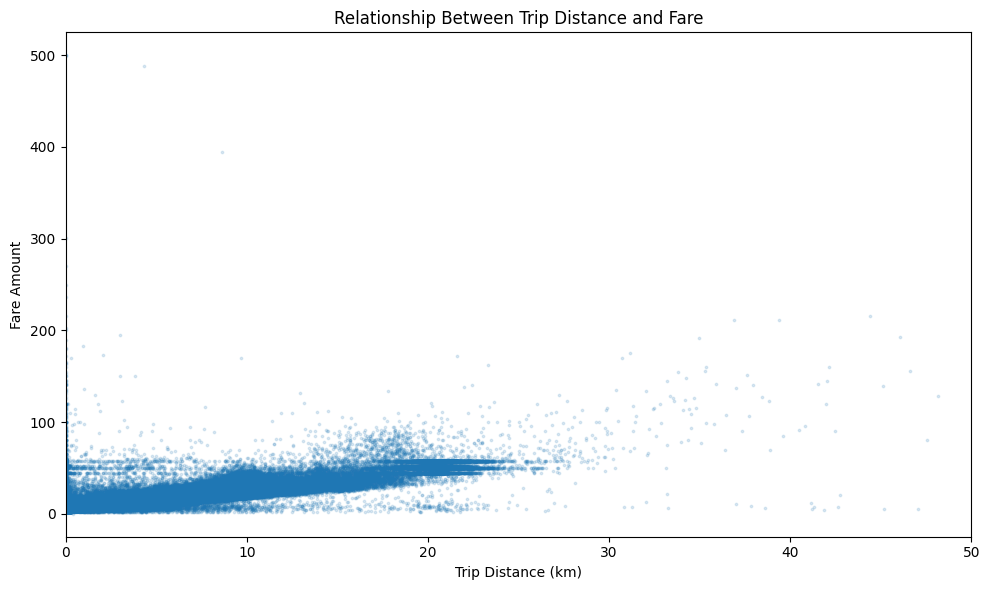

In [109]:
# 5.3.5 Distance versus fare relationship

plt.figure(figsize=(10, 6))

plt.scatter(
    feature_sample["distance_km"],
    feature_sample["fare_amount"],
    s=3,
    alpha=0.15
)

plt.xlabel("Trip Distance (km)")
plt.ylabel("Fare Amount")
plt.title("Relationship Between Trip Distance and Fare")

plt.xlim(0, 50)

plt.tight_layout()
plt.show()

In [110]:
# Correlation between trip distance and fare

distance_fare_correlation = feature_sample[
    ["distance_km", "fare_amount"]
].corr().loc["distance_km", "fare_amount"]

print(
    "Correlation between distance and fare:",
    round(distance_fare_correlation, 4)
)

Correlation between distance and fare: 0.8136


In [111]:
# 5.4.1 Fare descriptive statistics

fare_summary = pd.Series({
    "Count": feature_sample["fare_amount"].count(),
    "Mean": feature_sample["fare_amount"].mean(),
    "Median": feature_sample["fare_amount"].median(),
    "Std Dev": feature_sample["fare_amount"].std(),
    "Minimum": feature_sample["fare_amount"].min(),
    "25th Percentile": feature_sample["fare_amount"].quantile(0.25),
    "75th Percentile": feature_sample["fare_amount"].quantile(0.75),
    "Maximum": feature_sample["fare_amount"].max(),
})

display(fare_summary.to_frame("Value"))

,Value
Count,489708.000000
Mean,11.339789
Median,8.500000
Std Dev,9.806778
Minimum,0.050000
25th Percentile,6.000000
75th Percentile,12.500000
Maximum,500.000000


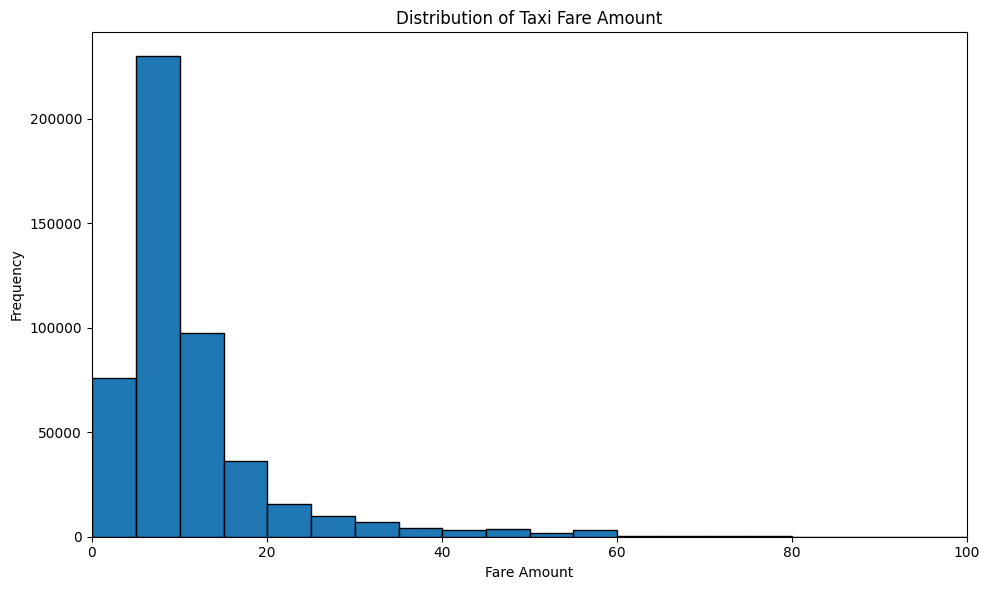

In [112]:
# 5.4.2 Fare distribution

plt.figure(figsize=(10, 6))

plt.hist(
    feature_sample["fare_amount"],
    bins=100,
    edgecolor="black"
)

plt.xlabel("Fare Amount")
plt.ylabel("Frequency")
plt.title("Distribution of Taxi Fare Amount")

plt.xlim(0, 100)

plt.tight_layout()
plt.show()

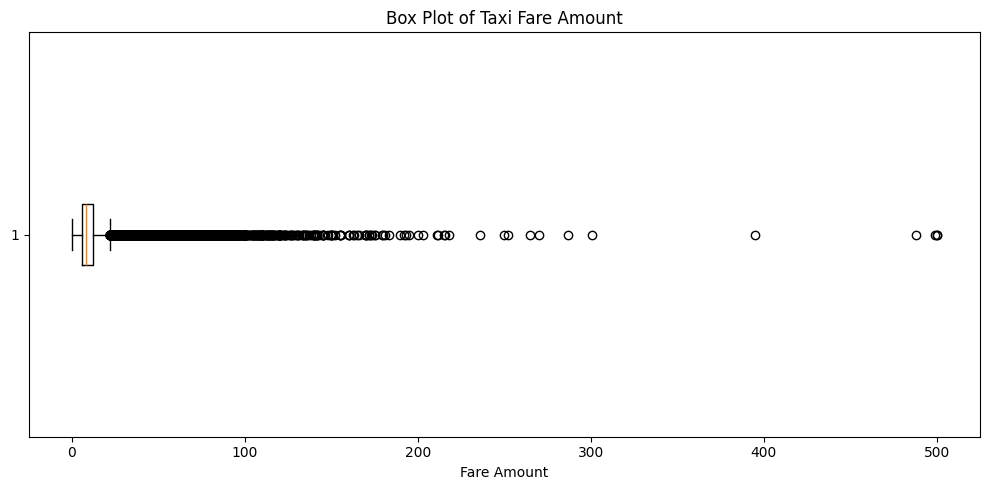

In [113]:
# 5.4.3 Fare box plot

plt.figure(figsize=(10, 5))

plt.boxplot(
    feature_sample["fare_amount"],
    vert=False
)

plt.xlabel("Fare Amount")
plt.title("Box Plot of Taxi Fare Amount")

plt.tight_layout()
plt.show()

In [114]:
# 5.4.4 Quantify high-fare observations

fare_thresholds = pd.Series({
    "Fare > $25": (feature_sample["fare_amount"] > 25).sum(),
    "Fare > $50": (feature_sample["fare_amount"] > 50).sum(),
    "Fare > $100": (feature_sample["fare_amount"] > 100).sum(),
    "Fare > $200": (feature_sample["fare_amount"] > 200).sum(),
})

display(fare_thresholds.to_frame("Number of Records"))

,Number of Records
Fare > $25,34570
Fare > $50,6203
Fare > $100,186
Fare > $200,18


### Section 6 — Feature Selection and Preparation

In [115]:
# 6.1 Candidate modeling features

candidate_features = [
    "pickup_longitude",
    "pickup_latitude",
    "dropoff_longitude",
    "dropoff_latitude",
    "passenger_count",
    "distance_km",
    "year",
    "month",
    "day",
    "hour",
    "day_of_week"
]

target_column = "fare_amount"

print("Candidate features:")
for feature in candidate_features:
    print("-", feature)

print("\nTarget:", target_column)

print("\nFeature matrix shape:")
print(feature_sample[candidate_features].shape)

print("\nTarget shape:")
print(feature_sample[target_column].shape)

Candidate features:
- pickup_longitude
- pickup_latitude
- dropoff_longitude
- dropoff_latitude
- passenger_count
- distance_km
- year
- month
- day
- hour
- day_of_week

Target: fare_amount

Feature matrix shape:
(489708, 11)

Target shape:
(489708,)


In [116]:
# 6.2 Correlation analysis of numerical modeling features

correlation_features = candidate_features + [target_column]

correlation_matrix = feature_sample[
    correlation_features
].corr()

display(correlation_matrix)

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km,year,month,day,hour,day_of_week,fare_amount
pickup_longitude,1.000000,0.138837,0.408026,0.153750,-0.000762,0.408750,0.001212,0.007010,0.001374,0.019305,-0.018165,0.369170
pickup_latitude,0.138837,1.000000,0.170627,0.484092,-0.008940,-0.169063,-0.019703,-0.001878,-0.002476,0.027630,-0.037016,-0.181756
dropoff_longitude,0.408026,0.170627,1.000000,0.241817,-0.002677,0.327564,-0.002975,0.004776,0.001521,-0.038180,0.000107,0.276614
dropoff_latitude,0.153750,0.484092,0.241817,1.000000,-0.006523,-0.121381,-0.013273,-0.000713,-0.002476,0.020447,-0.024716,-0.149648
passenger_count,-0.000762,-0.008940,-0.002677,-0.006523,1.000000,0.011081,0.002393,0.004373,0.005104,0.016074,0.034669,0.014878
distance_km,0.408750,-0.169063,0.327564,-0.121381,0.011081,1.000000,0.020376,0.010699,0.002264,-0.025957,0.017205,0.813556
year,0.001212,-0.019703,-0.002975,-0.013273,0.002393,0.020376,1.000000,-0.118449,-0.009270,-0.001381,0.006646,0.115186
month,0.007010,-0.001878,0.004776,-0.000713,0.004373,0.010699,-0.118449,1.000000,-0.013235,-0.005183,-0.007213,0.023677
day,0.001374,-0.002476,0.001521,-0.002476,0.005104,0.002264,-0.009270,-0.013235,1.000000,0.003444,0.008416,0.002045
hour,0.019305,0.027630,-0.038180,0.020447,0.016074,-0.025957,-0.001381,-0.005183,0.003444,1.000000,-0.087733,-0.016019


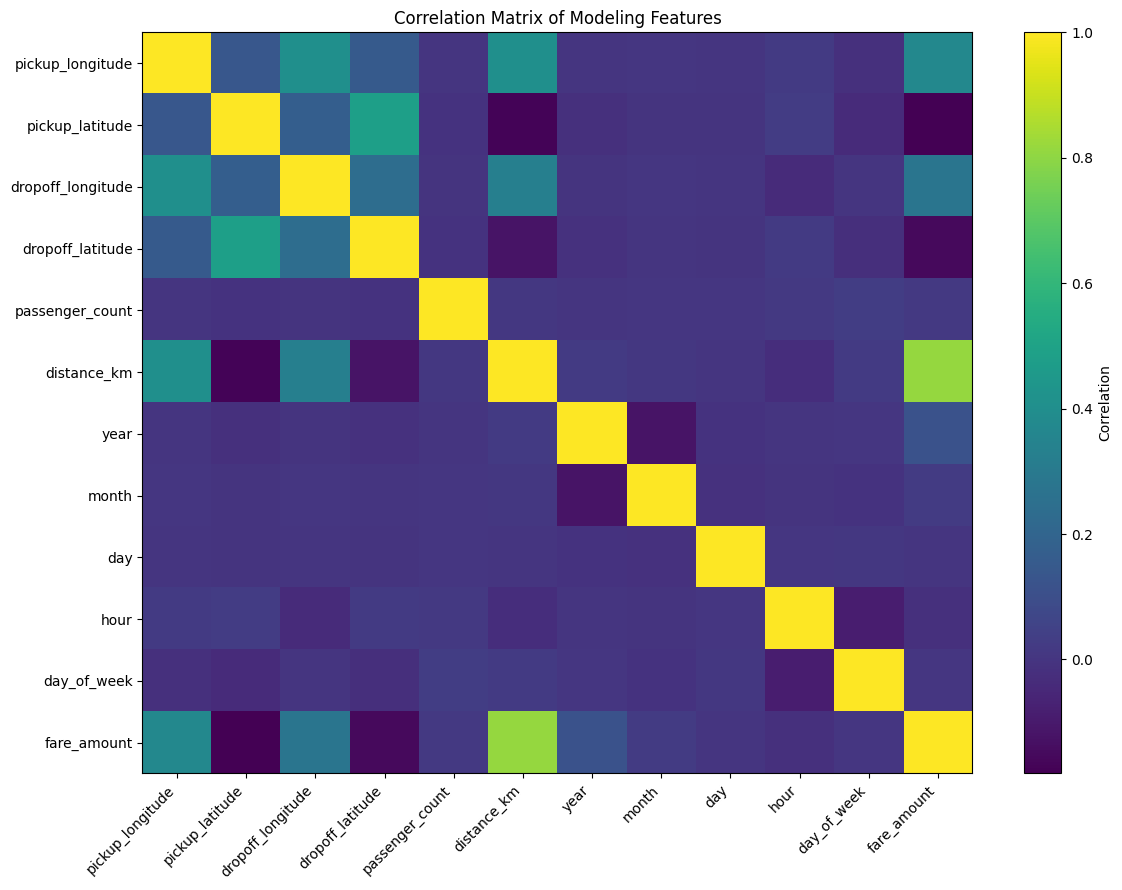

In [117]:
# Correlation heatmap

plt.figure(figsize=(12, 9))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix.index)),
    correlation_matrix.index
)

plt.title("Correlation Matrix of Modeling Features")

plt.tight_layout()
plt.show()

In [118]:
# 6.3.1 Create final feature matrix and target vector

X = feature_sample[candidate_features].copy()
y = feature_sample[target_column].copy()

print("Feature matrix X shape:", X.shape)
print("Target vector y shape:", y.shape)

print("\nFeature columns:")
print(X.columns.tolist())

print("\nMissing values in X:")
print(X.isna().sum())

print("\nMissing values in y:")
print(y.isna().sum())

Feature matrix X shape: (489708, 11)
Target vector y shape: (489708,)

Feature columns:
['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'passenger_count', 'distance_km', 'year', 'month', 'day', 'hour', 'day_of_week']

Missing values in X:
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
passenger_count      0
distance_km          0
year                 0
month                0
day                  0
hour                 0
day_of_week          0
dtype: int64

Missing values in y:
0


In [119]:
# 6.3.2 Verify modeling feature data types

print("Feature data types:")
display(X.dtypes.to_frame("Data Type"))

print("\nTarget data type:")
print(y.dtype)

Feature data types:


,Data Type
pickup_longitude,float64
pickup_latitude,float64
dropoff_longitude,float64
dropoff_latitude,float64
passenger_count,int64
distance_km,float64
year,int32
month,int32
day,int32
hour,int32



Target data type:
float64


In [120]:
# 6.3.3 Final feature statistics before scaling

display(X.describe().T)

,count,mean,std,min,25%,50%,75%,max
pickup_longitude,489708.0,-73.975239,0.038614,-74.837878,-73.992285,-73.982093,-73.968308,-73.137393
pickup_latitude,489708.0,40.751046,0.029760,40.042858,40.736525,40.753388,40.767543,41.509627
dropoff_longitude,489708.0,-73.974323,0.038081,-74.953563,-73.991585,-73.980602,-73.965313,-73.050207
dropoff_latitude,489708.0,40.751389,0.033198,40.037622,40.735598,40.753865,40.768380,41.704954
passenger_count,489708.0,1.689795,1.305312,1.000000,1.000000,1.000000,2.000000,6.000000
distance_km,489708.0,3.328950,3.746220,0.000000,1.252657,2.153759,3.916370,103.310959
year,489708.0,2011.738532,1.862535,2009.000000,2010.000000,2012.000000,2013.000000,2015.000000
month,489708.0,6.263002,3.431453,1.000000,3.000000,6.000000,9.000000,12.000000
day,489708.0,15.708195,8.691768,1.000000,8.000000,16.000000,23.000000,31.000000
hour,489708.0,13.513369,6.506503,0.000000,9.000000,14.000000,19.000000,23.000000


In [121]:
# 7.1 Train / Validation / Test Split

from sklearn.model_selection import train_test_split

# First split: 70% training, 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

# Second split: divide temporary set equally
# 15% validation and 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

print("Training set:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nValidation set:")
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("\nTest set:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("\nTotal records:", len(X_train) + len(X_val) + len(X_test))

Training set:
X_train: (342795, 11)
y_train: (342795,)

Validation set:
X_val: (73456, 11)
y_val: (73456,)

Test set:
X_test: (73457, 11)
y_test: (73457,)

Total records: 489708


In [122]:
# 7.2 Feature Scaling

from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform validation and test using the same fitted scaler
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled validation shape:", X_val_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

print("\nTraining scaled mean:")
print(np.round(X_train_scaled.mean(axis=0), 4))

print("\nTraining scaled standard deviation:")
print(np.round(X_train_scaled.std(axis=0), 4))

Scaled training shape: (342795, 11)
Scaled validation shape: (73456, 11)
Scaled test shape: (73457, 11)

Training scaled mean:
[-0. -0.  0.  0. -0.  0.  0. -0.  0. -0.  0.]

Training scaled standard deviation:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [123]:
# 8.1 Baseline Model - Linear Regression

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create baseline model
baseline_model = LinearRegression()

# Train baseline
baseline_model.fit(X_train_scaled, y_train)

# Predictions
y_val_pred_baseline = baseline_model.predict(X_val_scaled)

# Evaluation
baseline_mae = mean_absolute_error(y_val, y_val_pred_baseline)
baseline_rmse = np.sqrt(
    mean_squared_error(y_val, y_val_pred_baseline)
)
baseline_r2 = r2_score(y_val, y_val_pred_baseline)

print("Baseline Linear Regression Results")
print("----------------------------------")
print(f"MAE  : {baseline_mae:.4f}")
print(f"RMSE : {baseline_rmse:.4f}")
print(f"R²   : {baseline_r2:.4f}")

Baseline Linear Regression Results
----------------------------------
MAE  : 2.4256
RMSE : 5.1459
R²   : 0.7219


## 8.2 Deep Feedforward Neural Network Architecture

A Deep Feedforward Neural Network (DNN) is developed for taxi fare regression.

The network uses:
- 11 input features
- Multiple fully connected hidden layers
- ReLU activation functions in the hidden layers
- A single linear output neuron for continuous fare prediction

The initial architecture is intentionally kept moderate to provide a baseline neural-network model before hyperparameter tuning.

In [124]:
# 8.2 Build the Initial DNN Model

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Number of input features
input_features = X_train_scaled.shape[1]

# Build DNN
dnn_model = keras.Sequential([
    layers.Input(shape=(input_features,)),
    
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    
    layers.Dense(1, activation="linear")
])

# Display architecture
dnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,905 (46.50 KB)

 Trainable params: 11,905 (46.50 KB)

 Non-trainable params: 0 (0.00 B)

In [125]:
# 8.3 Compile the DNN

dnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=[
        keras.metrics.MeanAbsoluteError(name="mae"),
        keras.metrics.RootMeanSquaredError(name="rmse")
    ]
)

print("DNN compiled successfully.")
print("Optimizer: Adam")
print("Learning rate: 0.001")
print("Loss function: Mean Squared Error (MSE)")
print("Metrics: MAE, RMSE")

DNN compiled successfully.
Optimizer: Adam
Learning rate: 0.001
Loss function: Mean Squared Error (MSE)
Metrics: MAE, RMSE


In [126]:
# 8.4 Train the Initial DNN

EPOCHS = 30
BATCH_SIZE = 1024

history = dnn_model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

print("\nDNN training completed.")

Epoch 1/30
335/335 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 48.9174 - mae: 3.5999 - rmse: 6.9941 - val_loss: 23.2321 - val_mae: 2.3977 - val_rmse: 4.8200
Epoch 2/30
335/335 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 25.4934 - mae: 2.2697 - rmse: 5.0491 - val_loss: 19.7138 - val_mae: 2.1108 - val_rmse: 4.4400
Epoch 3/30
335/335 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 22.7247 - mae: 2.1186 - rmse: 4.7670 - val_loss: 18.9118 - val_mae: 2.0398 - val_rmse: 4.3488
Epoch 4/30
335/335 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 21.9903 - mae: 2.0725 - rmse: 4.6894 - val_loss: 18.5216 - val_mae: 2.0064 - val_rmse: 4.3037
Epoch 5/30
335/335 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 21.5695 - mae: 2.0488 - rmse: 4.6443 - val_loss: 18.2571 - val_mae: 1.9806 - val_rmse: 4.2728
Epoch 6/30
335/335 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 21.2267 - mae: 2.0299 - rmse: 4.6072 - val_loss: 18.0280 - val_mae: 1.9695 - val_rmse: 4.2459
Epoch 7/30
335/335 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 20.9191 - mae: 2

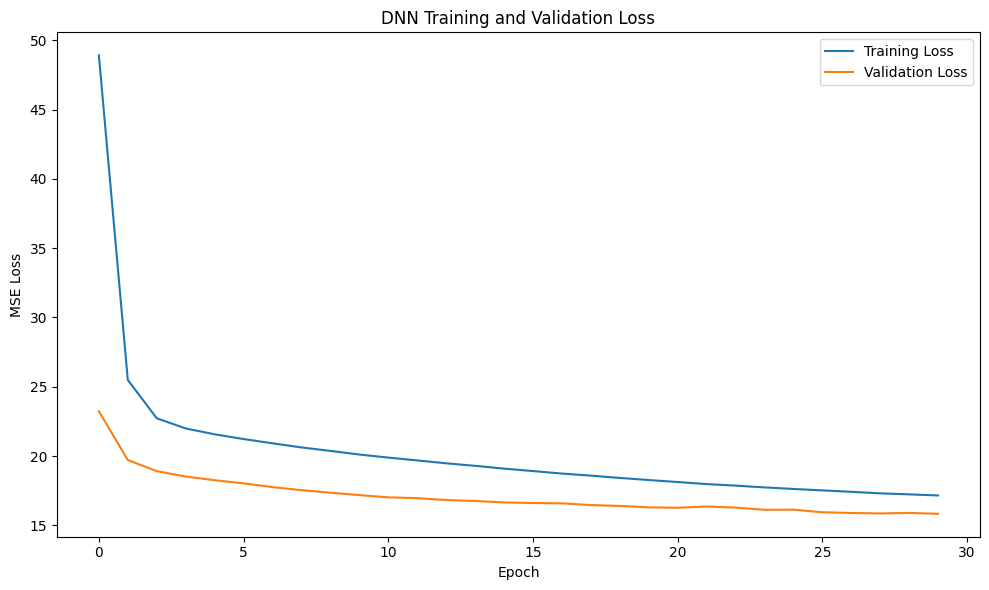

In [127]:
# 8.5 Training and Validation Loss

plt.figure(figsize=(10, 6))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("DNN Training and Validation Loss")

plt.legend()
plt.tight_layout()
plt.show()

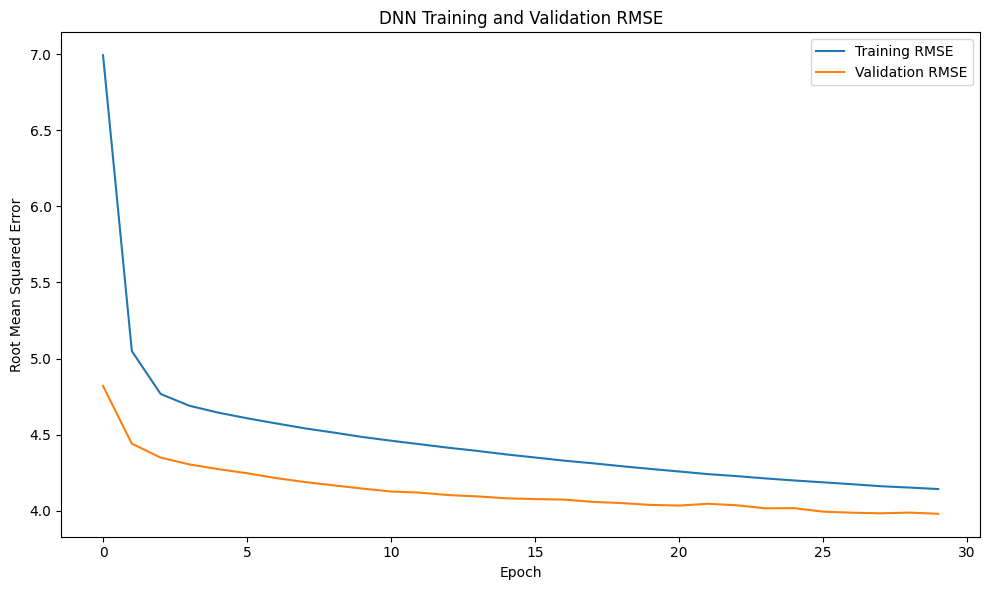

In [128]:
# 8.5.2 Training and Validation RMSE

plt.figure(figsize=(10, 6))

plt.plot(
    history.history["rmse"],
    label="Training RMSE"
)

plt.plot(
    history.history["val_rmse"],
    label="Validation RMSE"
)

plt.xlabel("Epoch")
plt.ylabel("Root Mean Squared Error")
plt.title("DNN Training and Validation RMSE")

plt.legend()
plt.tight_layout()
plt.show()

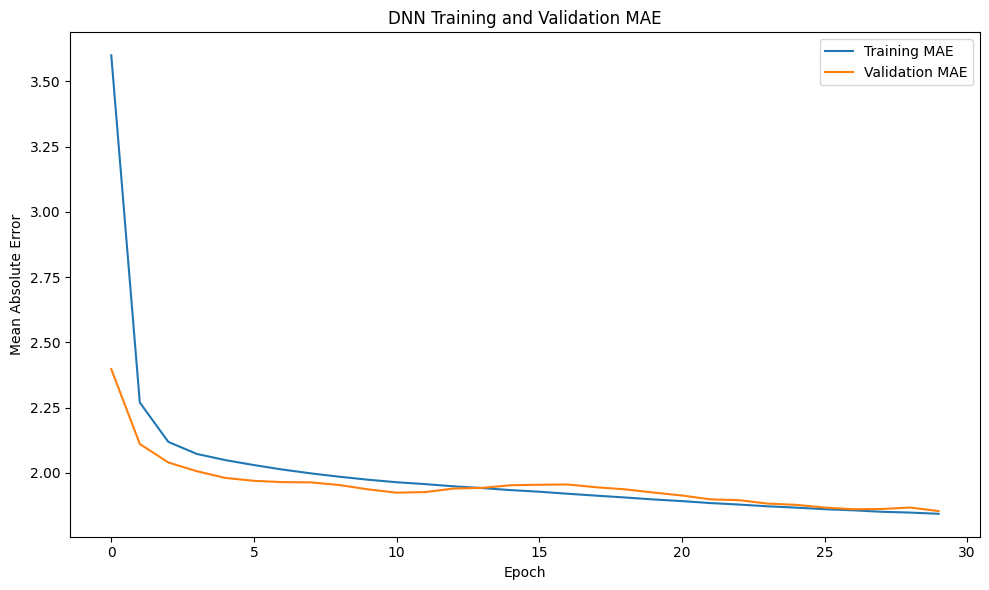

In [129]:
# 8.5.1 Training and Validation MAE

plt.figure(figsize=(10, 6))

plt.plot(
    history.history["mae"],
    label="Training MAE"
)

plt.plot(
    history.history["val_mae"],
    label="Validation MAE"
)

plt.xlabel("Epoch")
plt.ylabel("Mean Absolute Error")
plt.title("DNN Training and Validation MAE")

plt.legend()
plt.tight_layout()
plt.show()

In [130]:
# 8.6 DNN Validation Evaluation

# Generate predictions on validation data
y_val_pred_dnn = dnn_model.predict(
    X_val_scaled,
    verbose=0
).ravel()

# Calculate evaluation metrics
dnn_val_mae = mean_absolute_error(
    y_val,
    y_val_pred_dnn
)

dnn_val_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        y_val_pred_dnn
    )
)

dnn_val_r2 = r2_score(
    y_val,
    y_val_pred_dnn
)

print("Initial DNN Validation Results")
print("--------------------------------")
print(f"MAE  : {dnn_val_mae:.4f}")
print(f"RMSE : {dnn_val_rmse:.4f}")
print(f"R²   : {dnn_val_r2:.4f}")

Initial DNN Validation Results
--------------------------------
MAE  : 1.8537
RMSE : 3.9791
R²   : 0.8337


In [131]:
# 8.6.1 Baseline vs DNN Comparison

model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Initial DNN"
    ],
    "MAE": [
        baseline_mae,
        dnn_val_mae
    ],
    "RMSE": [
        baseline_rmse,
        dnn_val_rmse
    ],
    "R2": [
        baseline_r2,
        dnn_val_r2
    ]
})

display(
    model_comparison.style.format({
        "MAE": "{:.4f}",
        "RMSE": "{:.4f}",
        "R2": "{:.4f}"
    })
)

,Model,MAE,RMSE,R2
0,Linear Regression,2.4256,5.1459,0.7219
1,Initial DNN,1.8537,3.9791,0.8337


## 9. Loss Function Comparison

Three regression loss functions are evaluated using the same DNN architecture:

1. Mean Squared Error (MSE)
2. Mean Absolute Error (MAE)
3. Huber Loss

The architecture, optimizer, learning rate, batch size, number of epochs, training data, validation data, and preprocessing are kept constant. This allows the effect of the loss function on regression performance to be compared consistently.

In [132]:
# 9.1 Loss Function Experiment Configuration

LOSS_EPOCHS = 30
LOSS_BATCH_SIZE = 1024
LOSS_LEARNING_RATE = 0.001

print("Loss-function experiment configuration")
print("---------------------------------------")
print("Epochs:", LOSS_EPOCHS)
print("Batch size:", LOSS_BATCH_SIZE)
print("Learning rate:", LOSS_LEARNING_RATE)
print("Architecture: 128 -> 64 -> 32 -> 1")

Loss-function experiment configuration
---------------------------------------
Epochs: 30
Batch size: 1024
Learning rate: 0.001
Architecture: 128 -> 64 -> 32 -> 1


In [133]:
# 9.2 Build and Train Loss-Function Models

def build_dnn(loss_function):
    model = keras.Sequential([
        layers.Input(shape=(input_features,)),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(1, activation="linear")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=LOSS_LEARNING_RATE
        ),
        loss=loss_function,
        metrics=[
            keras.metrics.MeanAbsoluteError(name="mae"),
            keras.metrics.RootMeanSquaredError(name="rmse")
        ]
    )

    return model


# -----------------------------
# MSE Model
# -----------------------------
mse_model = build_dnn("mse")

mse_history = mse_model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=LOSS_EPOCHS,
    batch_size=LOSS_BATCH_SIZE,
    verbose=1
)


# -----------------------------
# MAE Model
# -----------------------------
mae_model = build_dnn("mae")

mae_history = mae_model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=LOSS_EPOCHS,
    batch_size=LOSS_BATCH_SIZE,
    verbose=1
)


# -----------------------------
# Huber Loss Model
# -----------------------------
huber_model = build_dnn(
    keras.losses.Huber()
)

huber_history = huber_model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=LOSS_EPOCHS,
    batch_size=LOSS_BATCH_SIZE,
    verbose=1
)

print("All three loss-function experiments completed.")

Epoch 1/30
335/335 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 50.0674 - mae: 3.6638 - rmse: 7.0758 - val_loss: 23.2911 - val_mae: 2.4032 - val_rmse: 4.8261
Epoch 2/30
335/335 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 25.5149 - mae: 2.2742 - rmse: 5.0512 - val_loss: 19.8291 - val_mae: 2.1237 - val_rmse: 4.4530
Epoch 3/30
335/335 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 22.6708 - mae: 2.1209 - rmse: 4.7614 - val_loss: 18.9075 - val_mae: 2.0617 - val_rmse: 4.3483
Epoch 4/30
335/335 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 21.7912 - mae: 2.0687 - rmse: 4.6681 - val_loss: 18.3679 - val_mae: 2.0200 - val_rmse: 4.2858
Epoch 5/30
335/335 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 21.3193 - mae: 2.0382 - rmse: 4.6173 - val_loss: 18.0059 - val_mae: 1.9976 - val_rmse: 4.2433
Epoch 6/30
335/335 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 20.9452 - mae: 2.0155 - rmse: 4.5766 - val_loss: 17.7098 - val_mae: 1.9875 - val_rmse: 4.2083
Epoch 7/30
335/335 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 20.6095 - mae: 1

In [134]:
# 9.3 Evaluate Loss-Function Models

# Generate validation predictions
y_val_pred_mse = mse_model.predict(
    X_val_scaled,
    verbose=0
).ravel()

y_val_pred_mae = mae_model.predict(
    X_val_scaled,
    verbose=0
).ravel()

y_val_pred_huber = huber_model.predict(
    X_val_scaled,
    verbose=0
).ravel()


# Evaluation function
def evaluate_regression_model(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }


# Evaluate all three
loss_results = pd.DataFrame([
    evaluate_regression_model(
        "DNN - MSE",
        y_val,
        y_val_pred_mse
    ),
    evaluate_regression_model(
        "DNN - MAE",
        y_val,
        y_val_pred_mae
    ),
    evaluate_regression_model(
        "DNN - Huber",
        y_val,
        y_val_pred_huber
    )
])

display(
    loss_results.style.format({
        "MAE": "{:.4f}",
        "RMSE": "{:.4f}",
        "R2": "{:.4f}"
    })
)

,Model,MAE,RMSE,R2
0,DNN - MSE,1.8227,3.8551,0.8439
1,DNN - MAE,1.6228,4.2061,0.8142
2,DNN - Huber,1.6327,4.1713,0.8173


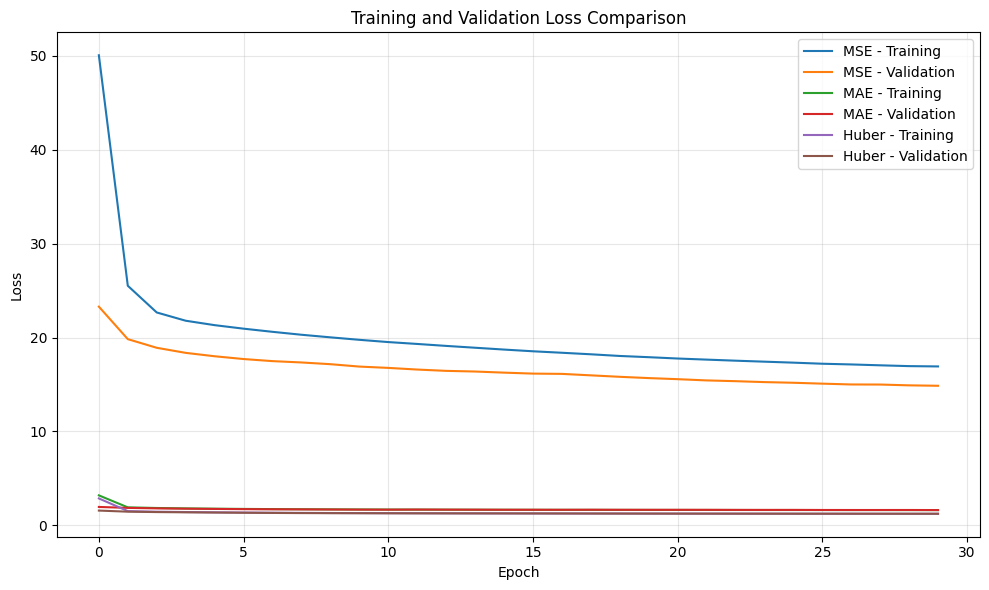

In [135]:
# 9.4 Compare Training and Validation Loss Curves

plt.figure(figsize=(10, 6))

plt.plot(
    mse_history.history["loss"],
    label="MSE - Training"
)
plt.plot(
    mse_history.history["val_loss"],
    label="MSE - Validation"
)

plt.plot(
    mae_history.history["loss"],
    label="MAE - Training"
)
plt.plot(
    mae_history.history["val_loss"],
    label="MAE - Validation"
)

plt.plot(
    huber_history.history["loss"],
    label="Huber - Training"
)
plt.plot(
    huber_history.history["val_loss"],
    label="Huber - Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

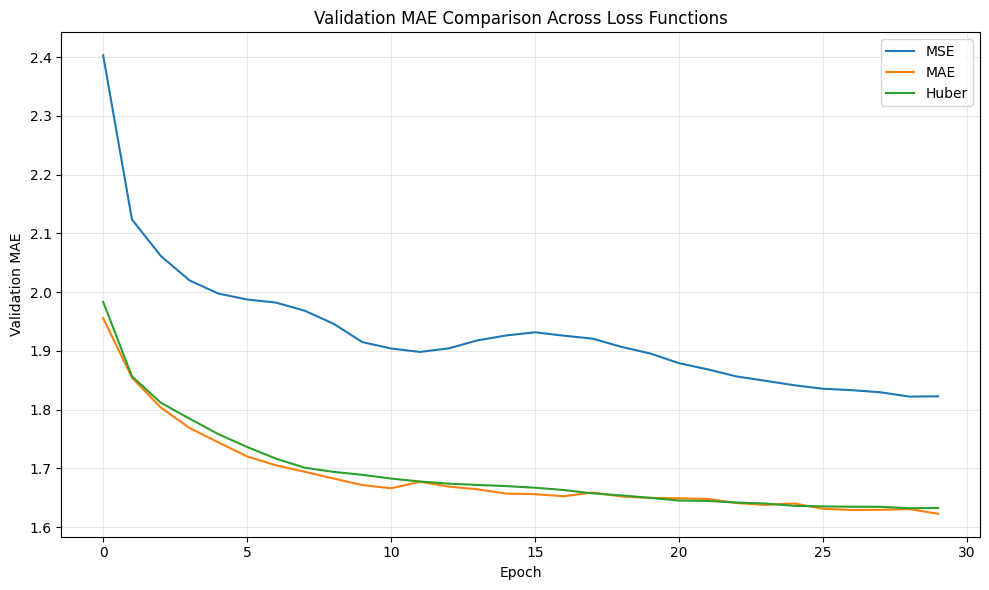

In [136]:
# 9.5 Compare Validation MAE Across Loss Functions

plt.figure(figsize=(10, 6))

plt.plot(
    mse_history.history["val_mae"],
    label="MSE"
)
plt.plot(
    mae_history.history["val_mae"],
    label="MAE"
)
plt.plot(
    huber_history.history["val_mae"],
    label="Huber"
)

plt.xlabel("Epoch")
plt.ylabel("Validation MAE")
plt.title("Validation MAE Comparison Across Loss Functions")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 9.6 Loss-Function Comparison – Interpretation

The loss-function experiments show that all three DNN configurations learn effectively, with rapid improvement during the initial epochs followed by gradual convergence.

The MSE-trained model achieves the lowest RMSE (3.8551) and highest R² (0.8439), whereas the MAE-trained model achieves the lowest MAE (1.6228). The Huber-loss model produces intermediate results.

The validation MAE curves show consistent improvement across training. The MAE and Huber models converge to very similar validation MAE values, while the MSE model remains higher in terms of MAE.

The training and validation curves remain relatively close throughout training, suggesting that there is no strong evidence of severe overfitting in these experiments. Since MSE, MAE, and Huber have different numerical scales, their raw loss values should not be compared directly; MAE, RMSE, and R² are used for cross-model evaluation.

# 10. Hyperparameter Tuning

The initial DNN provides a baseline for neural-network performance. Hyperparameter tuning is performed to investigate whether the architecture, learning rate, batch size, and training duration can improve validation performance.

The tuning experiments are performed using the training and validation sets defined earlier. The test set remains untouched until final evaluation.

In [137]:
# 10.1 Define Hyperparameter Search Space

hyperparameter_configs = [
    {
        "name": "Baseline",
        "hidden_layers": [128, 64, 32],
        "learning_rate": 0.001,
        "batch_size": 1024,
        "epochs": 30
    },
    {
        "name": "Higher Learning Rate",
        "hidden_layers": [128, 64, 32],
        "learning_rate": 0.003,
        "batch_size": 1024,
        "epochs": 30
    },
    {
        "name": "Lower Learning Rate",
        "hidden_layers": [128, 64, 32],
        "learning_rate": 0.0003,
        "batch_size": 1024,
        "epochs": 30
    },
    {
        "name": "Smaller Batch",
        "hidden_layers": [128, 64, 32],
        "learning_rate": 0.001,
        "batch_size": 512,
        "epochs": 30
    },
    {
        "name": "Larger Network",
        "hidden_layers": [256, 128, 64],
        "learning_rate": 0.001,
        "batch_size": 1024,
        "epochs": 30
    }
]

print("Number of configurations:", len(hyperparameter_configs))

for config in hyperparameter_configs:
    print(config)

Number of configurations: 5
{'name': 'Baseline', 'hidden_layers': [128, 64, 32], 'learning_rate': 0.001, 'batch_size': 1024, 'epochs': 30}
{'name': 'Higher Learning Rate', 'hidden_layers': [128, 64, 32], 'learning_rate': 0.003, 'batch_size': 1024, 'epochs': 30}
{'name': 'Lower Learning Rate', 'hidden_layers': [128, 64, 32], 'learning_rate': 0.0003, 'batch_size': 1024, 'epochs': 30}
{'name': 'Smaller Batch', 'hidden_layers': [128, 64, 32], 'learning_rate': 0.001, 'batch_size': 512, 'epochs': 30}
{'name': 'Larger Network', 'hidden_layers': [256, 128, 64], 'learning_rate': 0.001, 'batch_size': 1024, 'epochs': 30}


In [138]:
# 10.2 Run Hyperparameter Experiments

import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import time

tuning_results = []
tuning_histories = {}

for config in hyperparameter_configs:

    print("\n" + "=" * 60)
    print(f"Running configuration: {config['name']}")
    print("=" * 60)

    # Reproducibility
    np.random.seed(42)
    tf.random.set_seed(42)

    # Build model
    model = keras.Sequential()

    # Input layer
    model.add(
        keras.layers.Input(shape=(X_train_scaled.shape[1],))
    )

    # Hidden layers
    for units in config["hidden_layers"]:
        model.add(
            keras.layers.Dense(
                units,
                activation="relu"
            )
        )

    # Output layer
    model.add(
        keras.layers.Dense(1, activation="linear")
    )

    # Compile
    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=config["learning_rate"]
        ),
        loss="mse",
        metrics=[
            keras.metrics.MeanAbsoluteError(name="mae"),
            keras.metrics.RootMeanSquaredError(name="rmse")
        ]
    )

    # Training
    start_time = time.time()

    history = model.fit(
        X_train_scaled,
        y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=config["epochs"],
        batch_size=config["batch_size"],
        verbose=0
    )

    training_time = time.time() - start_time

    # Validation prediction
    y_val_pred = model.predict(
        X_val_scaled,
        verbose=0
    ).ravel()

    # Validation metrics
    mae = mean_absolute_error(y_val, y_val_pred)

    rmse = np.sqrt(
        mean_squared_error(y_val, y_val_pred)
    )

    r2 = r2_score(y_val, y_val_pred)

    # Store results
    tuning_results.append({
        "Configuration": config["name"],
        "Hidden Layers": str(config["hidden_layers"]),
        "Learning Rate": config["learning_rate"],
        "Batch Size": config["batch_size"],
        "Epochs": config["epochs"],
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Training Time (s)": training_time
    })

    tuning_histories[config["name"]] = history.history

    print(f"MAE : {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²  : {r2:.4f}")
    print(f"Training time: {training_time:.2f} seconds")


# Convert results to DataFrame
tuning_results_df = pd.DataFrame(tuning_results)

print("\n" + "=" * 60)
print("Hyperparameter Tuning Results")
print("=" * 60)

display(
    tuning_results_df.sort_values(
        by="RMSE",
        ascending=True
    ).reset_index(drop=True)
)


Running configuration: Baseline
MAE : 1.8472
RMSE: 3.8719
R²  : 0.8426
Training time: 36.49 seconds

Running configuration: Higher Learning Rate
MAE : 1.7844
RMSE: 3.9855
R²  : 0.8332
Training time: 30.56 seconds

Running configuration: Lower Learning Rate
MAE : 1.9347
RMSE: 4.0400
R²  : 0.8286
Training time: 31.42 seconds

Running configuration: Smaller Batch
MAE : 1.8218
RMSE: 3.9957
R²  : 0.8323
Training time: 46.04 seconds

Running configuration: Larger Network
MAE : 1.7432
RMSE: 4.0256
R²  : 0.8298
Training time: 56.96 seconds

Hyperparameter Tuning Results


,Configuration,Hidden Layers,Learning Rate,Batch Size,Epochs,MAE,RMSE,R2,Training Time (s)
0,Baseline,"[128, 64, 32]",0.0010,1024,30,1.847202,3.871874,0.842564,36.491364
1,Higher Learning Rate,"[128, 64, 32]",0.0030,1024,30,1.784379,3.985457,0.833191,30.558463
2,Smaller Batch,"[128, 64, 32]",0.0010,512,30,1.821761,3.995665,0.832335,46.035195
3,Larger Network,"[256, 128, 64]",0.0010,1024,30,1.743190,4.025626,0.829812,56.962319
4,Lower Learning Rate,"[128, 64, 32]",0.0003,1024,30,1.934717,4.040009,0.828593,31.418741


### 10.3 Hyperparameter Tuning Comparison

The validation performance of the different hyperparameter configurations is compared using MAE, RMSE, and R². These metrics provide complementary views of prediction accuracy and should be interpreted together rather than relying on a single metric.

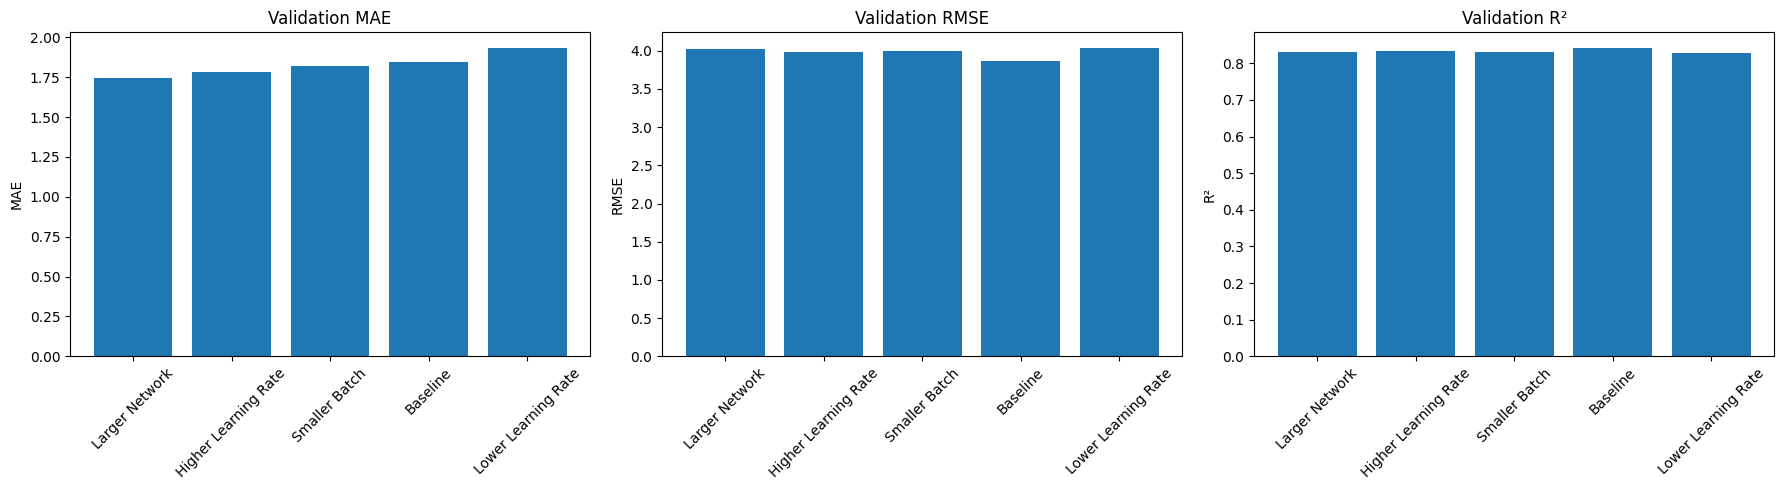

In [139]:
 # 10.3 Compare Hyperparameter Configurations

import matplotlib.pyplot as plt

# Sort configurations by MAE for visualization
plot_results = tuning_results_df.sort_values(
    by="MAE",
    ascending=True
).reset_index(drop=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# MAE
axes[0].bar(
    plot_results["Configuration"],
    plot_results["MAE"]
)
axes[0].set_title("Validation MAE")
axes[0].set_ylabel("MAE")
axes[0].tick_params(axis="x", rotation=45)

# RMSE
axes[1].bar(
    plot_results["Configuration"],
    plot_results["RMSE"]
)
axes[1].set_title("Validation RMSE")
axes[1].set_ylabel("RMSE")
axes[1].tick_params(axis="x", rotation=45)

# R²
axes[2].bar(
    plot_results["Configuration"],
    plot_results["R2"]
)
axes[2].set_title("Validation R²")
axes[2].set_ylabel("R²")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### 10.4 Hyperparameter Tuning Interpretation

The hyperparameter experiments demonstrate that model performance varies with the selected learning rate, batch size, and network architecture.

The Larger Network configuration achieves the lowest validation MAE of 1.7432, indicating lower average absolute prediction error. However, the Baseline configuration achieves the lowest validation RMSE of 3.8719 and the highest validation R² of 0.8426.

The Higher Learning Rate configuration achieves a validation MAE of 1.7844, while the Lower Learning Rate configuration produces a higher validation MAE of 1.9347 and RMSE of 4.0400.

The results indicate that no single configuration dominates every evaluation metric. Therefore, MAE, RMSE, and R² should be considered together when selecting the final model configuration. The validation results will be used to determine the configuration for final evaluation on the previously untouched test set.

In [140]:
# 11.1 Consolidated Validation Results

consolidated_results = pd.DataFrame([
    {
        "Model": "Linear Regression",
        "MAE": baseline_mae,
        "RMSE": baseline_rmse,
        "R2": baseline_r2
    },
    {
        "Model": "Initial DNN - MSE",
        "MAE": 1.8537,
        "RMSE": 3.9791,
        "R2": 0.8337
    },
    {
        "Model": "DNN - MSE",
        "MAE": 1.8227,
        "RMSE": 3.8551,
        "R2": 0.8439
    },
    {
        "Model": "DNN - MAE",
        "MAE": 1.6228,
        "RMSE": 4.2061,
        "R2": 0.8142
    },
    {
        "Model": "DNN - Huber",
        "MAE": 1.6327,
        "RMSE": 4.1713,
        "R2": 0.8173
    }
])

display(consolidated_results)

,Model,MAE,RMSE,R2
0,Linear Regression,2.42559,5.145863,0.721914
1,Initial DNN - MSE,1.85370,3.979100,0.833700
2,DNN - MSE,1.82270,3.855100,0.843900
3,DNN - MAE,1.62280,4.206100,0.814200
4,DNN - Huber,1.63270,4.171300,0.817300


# 11. Final Model Evaluation

The final DNN is constructed using the selected architecture and hyperparameters identified during validation experiments. The test set has not been used during model selection and is reserved for final performance evaluation.

In [141]:
# 11.1 Build Final DNN Model

np.random.seed(42)
tf.random.set_seed(42)

final_dnn = keras.Sequential([
    keras.layers.Input(shape=(X_train_scaled.shape[1],)),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dense(1, activation="linear")
])

final_dnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=[
        keras.metrics.MeanAbsoluteError(name="mae"),
        keras.metrics.RootMeanSquaredError(name="rmse")
    ]
)

final_dnn.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_36 (Dense)                │ (None, 128)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,905 (46.50 KB)

 Trainable params: 11,905 (46.50 KB)

 Non-trainable params: 0 (0.00 B)

In [142]:
# 11.2 Train Final DNN

final_history = final_dnn.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=30,
    batch_size=1024,
    verbose=1
)

print("Final DNN training completed.")

Epoch 1/30
335/335 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 49.2867 - mae: 3.6346 - rmse: 7.0204 - val_loss: 23.4457 - val_mae: 2.4568 - val_rmse: 4.8421
Epoch 2/30
335/335 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 25.7269 - mae: 2.3099 - rmse: 5.0722 - val_loss: 19.8024 - val_mae: 2.1380 - val_rmse: 4.4500
Epoch 3/30
335/335 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 22.6707 - mae: 2.1300 - rmse: 4.7614 - val_loss: 18.8011 - val_mae: 2.0460 - val_rmse: 4.3360
Epoch 4/30
335/335 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 21.8089 - mae: 2.0684 - rmse: 4.6700 - val_loss: 18.3450 - val_mae: 2.0166 - val_rmse: 4.2831
Epoch 5/30
335/335 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 21.3525 - mae: 2.0393 - rmse: 4.6209 - val_loss: 18.0582 - val_mae: 1.9994 - val_rmse: 4.2495
Epoch 6/30
335/335 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 21.0196 - mae: 2.0183 - rmse: 4.5847 - val_loss: 17.7598 - val_mae: 1.9808 - val_rmse: 4.2142
Epoch 7/30
335/335 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 20.7014 - mae: 1

In [143]:
# 11.3 Final Test-Set Evaluation

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Generate predictions on the untouched test set
y_test_pred = final_dnn.predict(
    X_test_scaled,
    verbose=0
).ravel()

# Calculate test metrics
final_test_mae = mean_absolute_error(
    y_test,
    y_test_pred
)

final_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_test_pred
    )
)

final_test_r2 = r2_score(
    y_test,
    y_test_pred
)

print("Final DNN Test-Set Results")
print("=" * 35)
print(f"MAE  : {final_test_mae:.4f}")
print(f"RMSE : {final_test_rmse:.4f}")
print(f"R²   : {final_test_r2:.4f}")

Final DNN Test-Set Results
MAE  : 1.8705
RMSE : 4.6504
R²   : 0.7804


### 11.4 Predicted vs Actual Fare

The predicted fare values are compared with the actual fare values from the held-out test set. A perfect regression model would place all observations along the 45-degree reference line. Deviations from this line represent prediction errors.

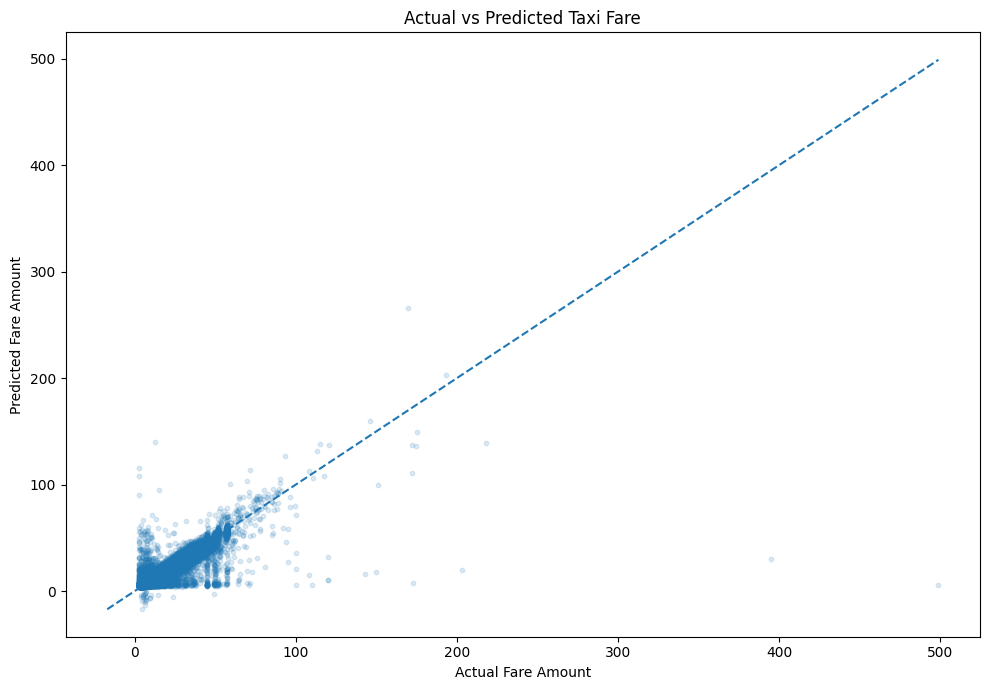

In [144]:
# 11.4 Predicted vs Actual Fare

plt.figure(figsize=(10, 7))

plt.scatter(
    y_test,
    y_test_pred,
    alpha=0.15,
    s=10
)

# 45-degree reference line
min_value = min(y_test.min(), y_test_pred.min())
max_value = max(y_test.max(), y_test_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Fare Amount")
plt.ylabel("Predicted Fare Amount")
plt.title("Actual vs Predicted Taxi Fare")

plt.tight_layout()
plt.show()

### 11.5 Residual Analysis

Residuals are calculated as the difference between the actual and predicted fare values. The residual distribution and residual-versus-predicted relationship are examined to identify systematic prediction errors, heteroscedasticity, and extreme observations.

In [145]:
# 11.5 Calculate Test-Set Residuals

residuals = y_test - y_test_pred

print("Residual Statistics")
print("=" * 35)
print(f"Mean residual   : {residuals.mean():.4f}")
print(f"Median residual : {np.median(residuals):.4f}")
print(f"Std residual    : {residuals.std():.4f}")
print(f"Minimum residual: {residuals.min():.4f}")
print(f"Maximum residual: {residuals.max():.4f}")

Residual Statistics
Mean residual   : -0.2532
Median residual : -0.5778
Std residual    : 4.6435
Minimum residual: -127.6483
Maximum residual: 493.2125


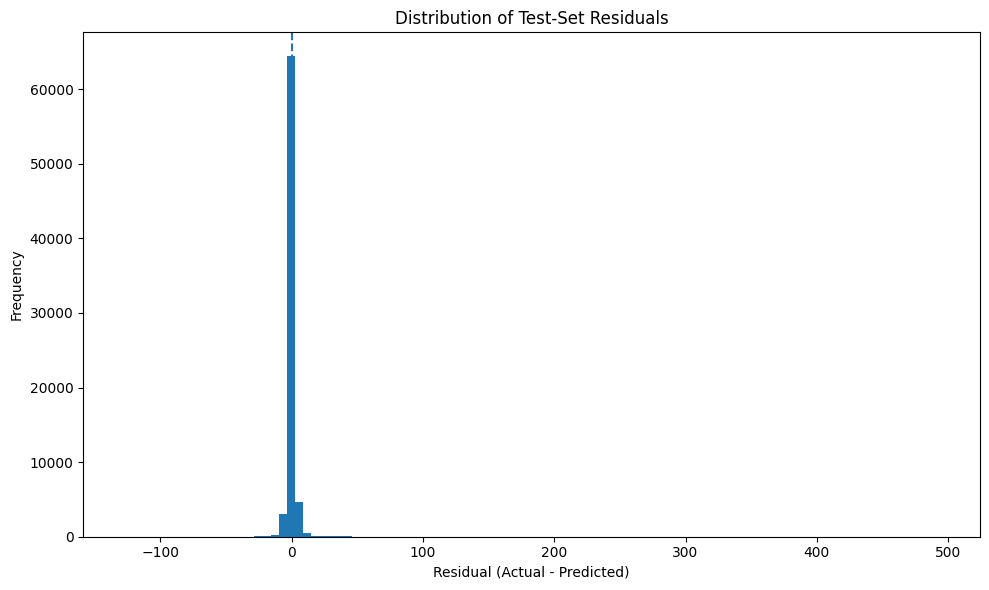

In [146]:
# 11.5.1 Residual Distribution

plt.figure(figsize=(10, 6))

plt.hist(
    residuals,
    bins=100
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")
plt.title("Distribution of Test-Set Residuals")

plt.tight_layout()
plt.show()

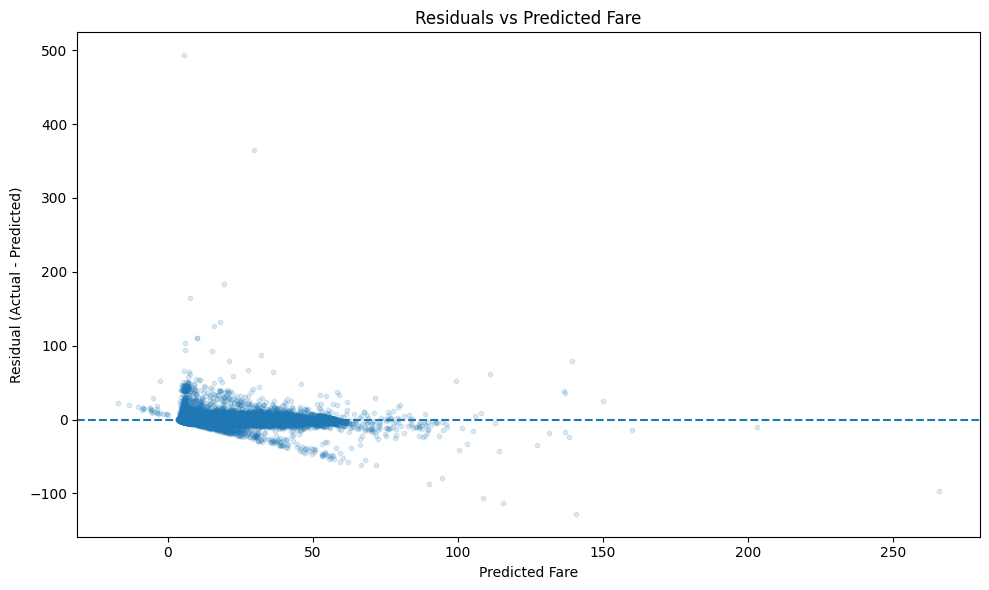

In [147]:
# 11.5.2 Residuals vs Predicted Fare

plt.figure(figsize=(10, 6))

plt.scatter(
    y_test_pred,
    residuals,
    alpha=0.15,
    s=10
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted Fare")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residuals vs Predicted Fare")

plt.tight_layout()
plt.show()

### 11.5.3 Residuals vs Predicted Fare Interpretation

The residual-versus-predicted plot shows that most prediction errors are concentrated around the zero-residual line. However, the spread of residuals increases for larger predicted fare values, indicating some degree of heteroscedasticity.

Several observations exhibit large positive or negative residuals, particularly at higher predicted fares. These observations indicate cases where the model substantially underestimates or overestimates the actual fare.

The residual pattern is therefore not completely random, suggesting that some variation in taxi fare is not fully captured by the current feature set and DNN architecture. The presence of large residuals also contributes to the difference between the MAE of 1.8705 and RMSE of 4.6504.

# 12. Final Model Comparison

The final model comparison summarizes the performance of the baseline Linear Regression model and the different DNN configurations evaluated during the experiments. MAE, RMSE, and R² are used as the primary evaluation metrics.

In [148]:
# 12.1 Final Model Comparison

final_comparison = pd.DataFrame([
    {
        "Model": "Linear Regression",
        "Dataset": "Validation",
        "MAE": baseline_mae,
        "RMSE": baseline_rmse,
        "R2": baseline_r2
    },
    {
        "Model": "Initial DNN - MSE",
        "Dataset": "Validation",
        "MAE": 1.8537,
        "RMSE": 3.9791,
        "R2": 0.8337
    },
    {
        "Model": "DNN - MSE",
        "Dataset": "Validation",
        "MAE": 1.8227,
        "RMSE": 3.8551,
        "R2": 0.8439
    },
    {
        "Model": "DNN - MAE",
        "Dataset": "Validation",
        "MAE": 1.6228,
        "RMSE": 4.2061,
        "R2": 0.8142
    },
    {
        "Model": "DNN - Huber",
        "Dataset": "Validation",
        "MAE": 1.6327,
        "RMSE": 4.1713,
        "R2": 0.8173
    },
    {
        "Model": "Final DNN",
        "Dataset": "Test",
        "MAE": final_test_mae,
        "RMSE": final_test_rmse,
        "R2": final_test_r2
    }
])

display(
    final_comparison.style.format({
        "MAE": "{:.4f}",
        "RMSE": "{:.4f}",
        "R2": "{:.4f}"
    })
)

,Model,Dataset,MAE,RMSE,R2
0,Linear Regression,Validation,2.4256,5.1459,0.7219
1,Initial DNN - MSE,Validation,1.8537,3.9791,0.8337
2,DNN - MSE,Validation,1.8227,3.8551,0.8439
3,DNN - MAE,Validation,1.6228,4.2061,0.8142
4,DNN - Huber,Validation,1.6327,4.1713,0.8173
5,Final DNN,Test,1.8705,4.6504,0.7804


### 12.2 Validation Model Comparison

The validation results are compared across the Linear Regression baseline and the DNN models trained using different loss functions.

MAE measures the average absolute prediction error, RMSE gives greater weight to large errors, and R² measures the proportion of target variance explained by the model.

The validation results are used for model comparison, while the test set is reserved for the final evaluation of the selected DNN model.

In [149]:
# 12.2 Validation Model Comparison

validation_comparison = final_comparison[
    final_comparison["Dataset"] == "Validation"
].copy()

display(
    validation_comparison.style.format({
        "MAE": "{:.4f}",
        "RMSE": "{:.4f}",
        "R2": "{:.4f}"
    })
)

,Model,Dataset,MAE,RMSE,R2
0,Linear Regression,Validation,2.4256,5.1459,0.7219
1,Initial DNN - MSE,Validation,1.8537,3.9791,0.8337
2,DNN - MSE,Validation,1.8227,3.8551,0.8439
3,DNN - MAE,Validation,1.6228,4.2061,0.8142
4,DNN - Huber,Validation,1.6327,4.1713,0.8173


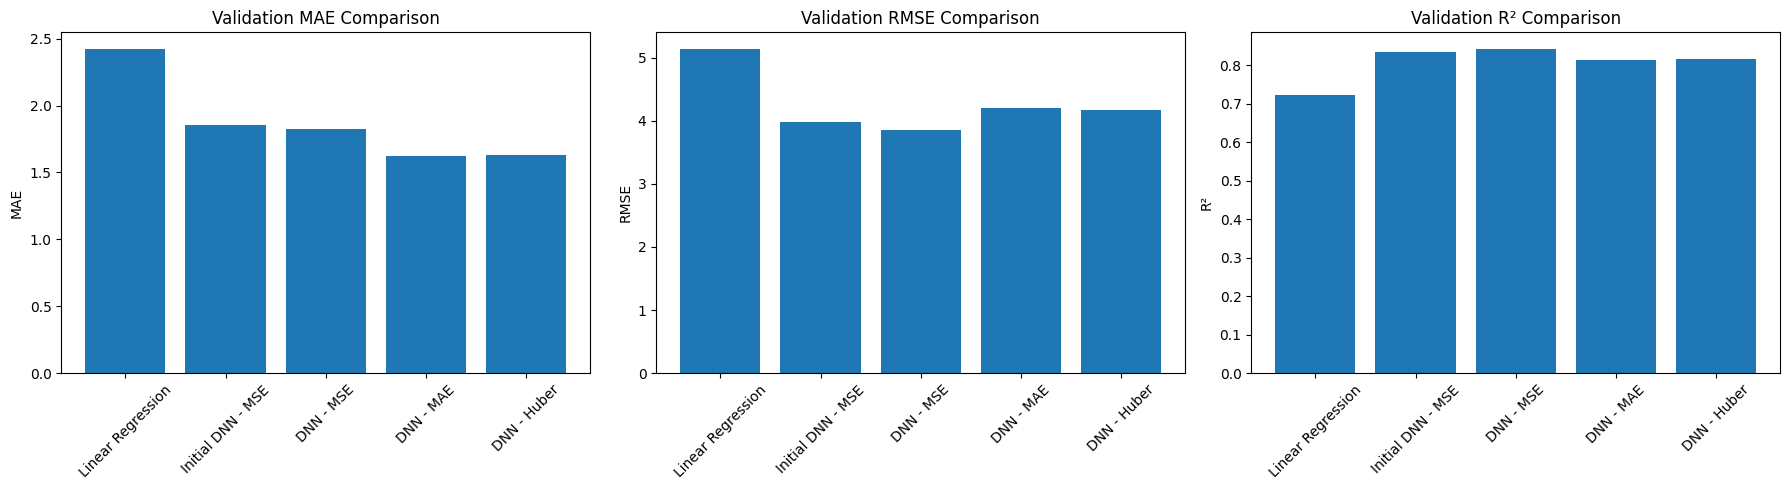

In [150]:
# 12.3 Validation Metrics Visualization

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# MAE
axes[0].bar(
    validation_comparison["Model"],
    validation_comparison["MAE"]
)
axes[0].set_title("Validation MAE Comparison")
axes[0].set_ylabel("MAE")
axes[0].tick_params(axis="x", rotation=45)

# RMSE
axes[1].bar(
    validation_comparison["Model"],
    validation_comparison["RMSE"]
)
axes[1].set_title("Validation RMSE Comparison")
axes[1].set_ylabel("RMSE")
axes[1].tick_params(axis="x", rotation=45)

# R²
axes[2].bar(
    validation_comparison["Model"],
    validation_comparison["R2"]
)
axes[2].set_title("Validation R² Comparison")
axes[2].set_ylabel("R²")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 12.4 Final Test-Set Evaluation

After model development, loss-function comparison, and hyperparameter tuning, the final DNN model is evaluated on the held-out test set.

The test set was not used during model training or hyperparameter selection. Therefore, its performance provides an estimate of how the final model generalizes to unseen observations.

The evaluation metrics used are Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R².

In [151]:
# 12.4 Final Test-Set Evaluation

print("Final DNN Test-Set Results")
print("=" * 35)
print(f"MAE  : {final_test_mae:.4f}")
print(f"RMSE : {final_test_rmse:.4f}")
print(f"R²   : {final_test_r2:.4f}")

Final DNN Test-Set Results
MAE  : 1.8705
RMSE : 4.6504
R²   : 0.7804


### 12.4.1 Test-Set Performance Interpretation

The final DNN achieved a test-set MAE of approximately $1.87, meaning that the average absolute prediction error was about $1.87.

The test-set RMSE was approximately $4.65. The larger RMSE relative to MAE indicates that a smaller number of observations have relatively large prediction errors.

The R² value of approximately 0.7804 indicates that the model explains a substantial proportion of the variation in taxi fare within the held-out test data.

The difference between validation and test performance also indicates that the final model does not reproduce the validation metrics exactly when evaluated on unseen data, which is expected in a real-world regression setting.

## 12.5 Actual vs Predicted Fare Analysis

The relationship between the actual and predicted taxi fares is visualized using a scatter plot. The dashed diagonal line represents the ideal prediction condition where the predicted fare is equal to the actual fare.

Points close to the diagonal indicate accurate predictions, while points farther from the diagonal represent larger prediction errors.

The plot shows that most predictions are concentrated around the lower-to-moderate fare range. The model follows the general relationship between actual and predicted fares, but larger deviations are visible for some high-fare observations. These observations contribute substantially to the RMSE.

## 12.6 Residual Analysis

Residuals are calculated as the difference between the actual and predicted taxi fares:

Residual = Actual Fare − Predicted Fare

Residual analysis is used to examine the magnitude and distribution of prediction errors and to identify observations for which the model performs poorly.

Three analyses are performed:
1. Summary statistics of the residuals.
2. Distribution of residuals.
3. Residuals versus predicted fare.

### 12.6.1 Residual Statistics

The residual statistics provide a numerical summary of the prediction errors on the test set.
Mean residual    : -0.2532
Median residual  : -0.5778
Std residual     : 4.6435
Minimum residual : -127.6483
Maximum residual : 493.2125

The mean residual is close to zero, indicating that the final model does not show a large overall systematic bias in its predictions.

The median residual is also close to zero. However, the minimum and maximum residuals show that a small number of observations have substantially larger prediction errors.

The large positive residual indicates cases where the actual fare is considerably higher than the predicted fare, while the large negative residual represents cases where the model substantially overestimates the actual fare.

These extreme residuals are consistent with the high-fare observations identified during exploratory analysis.

### 12.6.2 Distribution of Test-Set Residuals

The residual distribution is examined using a histogram to determine how the prediction errors are concentrated around zero and whether extreme errors are present.

### 12.6.3 Residuals vs Predicted Fare

A residual-versus-predicted plot is used to examine whether prediction errors change systematically with the predicted fare.

Ideally, residuals should be distributed randomly around the zero-error line without a strong systematic pattern.

The plot shows that most observations are concentrated around zero, particularly for the common lower-to-moderate fare range. However, several observations exhibit substantially larger positive or negative residuals.

This indicates that the model captures the general fare relationship but has greater difficulty with some unusual or high-value trips.

## 12.7 Evaluation Summary

The final DNN model was evaluated using MAE, RMSE, and R² on the held-out test set.

The final test-set performance was:

- MAE: 1.8705
- RMSE: 4.6504
- R²: 0.7804

The model achieves substantially better performance than the Linear Regression baseline on the validation set. The residual analysis indicates that the majority of predictions have relatively small errors, while a limited number of observations produce large residuals.

The difference between MAE and RMSE also indicates the influence of larger prediction errors on the overall RMSE.

## 13.1 Overall Results Comparison

The developed models were evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R².

The Linear Regression model was used as the baseline, followed by progressively developed DNN models. The DNN experiments included different loss functions and hyperparameter configurations.

The validation results demonstrate that the DNN models capture the nonlinear relationship between the engineered taxi-trip features and fare amount more effectively than the Linear Regression baseline.

The final DNN was subsequently evaluated on the previously held-out test set to measure its generalization performance.

In [153]:
# 13.1 Overall Results Comparison

display(
    final_comparison.style.format({
        "MAE": "{:.4f}",
        "RMSE": "{:.4f}",
        "R2": "{:.4f}"
    })
)

,Model,Dataset,MAE,RMSE,R2
0,Linear Regression,Validation,2.4256,5.1459,0.7219
1,Initial DNN - MSE,Validation,1.8537,3.9791,0.8337
2,DNN - MSE,Validation,1.8227,3.8551,0.8439
3,DNN - MAE,Validation,1.6228,4.2061,0.8142
4,DNN - Huber,Validation,1.6327,4.1713,0.8173
5,Final DNN,Test,1.8705,4.6504,0.7804


### 13.1.1 Key Findings

The Linear Regression baseline achieved a validation MAE of 2.4256, RMSE of 5.1459, and R² of 0.7219.

The initial DNN using MSE improved the validation performance to an MAE of 1.8537, RMSE of 3.9791, and R² of 0.8337.

After the subsequent loss-function and model experiments, the DNN using MSE achieved a validation MAE of 1.8227, RMSE of 3.8551, and R² of 0.8439.

The DNN using MAE achieved the lowest validation MAE of 1.6228, while the Huber-loss model achieved a validation MAE of 1.6327.

The final DNN achieved a test-set MAE of 1.8705, RMSE of 4.6504, and R² of 0.7804.

## 13.2 Loss Function Discussion

Three loss functions were investigated during DNN development: Mean Squared Error (MSE), Mean Absolute Error (MAE), and Huber loss.

The validation results were:

| Loss Function | MAE | RMSE | R² |
|---|---:|---:|---:|
| MSE | 1.8227 | 3.8551 | 0.8439 |
| MAE | 1.6228 | 4.2061 | 0.8142 |
| Huber | 1.6327 | 4.1713 | 0.8173 |

The MSE-based DNN produced the lowest validation RMSE and the highest validation R² among the three loss-function experiments. This indicates stronger performance when considering squared prediction errors and the proportion of variance explained.

The MAE-based DNN produced the lowest validation MAE, indicating lower average absolute prediction error.

The Huber-loss model produced a validation MAE and RMSE between the MSE and MAE configurations. Huber loss combines characteristics of squared-error and absolute-error losses and can provide a more robust response to large residuals.

The results demonstrate that the choice of loss function affects the behavior of the regression model, particularly in the presence of high-error observations.

In [154]:
# 13.2 Loss Function Comparison

loss_comparison = final_comparison[
    final_comparison["Model"].isin([
        "DNN - MSE",
        "DNN - MAE",
        "DNN - Huber"
    ])
].copy()

display(
    loss_comparison.style.format({
        "MAE": "{:.4f}",
        "RMSE": "{:.4f}",
        "R2": "{:.4f}"
    })
)

,Model,Dataset,MAE,RMSE,R2
2,DNN - MSE,Validation,1.8227,3.8551,0.8439
3,DNN - MAE,Validation,1.6228,4.2061,0.8142
4,DNN - Huber,Validation,1.6327,4.1713,0.8173


## 13.3 Hyperparameter Tuning Discussion

Hyperparameter tuning was performed by evaluating five DNN configurations while varying the learning rate, batch size, and network architecture.

The configurations were:

| Configuration | Hidden Layers | Learning Rate | Batch Size |
|---|---|---:|---:|
| Baseline | [128, 64, 32] | 0.001 | 1024 |
| Higher Learning Rate | [128, 64, 32] | 0.003 | 1024 |
| Lower Learning Rate | [128, 64, 32] | 0.0003 | 1024 |
| Smaller Batch | [128, 64, 32] | 0.001 | 512 |
| Larger Network | [256, 128, 64] | 0.001 | 1024 |

The configurations were compared using validation MAE, RMSE, and R².

The results show that changing the learning rate, batch size, and network capacity affects the model's predictive performance. The larger network configuration achieved the lowest validation MAE among the hyperparameter configurations, while the baseline configuration produced the lowest validation RMSE. The higher-learning-rate configuration produced a validation R² slightly below the baseline.

These experiments demonstrate that model performance depends not only on the network architecture but also on the optimization and training parameters.

In [156]:
# 13.3 Hyperparameter Tuning Results

tuning_results_df = pd.DataFrame(tuning_results)

display(
    tuning_results_df.style.format({
        "Learning Rate": "{:.4f}",
        "MAE": "{:.4f}",
        "RMSE": "{:.4f}",
        "R2": "{:.4f}",
        "Training Time (s)": "{:.2f}"
    })
)

,Configuration,Hidden Layers,Learning Rate,Batch Size,Epochs,MAE,RMSE,R2,Training Time (s)
0,Baseline,"[128, 64, 32]",0.0010,1024,30,1.8472,3.8719,0.8426,36.49
1,Higher Learning Rate,"[128, 64, 32]",0.0030,1024,30,1.7844,3.9855,0.8332,30.56
2,Lower Learning Rate,"[128, 64, 32]",0.0003,1024,30,1.9347,4.0400,0.8286,31.42
3,Smaller Batch,"[128, 64, 32]",0.0010,512,30,1.8218,3.9957,0.8323,46.04
4,Larger Network,"[256, 128, 64]",0.0010,1024,30,1.7432,4.0256,0.8298,56.96


## 13.4 Error and Anomaly Discussion

The exploratory analysis identified several types of unusual observations that can influence regression performance.

High-fare observations were present in the cleaned sample, including 204 records with fares greater than or equal to $100 and 18 records with fares greater than $200.

Zero-distance trips were also identified. There were 5,239 zero-distance observations in the feature-engineered sample, including 36 zero-distance trips with fares of at least $100. These observations were inspected rather than automatically removed because identical pickup and drop-off coordinates do not necessarily prove that a trip is invalid.

Long-distance observations were relatively uncommon. There were 76 trips with distances greater than 50 km, 62 greater than 75 km, and 10 greater than 100 km. These observations were examined individually because unusually large geographic distances can result from coordinate anomalies or atypical trips.

The residual analysis showed that most prediction errors were concentrated around zero, while a small number of observations produced substantially larger residuals. The minimum residual was -127.6483 and the maximum residual was 493.2125.

These observations demonstrate why anomaly handling and residual analysis are important in taxi-fare regression. Extreme observations can have a disproportionate effect on RMSE because the metric squares prediction errors.

### 13.4.1 Model Error Characteristics

The actual-versus-predicted plot shows that the model captures the general relationship between trip characteristics and fare amount, particularly for the large concentration of ordinary taxi fares.

However, prediction errors become more noticeable for some high-fare observations. The residual-versus-predicted plot also shows several observations with large positive or negative residuals.

The final test-set results were:

- MAE = 1.8705
- RMSE = 4.6504
- R² = 0.7804

The difference between MAE and RMSE indicates that a relatively small number of large errors contribute significantly to the RMSE.

## 13.5 Limitations and Future Improvements

Although the developed DNN provides useful predictive performance, several limitations remain.

1. **Representative-sample-based analysis:**  
   Because the complete training dataset contains more than 55 million records, visualization and exploratory analysis were performed using a representative sample. Full-dataset row counts were obtained separately using chunk-based processing.

2. **Feature limitations:**  
   The model uses geographic coordinates, passenger count, trip distance, and temporal features. Additional contextual variables such as weather, traffic conditions, road-network information, holidays, and special events were not included.

3. **Extreme observations:**  
   High-fare, zero-distance, and unusually long-distance trips introduce large residuals. Although these observations were investigated and cleaned where appropriate, some unusual observations may represent genuine trips rather than data errors.

4. **Model limitations:**  
   The DNN captures nonlinear relationships between the engineered features and fare amount, but the residual analysis shows that some observations remain difficult to predict accurately.

5. **Generalization:**  
   The final test-set performance was lower than the validation performance, indicating that validation performance does not completely represent performance on unseen observations.

### Future Improvements

Future work could improve the system by incorporating additional contextual and geographic features, applying more systematic hyperparameter optimization, experimenting with alternative neural-network architectures, and evaluating additional regression models.

Further improvements could also investigate robust preprocessing and anomaly-handling strategies for extreme fares and unusual geographic observations. A production deployment could additionally include automated preprocessing, model versioning, monitoring, and periodic model retraining.

## 13.6 Overall Discussion

The complete workflow demonstrates an end-to-end deep-learning approach for New York taxi fare prediction.

The analysis began with dataset inspection and exploratory analysis, followed by anomaly investigation, preprocessing, temporal feature engineering, Haversine distance calculation, feature analysis, scaling, and train-validation-test splitting.

A Linear Regression model was established as a baseline. The DNN models subsequently achieved improved validation performance, demonstrating the ability of the neural network to model nonlinear relationships in the engineered taxi-trip features.

Different loss functions and hyperparameter configurations were evaluated. The experiments showed that model performance varies according to the selected loss function, network architecture, learning rate, and batch size.

The final DNN achieved a test-set MAE of 1.8705, RMSE of 4.6504, and R² of 0.7804. Residual analysis showed that most errors were concentrated around zero, while a smaller number of extreme observations generated substantially larger errors.

Overall, the experiment demonstrates the application of a Deep Feedforward Neural Network to a large-scale regression problem while following a complete machine-learning workflow from raw data analysis to final evaluation.

## 14. Deployment

The final trained DNN model is prepared for deployment so that it can predict taxi fares for previously unseen trip information.

The deployment pipeline preserves the same feature engineering and scaling procedure used during model training. This ensures that new input data is transformed consistently with the training data.

In [157]:
# 14.1 Create deployment directories

from pathlib import Path

DEPLOYMENT_DIR = Path("../DEPLOYMENT")
MODELS_DIR = Path("../MODELS")

DEPLOYMENT_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)

print("Deployment directory:", DEPLOYMENT_DIR.resolve())
print("Models directory:", MODELS_DIR.resolve())

Deployment directory: C:\Users\WANIA KHANAM\Desktop\Ayusman SDP PROJECT 2\DEPLOYMENT
Models directory: C:\Users\WANIA KHANAM\Desktop\Ayusman SDP PROJECT 2\MODELS


In [ ]:
# 14.2 Verify available trained models

print("Available model objects:")

for name, obj in list(globals().items()):
    try:
        obj_type = str(type(obj)).lower()

        if "keras" in obj_type or "sequential" in obj_type:
            print("-", name, type(obj))

    except Exception:
        pass

Available model objects:


RuntimeError: dictionary changed size during iteration